In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
from astropy.coordinates import SkyCoord
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Load data from local machine

In [3]:
fn_sello = f'../data/maps/selection_function_NSIDE64_G20.0.fits'
fn_selhi = f'../data/maps/selection_function_NSIDE64_G20.5.fits'

## Parameters

In [4]:
NSIDE = 64
NPIX = hp.nside2npix(NSIDE)

In [5]:
G_hi = 20.5
G_lo = 20.0

In [6]:
nthreads = 18

In [7]:
mask_type = 'selfunc'

# Visuals

In [8]:
tab_datalo, pixel_indices_datalo_mask, N_datalo_mask, mask_datalo = quaia.read(f'../data/quaia_G20.0.fits', G_lo, fn_sello, mask_type = 'selfunc')

Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


In [9]:
tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read(f'../data/quaia_G20.5.fits', G_hi, fn_selhi, mask_type = 'selfunc')

Number of data sources: 1295502
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


In [10]:
cmap_reds = sns.color_palette("Reds_r", as_cmap = True)
cmap_blues = sns.color_palette("Blues_r", as_cmap = True)

In [11]:
# z_array = [0,1]
zbin_array = [0.0,1.0,2.0,3.0,4.0]
cmap_red = plt.get_cmap('Reds')(np.linspace(0.333, 0.999, len(zbin_array)-1))
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(zbin_array)-1))
cmaps = [cmap_red, cmap_blue]

In [12]:
blue = np.mean(cmap_blue, axis = 0)
red = np.mean(cmap_red, axis = 0)
blue = plt.get_cmap('Blues')((0.333+0.999)/2)
red = plt.get_cmap('Reds')((0.333+0.999)/2)
colors = [red, blue]
# mag = [G_hi, G_lo]
G_array = [G_lo, G_hi]

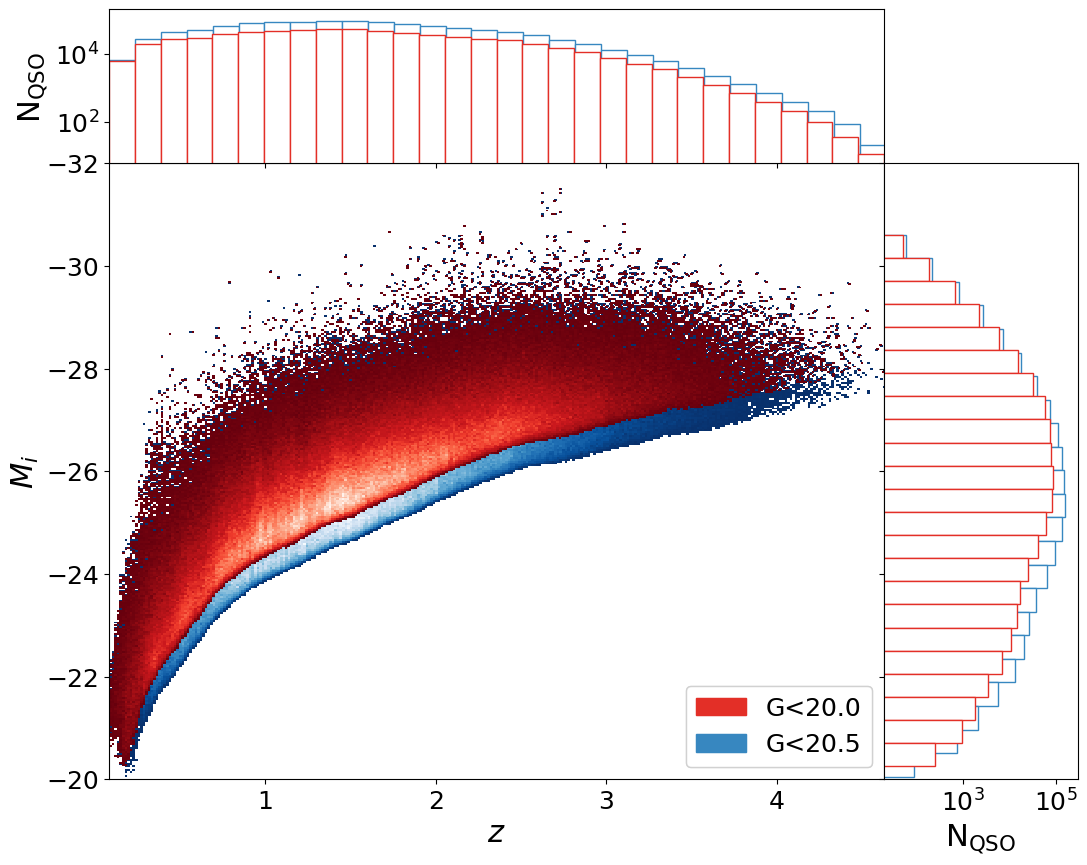

In [13]:
# plot!
fig = plt.figure(figsize = (12.5, 10))
gs = gridspec.GridSpec(2, 2, hspace = 0, height_ratios=[1,4], width_ratios=[4,1], wspace = 0)

ax1 = fig.add_subplot(gs[2])

quaia.absolute(tab_datahi, G_hi)
quaia.absolute(tab_datalo, G_lo)
h1, xedges, yedges, image = ax1.hist2d(tab_datahi['redshift_quaia'][mask_datahi], tab_datahi['M_i'][mask_datahi], cmap = cmap_blues, bins = 300, 
                                       cmin = 1)
h1, xedges, yedges, image = ax1.hist2d(tab_datalo['redshift_quaia'][mask_datalo], tab_datalo['M_i'][mask_datalo], cmap = cmap_reds, bins = 300, 
                                       cmin = 1)
ax1.set_ylabel('$M_i$')
ax1.set_xlabel('$z$')
ax1.set_ylim(-20, -32)
xlim = ax1.get_xlim()
ylim = ax1.get_ylim()
patch = [mpatches.Patch(color=colors[i], label='G<{}'.format(G_array[i])) for i in range(len(colors))] 
first_legend = ax1.legend(handles=patch, loc = 'lower right')
ax1.add_artist(first_legend)

ax2 = fig.add_subplot(gs[0])
ax2.hist(tab_datahi['redshift_quaia'][mask_datahi], color = 'white', edgecolor = blue, bins = 30)
ax2.hist(tab_datalo['redshift_quaia'][mask_datalo], color = 'white', edgecolor = red, bins = 30)
ax2.set_ylabel('N$_\mathrm{QSO}$')
ax2.set_yscale('log')
ax2.set_xlim(xlim)
ax2.set_ylim(6,2e5)
ax2.set_xticklabels([])

ax3 = fig.add_subplot(gs[3])
ax3.hist(tab_datahi['M_i'][mask_datahi], color = 'white', edgecolor = blue, orientation = 'horizontal', bins = 25)
ax3.hist(tab_datalo['M_i'][mask_datalo], color = 'white', edgecolor = red, orientation = 'horizontal', bins = 25)
ax3.set_xlabel('N$_\mathrm{QSO}$')
ax3.set_xscale('log')
ax3.set_yticklabels([])
ax3.set_ylim(ylim)
ax3.set_xlim(2e1,3e5)

plt.show()

# Understand fraction of sources excluded
## Across the entire catalogue

Fraction of sources excluded       .    Sources remaining
---------------------------------------------------------
G20.0               : 0.17              624375
G20.0_zmin0.0zmax1.0: 0.20              160813
G20.0_zmin1.0zmax2.0: 0.17              305604
G20.0_zmin2.0zmax3.0: 0.15              139919
G20.0_zmin3.0zmax4.0: 0.12              17636

G20.5               : 0.15              1102599
G20.5_zmin0.0zmax1.0: 0.18              267295
G20.5_zmin1.0zmax2.0: 0.15              550937
G20.5_zmin2.0zmax3.0: 0.12              251286
G20.5_zmin3.0zmax4.0: 0.09              32269


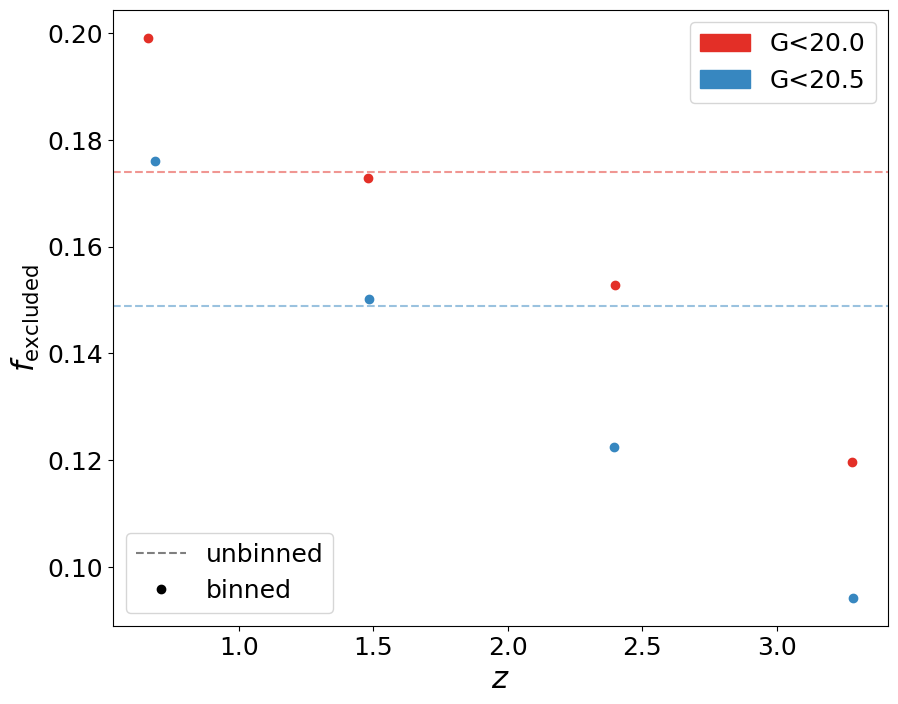

In [14]:
fig = plt.figure(figsize=(10,8))
frac_z={G_lo: [], G_hi: []}
mean_z={G_lo: [], G_hi: []}
print('Fraction of sources excluded       .    Sources remaining')
print('---------------------------------------------------------')
for G, N_data_mask, tab_data, mask_data, color in zip(G_array,  [N_datalo_mask, N_datahi_mask], [tab_datalo, tab_datahi], [mask_datalo, mask_datahi], 
                                                     colors):
    
    print('G{:.1f}               : {:.2f}              {}'.format(G, 1-N_data_mask/len(tab_data), N_data_mask))
    plt.axhline(1-N_data_mask/len(tab_data), color = color, linestyle = '--', alpha = 0.5, label = 'no binning')
    
    for zbin in zbin_array[:-1]:
    
        tab_data_bin_mask = tab_data[mask_data]['redshift_quaia'][(zbin_array[int(zbin)]<tab_data[mask_data]['redshift_quaia']) & 
                                                            (tab_data['redshift_quaia'][mask_data]<=zbin_array[int(zbin+1)])]
        num = len(tab_data_bin_mask)
        den = len(tab_data['redshift_quaia'][(zbin_array[int(zbin)]<tab_data['redshift_quaia']) & 
                                               (tab_data['redshift_quaia']<=zbin_array[int(zbin+1)])])
        print('G{:.1f}_zmin{:.1f}zmax{:.1f}: {:.2f}              {}'.format(G, zbin, zbin+1, 1-num/den, num))
        
        plt.scatter(np.mean(tab_data_bin_mask), 1-num/den, color = color)
        frac_z[G].append(1-num/den)
        mean_z[G].append(np.mean(tab_data_bin_mask))
    
    if G==G_lo:
        print()

patch = [mpatches.Patch(color=colors[i], label='G<{}'.format(G_array[i])) for i in range(len(colors))] 
first_legend = plt.legend(handles=patch)
fig.add_artist(first_legend)

custom_lines = [Line2D([0], [0], color = 'black', alpha = 0.5, linestyle = '--'), 
                Line2D([0], [0], color = 'black', marker ='o', linewidth = 0)]
plt.legend(custom_lines, ['unbinned', 'binned'], loc = 'lower left')

plt.xlabel('$z$')
plt.ylabel('$f_\mathrm{excluded}$')
# plt.legend()
plt.show()

Fraction of sources excluded       .  Sources remaining
-------------------------------------------------------
G20.0             : 0.17              624375
G20.0_Lsplit3Lbin0: 0.22              195879
G20.0_Lsplit3Lbin1: 0.17              209740
G20.0_Lsplit3Lbin2: 0.13              218756

G20.5             : 0.15              1102599
G20.5_Lsplit3Lbin0: 0.19              348366
G20.5_Lsplit3Lbin1: 0.14              369688
G20.5_Lsplit3Lbin2: 0.11              384545


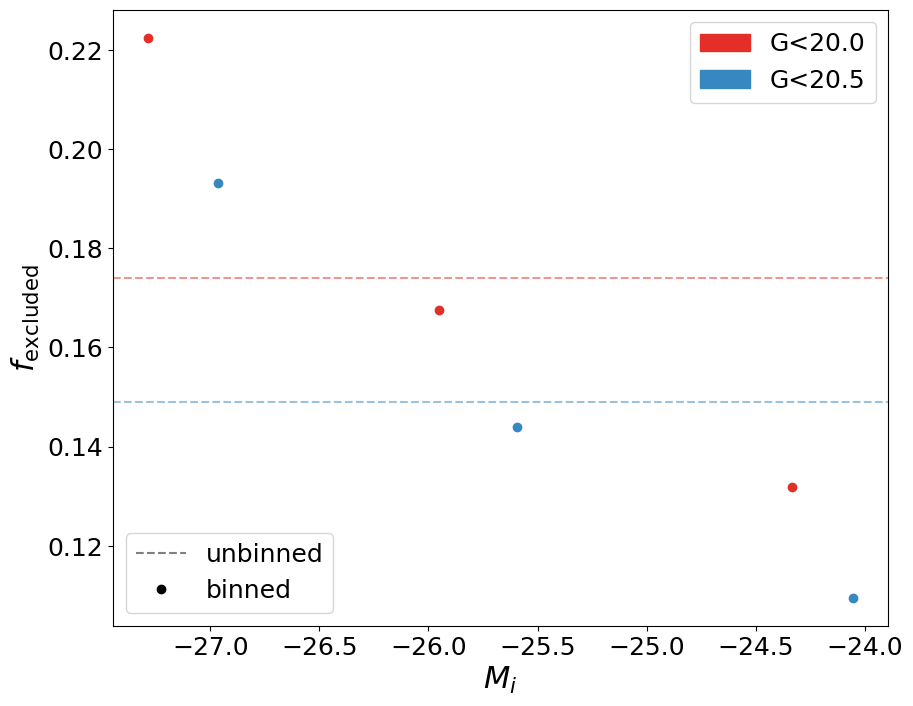

In [15]:
fig = plt.figure(figsize=(10,8))
key = 'M_i'
n_bins = 3
frac_L={G_lo: [], G_hi: []}
mean_L = {G_lo: [], G_hi: []}
print('Fraction of sources excluded       .  Sources remaining')
print('-------------------------------------------------------')
for G, N_data_mask, tab_data, mask_data, color in zip(G_array,  [N_datalo_mask, N_datahi_mask], [tab_datalo, tab_datahi], [mask_datalo, mask_datahi], 
                                                      colors):
    
    print('G{:.1f}             : {:.2f}              {}'.format(G, 1-N_data_mask/len(tab_data), N_data_mask))
    plt.axhline(1-N_data_mask/len(tab_data), color = color, linestyle = '--', alpha = 0.5, label = 'no binning')
    
    for zbin in zbin_array[:-2]:
        
        bb = int(zbin)
        z_percentiles = np.linspace(0.0, 100.0, n_bins+1)
        # print(z_percentiles)
        bins = np.percentile(list(tab_data[key]), z_percentiles)
        bins[-1] += 0.01 # add a bit to maximum bin to make sure the highest-z source gets included
        bins[0] -= 0.01 # add a bit to minimum bin to make sure the lowest-z source gets included

#         print("bins:", bins)
#         print("n_bins:", n_bins)

        i_bin = (tab_data[key] >= bins[bb]) & (tab_data[key] < bins[bb+1])
        tab_datahi_bin0 = tab_data[i_bin]
    
        num = len(tab_data[mask_data][i_bin[mask_data]])
        den = len(tab_data[i_bin])
        print('G{:.1f}_Lsplit{}Lbin{:.0f}: {:.2f}              {}'.format(G, n_bins, zbin, 1-num/den, num))
        plt.scatter(np.mean(tab_datahi_bin0[key]), 1-num/den, color = color)
        frac_L[G].append(1-num/den)
        mean_L[G].append(np.mean(tab_datahi_bin0[key]))
    
    if G==G_lo:
        print()
        
patch = [mpatches.Patch(color=colors[i], label='G<{}'.format(G_array[i])) for i in range(len(colors))] 
first_legend = plt.legend(handles=patch)
fig.add_artist(first_legend)

custom_lines = [Line2D([0], [0], color = 'black', alpha = 0.5, linestyle = '--'), 
                Line2D([0], [0], color = 'black', marker ='o', linewidth = 0)]
plt.legend(custom_lines, ['unbinned', 'binned'], loc = 'lower left')

plt.xlabel('$M_i$')
plt.ylabel('$f_\mathrm{excluded}$')
plt.show()

## Across four z bins

Fraction of sources excluded       .    Sources remaining
---------------------------------------------------------
G20.0               : 0.17              624375
G20.0_zmin0.0zmax1.0: 0.29              142897 vs 200785
G20.0_zmin1.0zmax2.0: 0.23              285720 vs 369335
G20.0_zmin2.0zmax3.0: 0.44              92402 vs 165277
G20.0_zmin3.0zmax4.0: 0.07              18618 vs 20035

G20.5               : 0.15              1102599
G20.5_zmin0.0zmax1.0: 0.22              253398 vs 324336
G20.5_zmin1.0zmax2.0: 0.17              536368 vs 648196
G20.5_zmin2.0zmax3.0: 0.37              179640 vs 286508
G20.5_zmin3.0zmax4.0: 0.46              19252 vs 35630


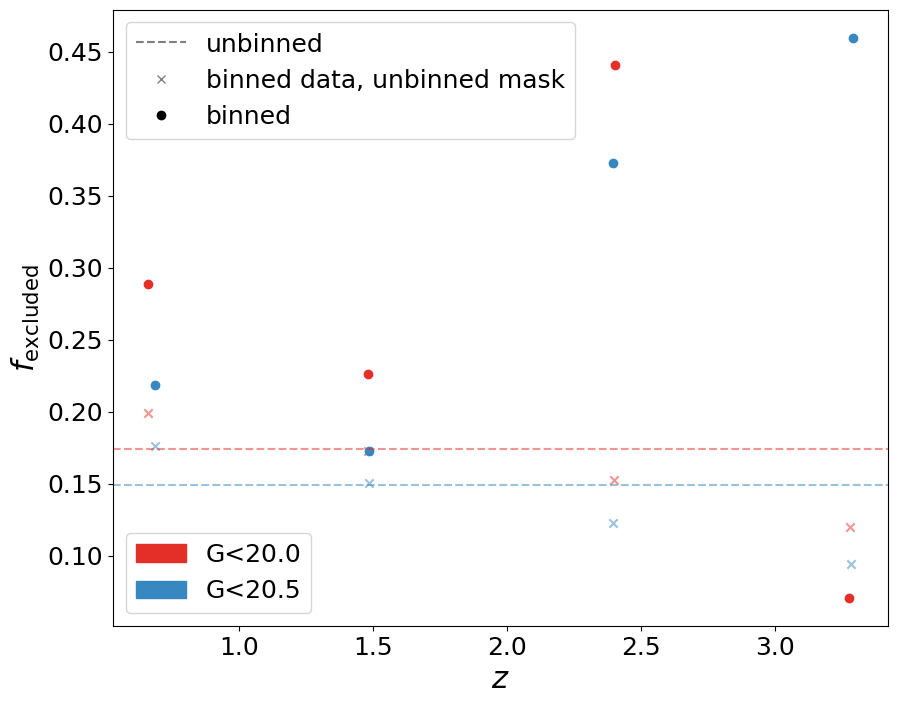

In [18]:
fig = plt.figure(figsize=(10,8))
print('Fraction of sources excluded       .    Sources remaining')
print('---------------------------------------------------------')
fac_rand = 25
for G, N_data_mask, tab_data, color in zip(G_array, [N_datalo_mask, N_datahi_mask], [tab_datalo, tab_datahi], colors):
    
    print('G{:.1f}               : {:.2f}              {}'.format(G, 1-N_data_mask/len(tab_data), N_data_mask))
    plt.axhline(1-N_data_mask/len(tab_data), color = color, linestyle = '--', alpha = 0.5, label = 'no binning')
    
    for zbin in zbin_array[:-1]:

        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, frac, _ = quaia.make_bins(G, int(zbin),True, 'z', bins = zbin_array, 
                                                                                           tab_gcat_type = 'data', method = 'minmax', 
                                                                                        fac_rand = fac_rand)
        plt.scatter(np.mean(tab_datahi_mask_zbin0['redshift_quaia']), frac, color = color)
        
    if G==G_lo:
        print()
        
    plt.scatter(mean_z[G], frac_z[G], color = color, alpha = 0.5, marker = 'x')

patch = [mpatches.Patch(color=colors[i], label='G<{}'.format(G_array[i])) for i in range(len(colors))] 
first_legend = plt.legend(handles=patch, loc = 'lower left')
fig.add_artist(first_legend)

custom_lines = [Line2D([0], [0], color = 'black', alpha = 0.5, linestyle = '--'), 
                Line2D([0], [0], color = 'black', marker ='x', linewidth = 0, alpha = 0.5),
                Line2D([0], [0], color = 'black', marker ='o', linewidth = 0)]
plt.legend(custom_lines, ['unbinned', 'binned data, unbinned mask', 'binned'], loc = 'upper left')

plt.xlabel('$z$')
plt.ylabel('$f_\mathrm{excluded}$')
plt.show()

## Across three Lbins

Fraction of sources excluded       . Sources remaining
------------------------------------------------------
G20.0            : 0.17              624375
G20.0_Lsplit3bin0: 0.16              210964 vs 251950
G20.0_Lsplit3bin1: 0.25              188449 vs 251950
G20.0_Lsplit3bin2: 0.41              149723 vs 251950

G20.5            : 0.15              1102599
G20.5_Lsplit3bin0: 0.11              382895 vs 431834
G20.5_Lsplit3bin1: 0.20              343394 vs 431834
G20.5_Lsplit3bin2: 0.30              303012 vs 431834


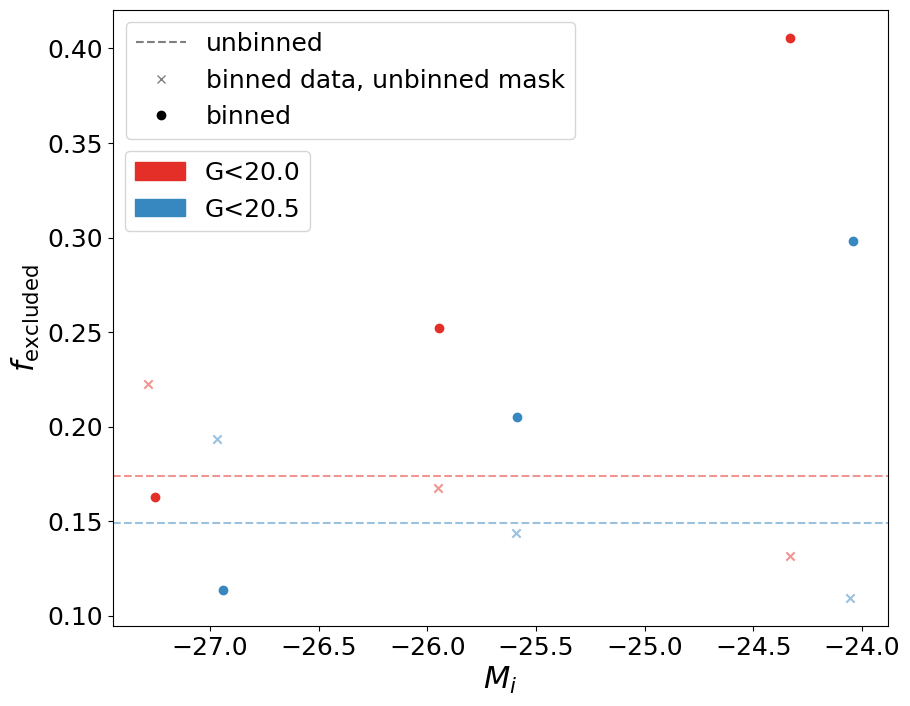

In [ ]:
fig = plt.figure(figsize=(10,8))
print('Fraction of sources excluded       . Sources remaining')
print('------------------------------------------------------')
for G, N_data_mask, tab_data, color in zip(G_array, [N_datalo_mask, N_datahi_mask], [tab_datalo, tab_datahi], colors):
    
    print('G{:.1f}            : {:.2f}              {}'.format(G, 1-N_data_mask/len(tab_data), N_data_mask))
    plt.axhline(1-N_data_mask/len(tab_data), color = color, linestyle = '--', alpha = 0.5, label = 'no binning')
    
    for zbin in zbin_array[:-2]:
 
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, frac, _ = quaia.make_bins(G, int(zbin),True, 'L', n_bins = 3, 
                                                                                           tab_gcat_type = 'data', method = 'split', 
                                                                                        fac_rand = fac_rand)
        plt.scatter(np.mean(tab_datahi_mask_zbin0['M_i']), frac, color = color)
    
    if G==G_lo:
        print()
        
    plt.scatter(mean_L[G], frac_L[G], color = color, alpha = 0.5, marker = 'x')

patch = [mpatches.Patch(color=colors[i], label='G<{}'.format(G_array[i])) for i in range(len(colors))] 
first_legend = plt.legend(handles=patch, loc = (0.015, 0.64))
fig.add_artist(first_legend)

custom_lines = [Line2D([0], [0], color = 'black', alpha = 0.5, linestyle = '--'), 
                Line2D([0], [0], color = 'black', marker ='x', linewidth = 0, alpha = 0.5),
                Line2D([0], [0], color = 'black', marker ='o', linewidth = 0)]
plt.legend(custom_lines, ['unbinned', 'binned data, unbinned mask', 'binned'], loc = 'upper left')

plt.xlabel('$M_i$')
plt.ylabel('$f_\mathrm{excluded}$')
plt.show()

## Across four Lbins

Fraction of sources excluded       .        Sources remaining
-------------------------------------------------------------
G20.0                   : 0.17              624375
G20.0_Lmin-32.0Lmax-28.0: 0.00              30750 vs 30757
G20.0_Lmin-32.0Lmax-28.0: 0.35              20139 (unbinned mask)

G20.0_Lmin-28.0Lmax-26.0: 0.16              282491 vs 335369
G20.0_Lmin-28.0Lmax-26.0: 0.20              269113 (unbinned mask)

G20.0_Lmin-26.0Lmax-24.0: 0.32              215344 vs 317040
G20.0_Lmin-26.0Lmax-24.0: 0.14              272393 (unbinned mask)

G20.0_Lmin-24.0Lmax-20.0: 0.68              23203 vs 72658
G20.0_Lmin-24.0Lmax-20.0: 0.14              62730 (unbinned mask)


G20.5                   : 0.15              1102599
G20.5_Lmin-32.0Lmax-28.0: 0.00              32181 vs 32189
G20.5_Lmin-32.0Lmax-28.0: 0.33              21682 (unbinned mask)

G20.5_Lmin-28.0Lmax-26.0: 0.13              397510 vs 458263
G20.5_Lmin-28.0Lmax-26.0: 0.18              376096 (unbinned mask)

G20.5_L

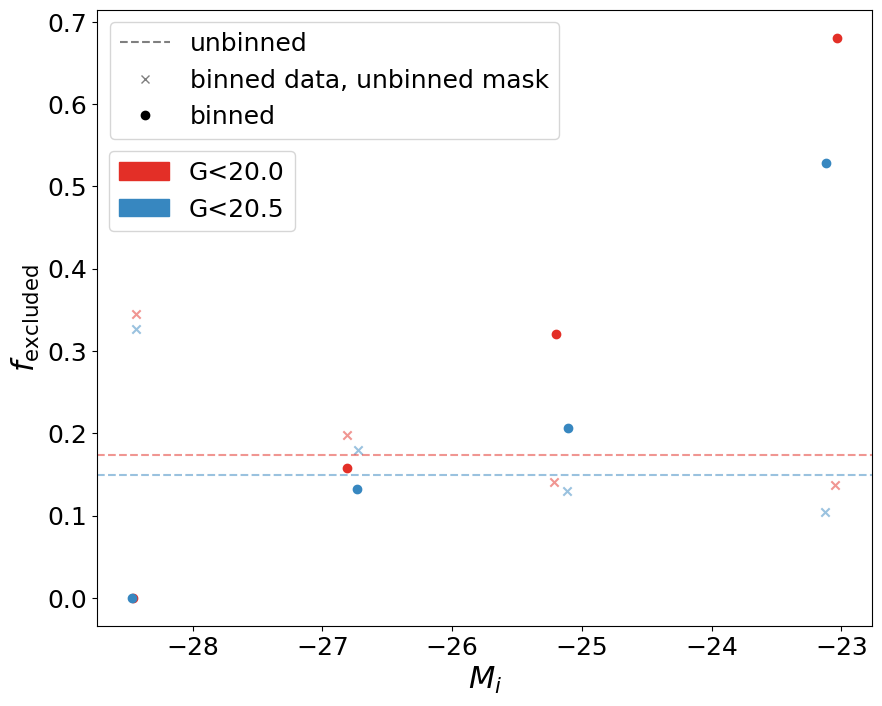

In [ ]:
L_array = [-32.0, -28.0, -26.0, -24.0, -20.0]
fig = plt.figure(figsize=(10,8))
print('Fraction of sources excluded       .        Sources remaining')
print('-------------------------------------------------------------')
for G, N_data_mask, tab_data, color, mask_data in zip(G_array, [N_datalo_mask, N_datahi_mask], [tab_datalo, tab_datahi], colors, 
                                                      [mask_datalo, mask_datahi]):
    
    print('G{:.1f}                   : {:.2f}              {}'.format(G, 1-N_data_mask/len(tab_data), N_data_mask))
    plt.axhline(1-N_data_mask/len(tab_data), color = color, linestyle = '--', alpha = 0.5, label = 'no binning')
    
    for zbin in zbin_array[:-1]:
 
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, frac, _ = quaia.make_bins(G, int(zbin), True, 'L', bins = L_array, 
                                                                                              tab_gcat_type = 'data', method = 'minmax', 
                                                                                              fac_rand = fac_rand)
    
        plt.scatter(np.mean(tab_datahi_mask_zbin0['M_i']), frac, color = color)

        tab_data_bin_mask = tab_data[mask_data]['M_i'][(L_array[int(zbin)]<tab_data[mask_data]['M_i']) & 
                                                            (tab_data['M_i'][mask_data]<=L_array[int(zbin+1)])]
        num = len(tab_data_bin_mask)
        den = len(tab_data['M_i'][(L_array[int(zbin)]<tab_data['M_i']) & 
                                               (tab_data['M_i']<=L_array[int(zbin+1)])])
        print('G{:.1f}_Lmin{:.1f}Lmax{:.1f}: {:.2f}              {} (unbinned mask)\n'.format(G, L_array[int(zbin)], L_array[int(zbin+1)], 1-num/den, num))
        
        plt.scatter(np.mean(tab_data_bin_mask), 1-num/den, color = color, marker = 'x', alpha = 0.5)
    
    if G==G_lo:
        print()

patch = [mpatches.Patch(color=colors[i], label='G<{}'.format(G_array[i])) for i in range(len(colors))] 
first_legend = plt.legend(handles=patch, loc = (0.015, 0.64))
fig.add_artist(first_legend)

custom_lines = [Line2D([0], [0], color = 'black', alpha = 0.5, linestyle = '--'), 
                Line2D([0], [0], color = 'black', marker ='x', linewidth = 0, alpha = 0.5),
                Line2D([0], [0], color = 'black', marker ='o', linewidth = 0)]
plt.legend(custom_lines, ['unbinned', 'binned data, unbinned mask', 'binned'], loc = 'upper left')

plt.xlabel('$M_i$')
plt.ylabel('$f_\mathrm{excluded}$')
plt.show()

Fraction of sources excluded       .        Sources remaining
-------------------------------------------------------------
G20.0                   : 0.17              624375
G20.0_Lmin-32.0Lmax-27.0: 0.11              136805 vs 153834
G20.0_Lmin-32.0Lmax-27.0: 0.25              115335 (unbinned mask)

G20.0_Lmin-27.0Lmax-26.0: 0.28              153783 vs 212292
G20.0_Lmin-27.0Lmax-26.0: 0.18              173917 (unbinned mask)

G20.0_Lmin-26.0Lmax-25.0: 0.34              140460 vs 212564
G20.0_Lmin-26.0Lmax-25.0: 0.15              181300 (unbinned mask)

G20.0_Lmin-25.0Lmax-20.0: 0.47              93707 vs 177134
G20.0_Lmin-25.0Lmax-20.0: 0.13              153823 (unbinned mask)


G20.5                   : 0.15              1102599
G20.5_Lmin-32.0Lmax-27.0: 0.08              156465 vs 170931
G20.5_Lmin-32.0Lmax-27.0: 0.24              129845 (unbinned mask)

G20.5_Lmin-27.0Lmax-26.0: 0.22              250505 vs 319521
G20.5_Lmin-27.0Lmax-26.0: 0.16              267933 (unbinned mask)


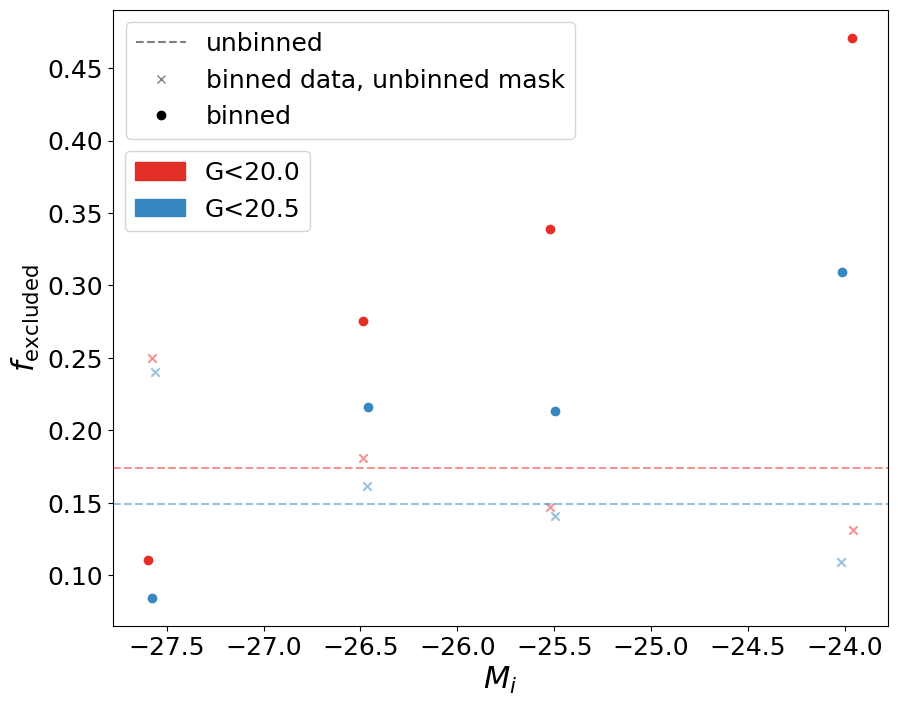

In [21]:
L_array = [-32.0, -27.0, -26.0, -25.0, -20.0]
fig = plt.figure(figsize=(10,8))
print('Fraction of sources excluded       .        Sources remaining')
print('-------------------------------------------------------------')
for G, N_data_mask, tab_data, color, mask_data in zip(G_array, [N_datalo_mask, N_datahi_mask], [tab_datalo, tab_datahi], colors, 
                                                      [mask_datalo, mask_datahi]):
    
    print('G{:.1f}                   : {:.2f}              {}'.format(G, 1-N_data_mask/len(tab_data), N_data_mask))
    plt.axhline(1-N_data_mask/len(tab_data), color = color, linestyle = '--', alpha = 0.5, label = 'no binning')
    
    for zbin in zbin_array[:-1]:
 
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, frac, _ = quaia.make_bins(G, int(zbin), True, 'L', bins = L_array, 
                                                                                              tab_gcat_type = 'data', method = 'minmax', 
                                                                                              fac_rand = fac_rand)
    
        plt.scatter(np.mean(tab_datahi_mask_zbin0['M_i']), frac, color = color)

        tab_data_bin_mask = tab_data[mask_data]['M_i'][(L_array[int(zbin)]<tab_data[mask_data]['M_i']) & 
                                                            (tab_data['M_i'][mask_data]<=L_array[int(zbin+1)])]
        num = len(tab_data_bin_mask)
        den = len(tab_data['M_i'][(L_array[int(zbin)]<tab_data['M_i']) & 
                                               (tab_data['M_i']<=L_array[int(zbin+1)])])
        print('G{:.1f}_Lmin{:.1f}Lmax{:.1f}: {:.2f}              {} (unbinned mask)\n'.format(G, L_array[int(zbin)], L_array[int(zbin+1)], 1-num/den, 
                                                                                              num))
        
        plt.scatter(np.mean(tab_data_bin_mask), 1-num/den, color = color, marker = 'x', alpha = 0.5)
    
    if G==G_lo:
        print()

patch = [mpatches.Patch(color=colors[i], label='G<{}'.format(G_array[i])) for i in range(len(colors))] 
first_legend = plt.legend(handles=patch, loc = (0.015, 0.64))
fig.add_artist(first_legend)

custom_lines = [Line2D([0], [0], color = 'black', alpha = 0.5, linestyle = '--'), 
                Line2D([0], [0], color = 'black', marker ='x', linewidth = 0, alpha = 0.5),
                Line2D([0], [0], color = 'black', marker ='o', linewidth = 0)]
plt.legend(custom_lines, ['unbinned', 'binned data, unbinned mask', 'binned'], loc = 'upper left')

plt.xlabel('$M_i$')
plt.ylabel('$f_\mathrm{excluded}$')
plt.show()

## View the number of sources excluded from each pixel

Number of data sources: 35630
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
0.015151353007774815 0.6512711730338918


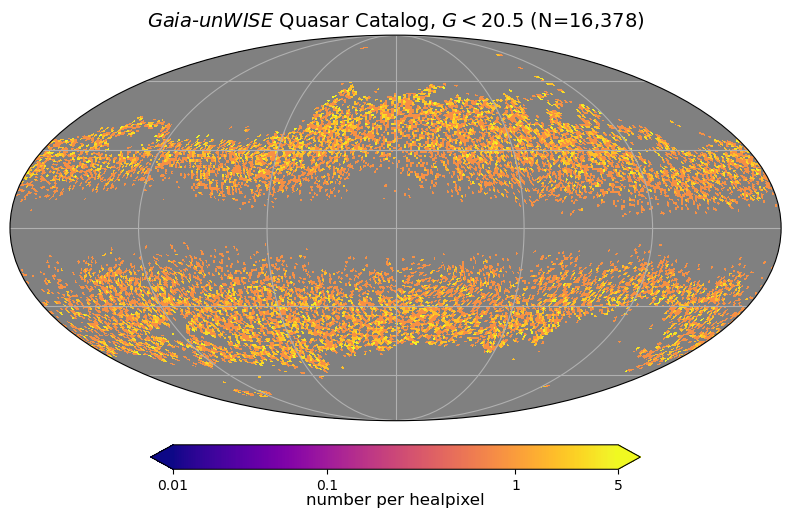

In [22]:
tab_datalo_bin, _, _, mask_datalo_bin = quaia.read(f'../data/quaia_G{{}}_zmin3.0zmax4.0.fits'.format(G_hi), G_hi, 
                                                   f'../data/maps/selection_function_NSIDE64_G{{}}_zmin3.0zmax4.0.fits'.format(G_hi),
                                                   mask_type = 'selfunc', inverse = True, plot = True, fac_stdev = 0.45, 
                                                   cbar_ticks  = [0.01, 0.1, 1,5])

Number of data sources: 20035
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
0.010384436502943965 0.047273441101222696


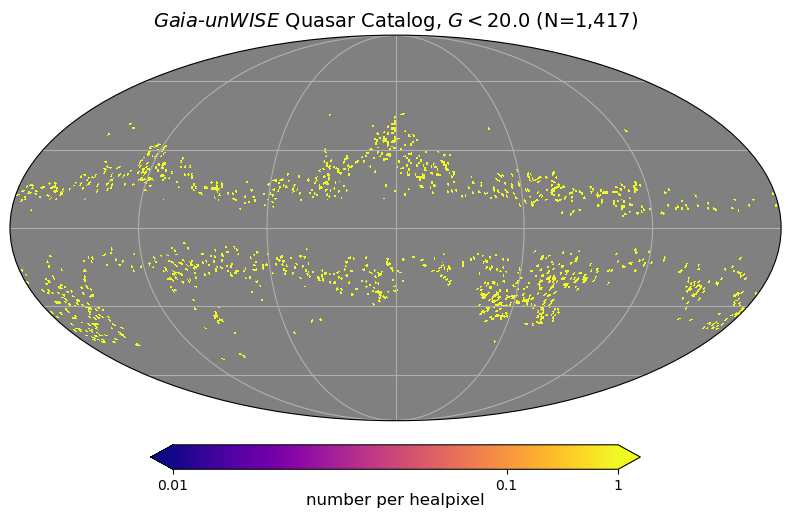

In [23]:
tab_datalo_bin, _, _, mask_datalo_bin = quaia.read(f'../data/quaia_G{{}}_zmin3.0zmax4.0.fits'.format(G_lo), G_lo, 
                                                   f'../data/maps/selection_function_NSIDE64_G{{}}_zmin3.0zmax4.0.fits'.format(G_lo), 
                                                   mask_type = 'selfunc', inverse = True, plot = True, fac_stdev = 0.1, cbar_ticks  = [0.01, 0.1, 1])

## View selfunc histogram for each pixel

G20.0_zmin0.0zmax1.0: 0.29              142897 vs 200785
G20.0_zmin1.0zmax2.0: 0.23              285720 vs 369335
G20.0_zmin2.0zmax3.0: 0.44              92402 vs 165277
G20.0_zmin3.0zmax4.0: 0.07              18618 vs 20035
G20.5_zmin0.0zmax1.0: 0.22              253398 vs 324336
G20.5_zmin1.0zmax2.0: 0.17              536368 vs 648196
G20.5_zmin2.0zmax3.0: 0.37              179640 vs 286508
G20.5_zmin3.0zmax4.0: 0.46              19252 vs 35630


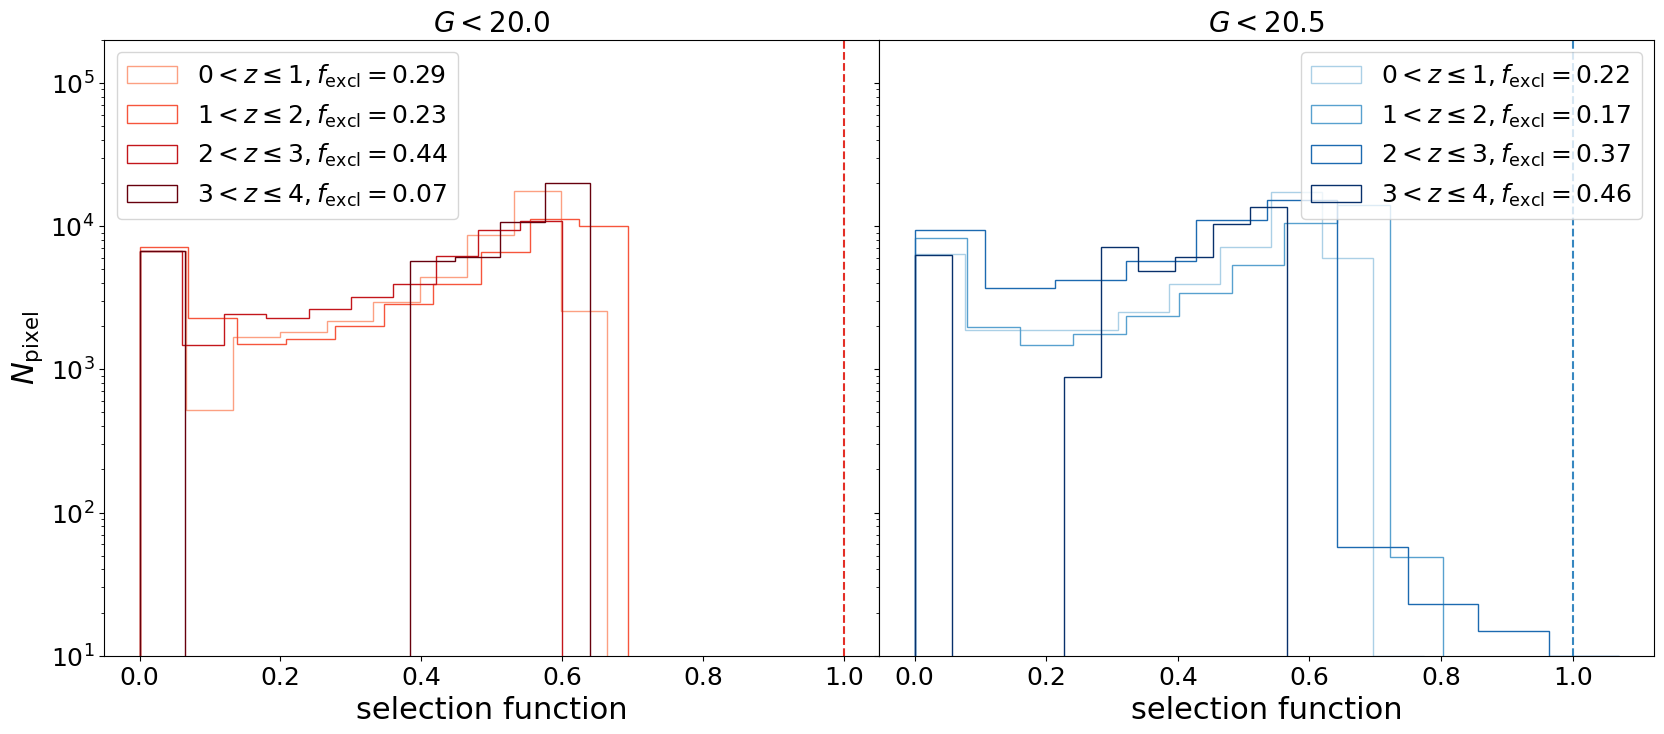

In [24]:
fig = plt.figure(figsize=(20,8))
gs = gridspec.GridSpec(1, 2, wspace = 0)
fac_rand = 25
for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i])
    
    for zbin in zbin_array[:-1]:

        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, weights1, frac, selfunc_hi_bin0 = quaia.make_bins(G_array[i], int(zbin),True, 'z',
                                                                                                     bins = zbin_array, tab_gcat_type = 'data',
                                                                                                     method = 'minmax', fac_rand = fac_rand)
        ax1.hist(selfunc_hi_bin0, log = True, histtype = 'step', color = cmaps[i][int(zbin)], 
                 label = '${:.0f}<z \leq{:.0f}, f_\mathrm{{excl}}={:.2f}$'.format(zbin, zbin+1, frac))
        
    ax1.axvline(1, linestyle = '--', color = colors[i])
    ax1.set_xlabel('selection function')
    ax1.set_title('$G<{}$'.format(G_array[i]))
    if i ==1:
        ax1.set_yticklabels([])
    else:
        ax1.set_ylabel('$N_\mathrm{pixel}$')
    # ax1.set_xlim(0.475, 1.075)
    ax1.set_ylim(1e1,2e5)
    ax1.legend()

plt.show()

## View selfunc histogram for each source

G20.0_zmin0.0zmax1.0: 0.29              142897 vs 200785
G20.0_zmin1.0zmax2.0: 0.23              285720 vs 369335
G20.0_zmin2.0zmax3.0: 0.44              92402 vs 165277
G20.0_zmin3.0zmax4.0: 0.07              18618 vs 20035
G20.5_zmin0.0zmax1.0: 0.22              253398 vs 324336
G20.5_zmin1.0zmax2.0: 0.17              536368 vs 648196
G20.5_zmin2.0zmax3.0: 0.37              179640 vs 286508
G20.5_zmin3.0zmax4.0: 0.46              19252 vs 35630


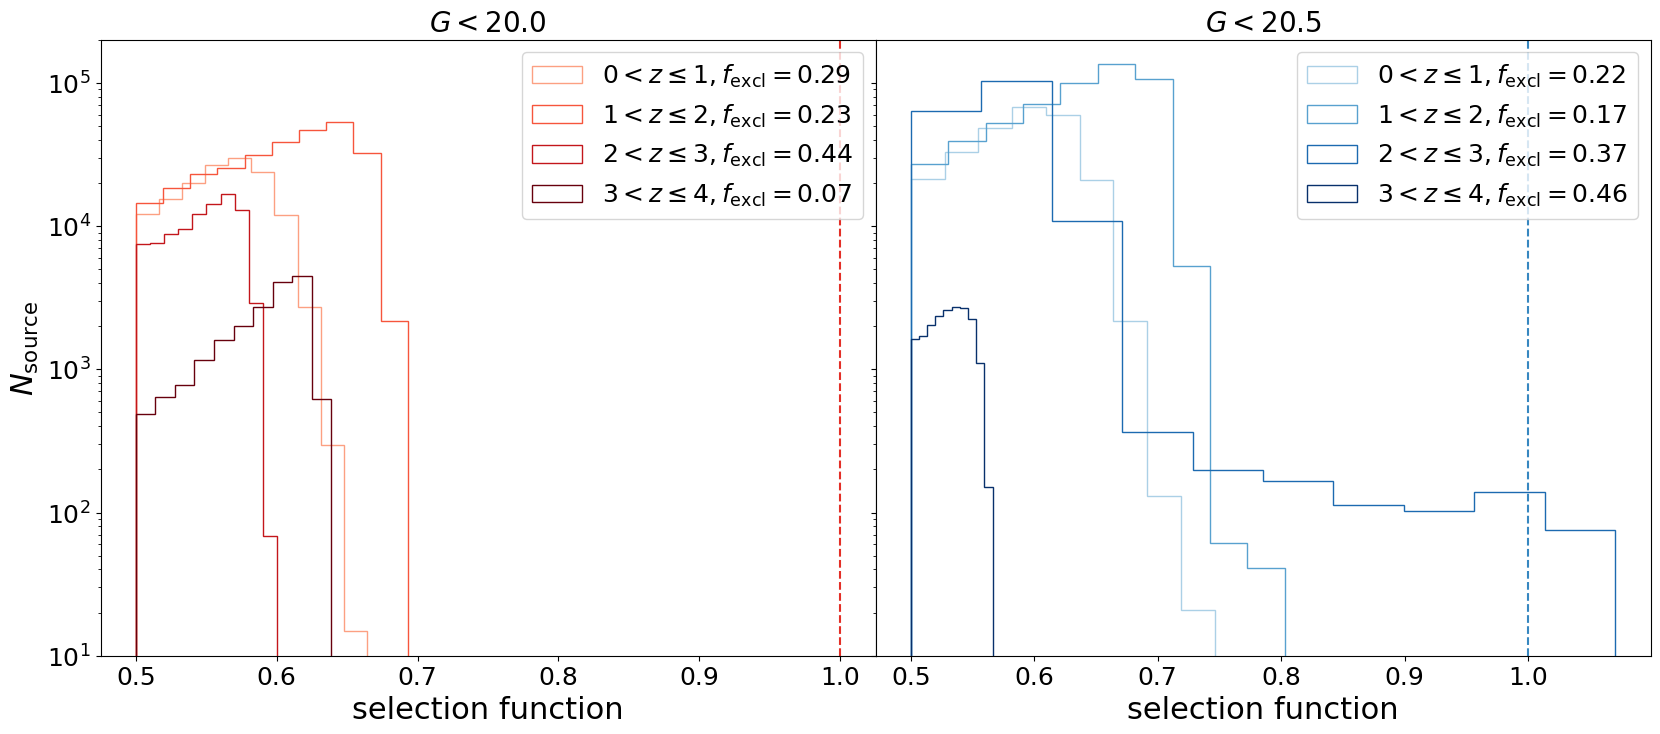

In [25]:
fig = plt.figure(figsize=(20,8))
gs = gridspec.GridSpec(1, 2, wspace = 0)
fac_rand = 25
xlims = [(0.475, 1.025), (0.475, 1.075)]
for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i])
    
    for zbin in zbin_array[:-1]:

        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, weights1, frac, selfunc_hi_bin0 = quaia.make_bins(G_array[i], int(zbin),True, 'z',
                                                                                                     bins = zbin_array, tab_gcat_type = 'data',
                                                                                                     method = 'minmax', fac_rand = fac_rand)

        ax1.hist(1/weights1, log = True, histtype = 'step', color = cmaps[i][int(zbin)], 
                 label = '${:.0f}<z \leq{:.0f}, f_\mathrm{{excl}}={:.2f}$'.format(zbin, zbin+1, frac))
        
    ax1.axvline(1, linestyle = '--', color = colors[i])
    if i%2==1:
        ax1.set_yticklabels([])
    else:
        ax1.set_ylabel('$N_\mathrm{source}$')
    # ax1.set_xlim(xlims[i])
    # ax2.set_xlim(xlims[i])
    ax1.set_ylim(1e1,2e5)
    ax1.set_title('$G<{}$'.format(G_array[i]))
    ax1.legend()
    # ax1.set_xticklabels([])
    ax1.set_xlabel('selection function')

plt.show()

G20.0_Lsplit3bin0: 0.16              210964 vs 251950
G20.0_Lsplit3bin1: 0.25              188449 vs 251950
G20.0_Lsplit3bin2: 0.41              149723 vs 251950
G20.5_Lsplit3bin0: 0.11              382895 vs 431834
G20.5_Lsplit3bin1: 0.20              343394 vs 431834
G20.5_Lsplit3bin2: 0.30              303012 vs 431834


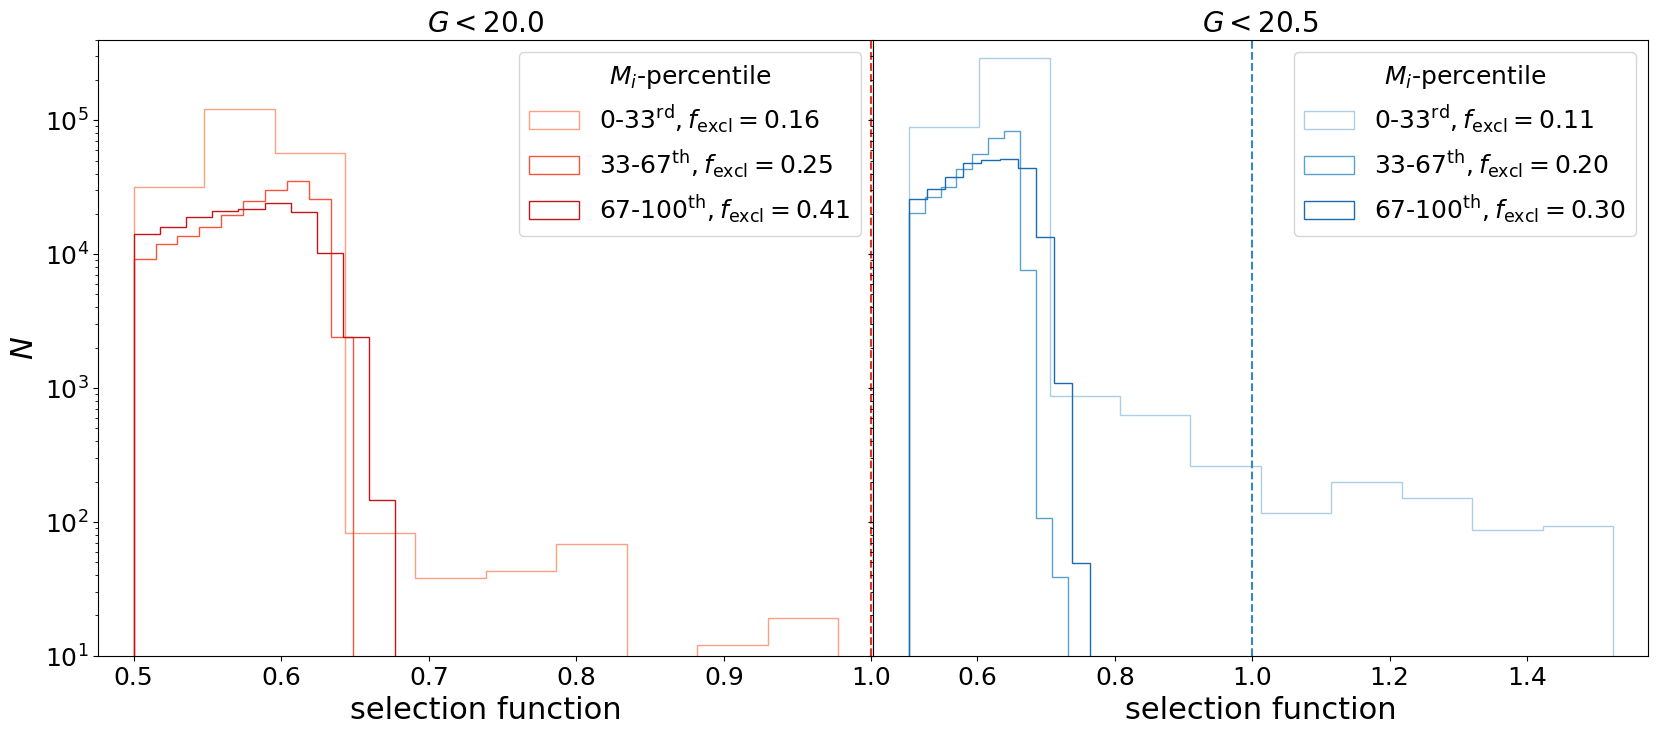

In [27]:
fig = plt.figure(figsize=(20,8))
gs = gridspec.GridSpec(1, 2, wspace = 0)
fac_rand = 25
labels = ['0-33$^\mathrm{rd}$', '33-67$^\mathrm{th}$', '67-100$^\mathrm{th}$']
for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i])
    
    for j in range(len(labels)):

        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, weights1, frac, _ = quaia.make_bins(G_array[i], j, True, 'L', 
                                                                                                     n_bins = len(labels), tab_gcat_type = 'data',
                                                                                                     method = 'split', fac_rand = fac_rand)
        ax1.hist(1/weights1, log = True, histtype = 'step', color = cmaps[i][j], 
                 label = '{}$, f_\mathrm{{excl}}={:.2f}$'.format(labels[j], frac))
        
    ax1.axvline(1, linestyle = '--', color = colors[i])
    ax1.set_xlabel('selection function')
    ax1.set_title('$G<{}$'.format(G_array[i]))
    if i ==1:
        ax1.set_yticklabels([])
    else:
        ax1.set_ylabel('$N$')
    # ax1.set_xlim(0.475, 3)
    ax1.set_ylim(1e1,4e5)
    ax1.legend(title='$M_i$-percentile', title_fontsize = 18)

plt.show()

G20.0_Lmin-32.0Lmax-28.0: 0.00              30750 vs 30757
G20.0_Lmin-28.0Lmax-26.0: 0.16              282491 vs 335369
G20.0_Lmin-26.0Lmax-24.0: 0.32              215344 vs 317040
G20.0_Lmin-24.0Lmax-20.0: 0.68              23203 vs 72658
G20.5_Lmin-32.0Lmax-28.0: 0.00              32181 vs 32189
G20.5_Lmin-28.0Lmax-26.0: 0.13              397510 vs 458263
G20.5_Lmin-26.0Lmax-24.0: 0.21              513742 vs 646971
G20.5_Lmin-24.0Lmax-20.0: 0.53              74562 vs 158039


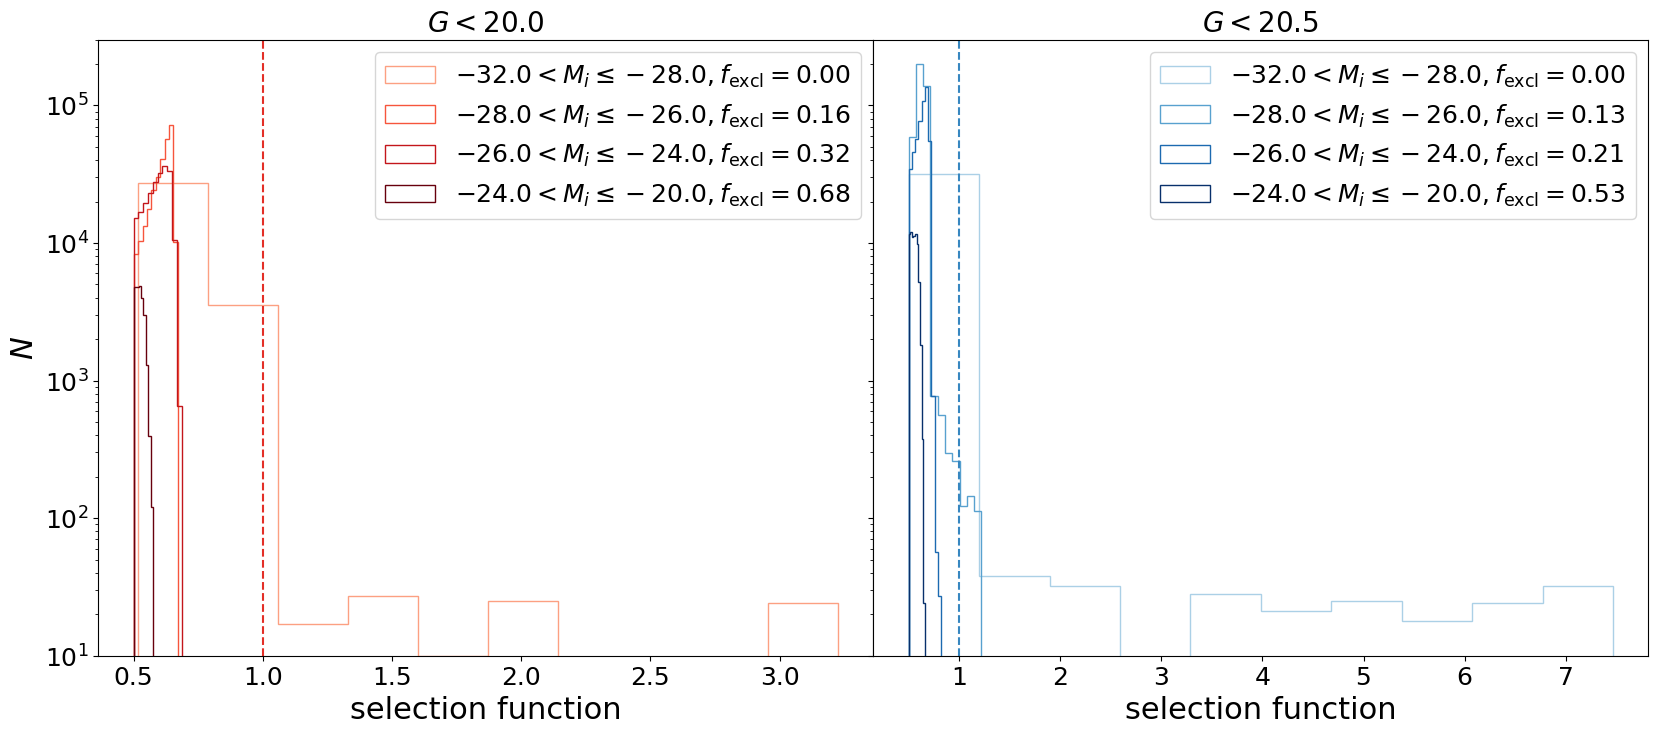

In [28]:
L_array = [-32.0, -28.0, -26.0, -24.0, -20.0]
fig = plt.figure(figsize=(20,8))
gs = gridspec.GridSpec(1, 2, wspace = 0)
fac_rand = 25
for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i])
    
    for j in range(len(L_array)-1):

        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, weights1, frac, _ = quaia.make_bins(G_array[i], j,True, 'L', 
                                                                                                     bins = L_array, tab_gcat_type = 'data',
                                                                                                     method = 'minmax', fac_rand = fac_rand)
        ax1.hist(1/weights1, log = True, histtype = 'step', color = cmaps[i][j], 
                 label = '${:.1f}<M_i \leq{:.1f}, f_\mathrm{{excl}}={:.2f}$'.format(L_array[j], L_array[j+1], frac))
        
    ax1.axvline(1, linestyle = '--', color = colors[i])
    ax1.set_xlabel('selection function')
    ax1.set_title('$G<{}$'.format(G_array[i]))
    if i ==1:
        ax1.set_yticklabels([])
    else:
        ax1.set_ylabel('$N$')
    # ax1.set_xlim(0.475, 3)
    ax1.set_ylim(1e1,3e5)
    ax1.legend()

plt.show()

G20.0_Lmin-32.0Lmax-27.0: 0.11              136805 vs 153834
G20.0_Lmin-27.0Lmax-26.0: 0.28              153783 vs 212292
G20.0_Lmin-26.0Lmax-25.0: 0.34              140460 vs 212564
G20.0_Lmin-25.0Lmax-20.0: 0.47              93707 vs 177134
G20.5_Lmin-32.0Lmax-27.0: 0.08              156465 vs 170931
G20.5_Lmin-27.0Lmax-26.0: 0.22              250505 vs 319521
G20.5_Lmin-26.0Lmax-25.0: 0.21              303263 vs 385567
G20.5_Lmin-25.0Lmax-20.0: 0.31              289746 vs 419443


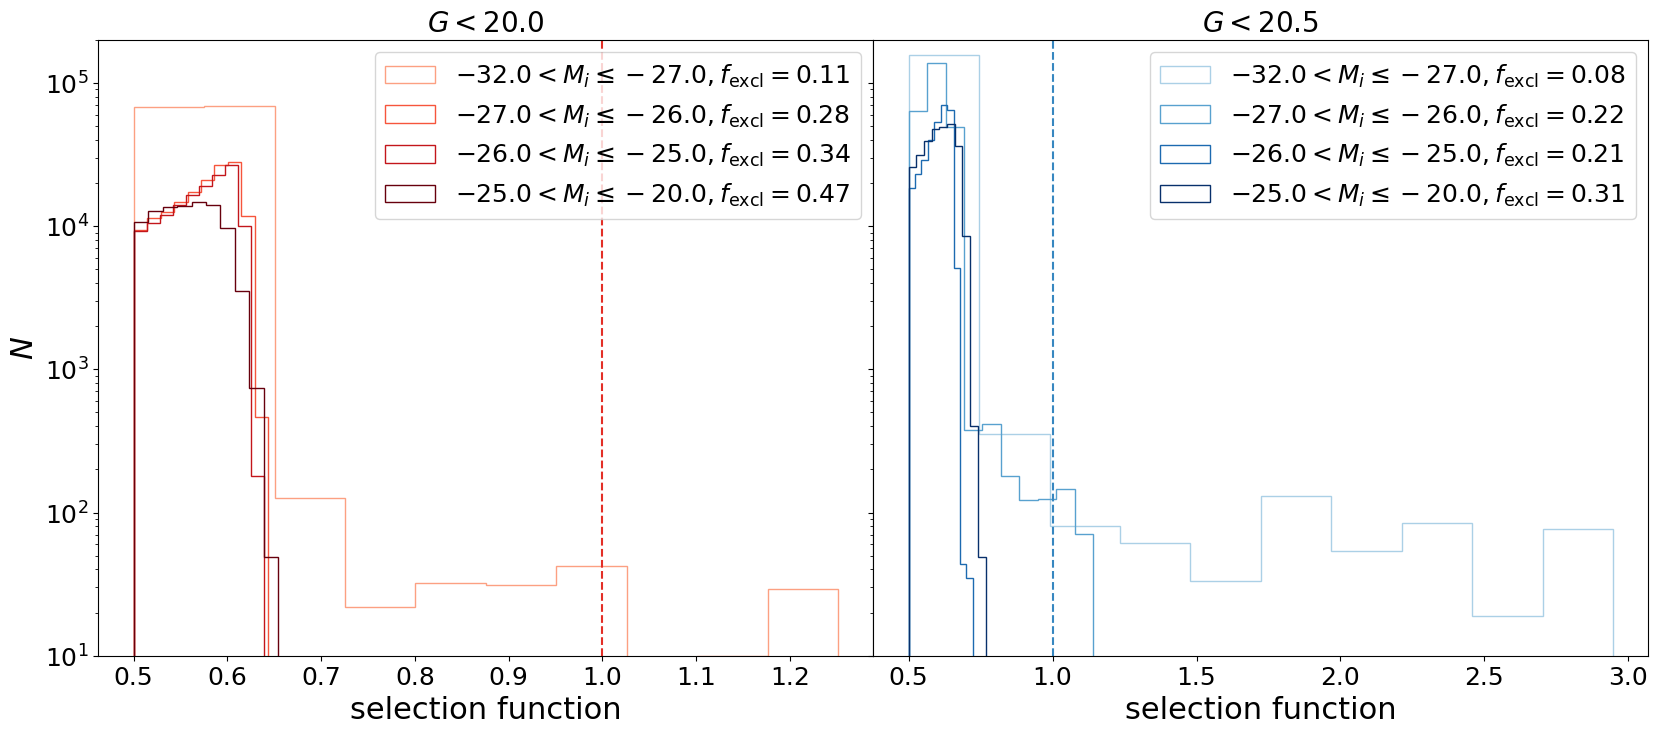

In [29]:
L_array = [-32.0, -27.0, -26.0, -25.0, -20.0]
fig = plt.figure(figsize=(20,8))
gs = gridspec.GridSpec(1, 2, wspace = 0)
fac_rand = 25
for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i])
    
    for j in range(len(L_array)-1):

        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, weights1, frac, _ = quaia.make_bins(G_array[i], j,True, 'L', 
                                                                                                     bins = L_array, tab_gcat_type = 'data',
                                                                                                     method = 'minmax', fac_rand = fac_rand)
        ax1.hist(1/weights1, log = True, histtype = 'step', color = cmaps[i][j], 
                 label = '${:.1f}<M_i \leq{:.1f}, f_\mathrm{{excl}}={:.2f}$'.format(L_array[j], L_array[j+1], frac))
        
    ax1.axvline(1, linestyle = '--', color = colors[i])
    ax1.set_xlabel('selection function')
    ax1.set_title('$G<{}$'.format(G_array[i]))
    if i ==1:
        ax1.set_yticklabels([])
    else:
        ax1.set_ylabel('$N$')
    # ax1.set_xlim(0.475, 3)
    ax1.set_ylim(1e1,2e5)
    ax1.legend()

plt.show()

## View selfunc histogram in each bin

In [17]:
import importlib
importlib.reload(quaia)

<module 'quaia' from '/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts/quaia.py'>

G20.0_zmin0.0zmax1.0: 0.29              142897 vs 200785
G20.0_zmin0.0zmax1.0: 0.00              200785 vs 200785
G20.0_zmin1.0zmax2.0: 0.23              285720 vs 369335
G20.0_zmin1.0zmax2.0: 0.00              369335 vs 369335
G20.0_zmin2.0zmax3.0: 0.44              92402 vs 165277
G20.0_zmin2.0zmax3.0: 0.00              165277 vs 165277
G20.0_zmin3.0zmax4.0: 0.07              18618 vs 20035
G20.0_zmin3.0zmax4.0: 0.00              20035 vs 20035
G20.5_zmin0.0zmax1.0: 0.22              253398 vs 324336
G20.5_zmin0.0zmax1.0: 0.00              324336 vs 324336
G20.5_zmin1.0zmax2.0: 0.17              536368 vs 648196
G20.5_zmin1.0zmax2.0: 0.00              648196 vs 648196
G20.5_zmin2.0zmax3.0: 0.37              179640 vs 286508
G20.5_zmin2.0zmax3.0: 0.00              286508 vs 286508
G20.5_zmin3.0zmax4.0: 0.46              19252 vs 35630
G20.5_zmin3.0zmax4.0: 0.00              35630 vs 35630


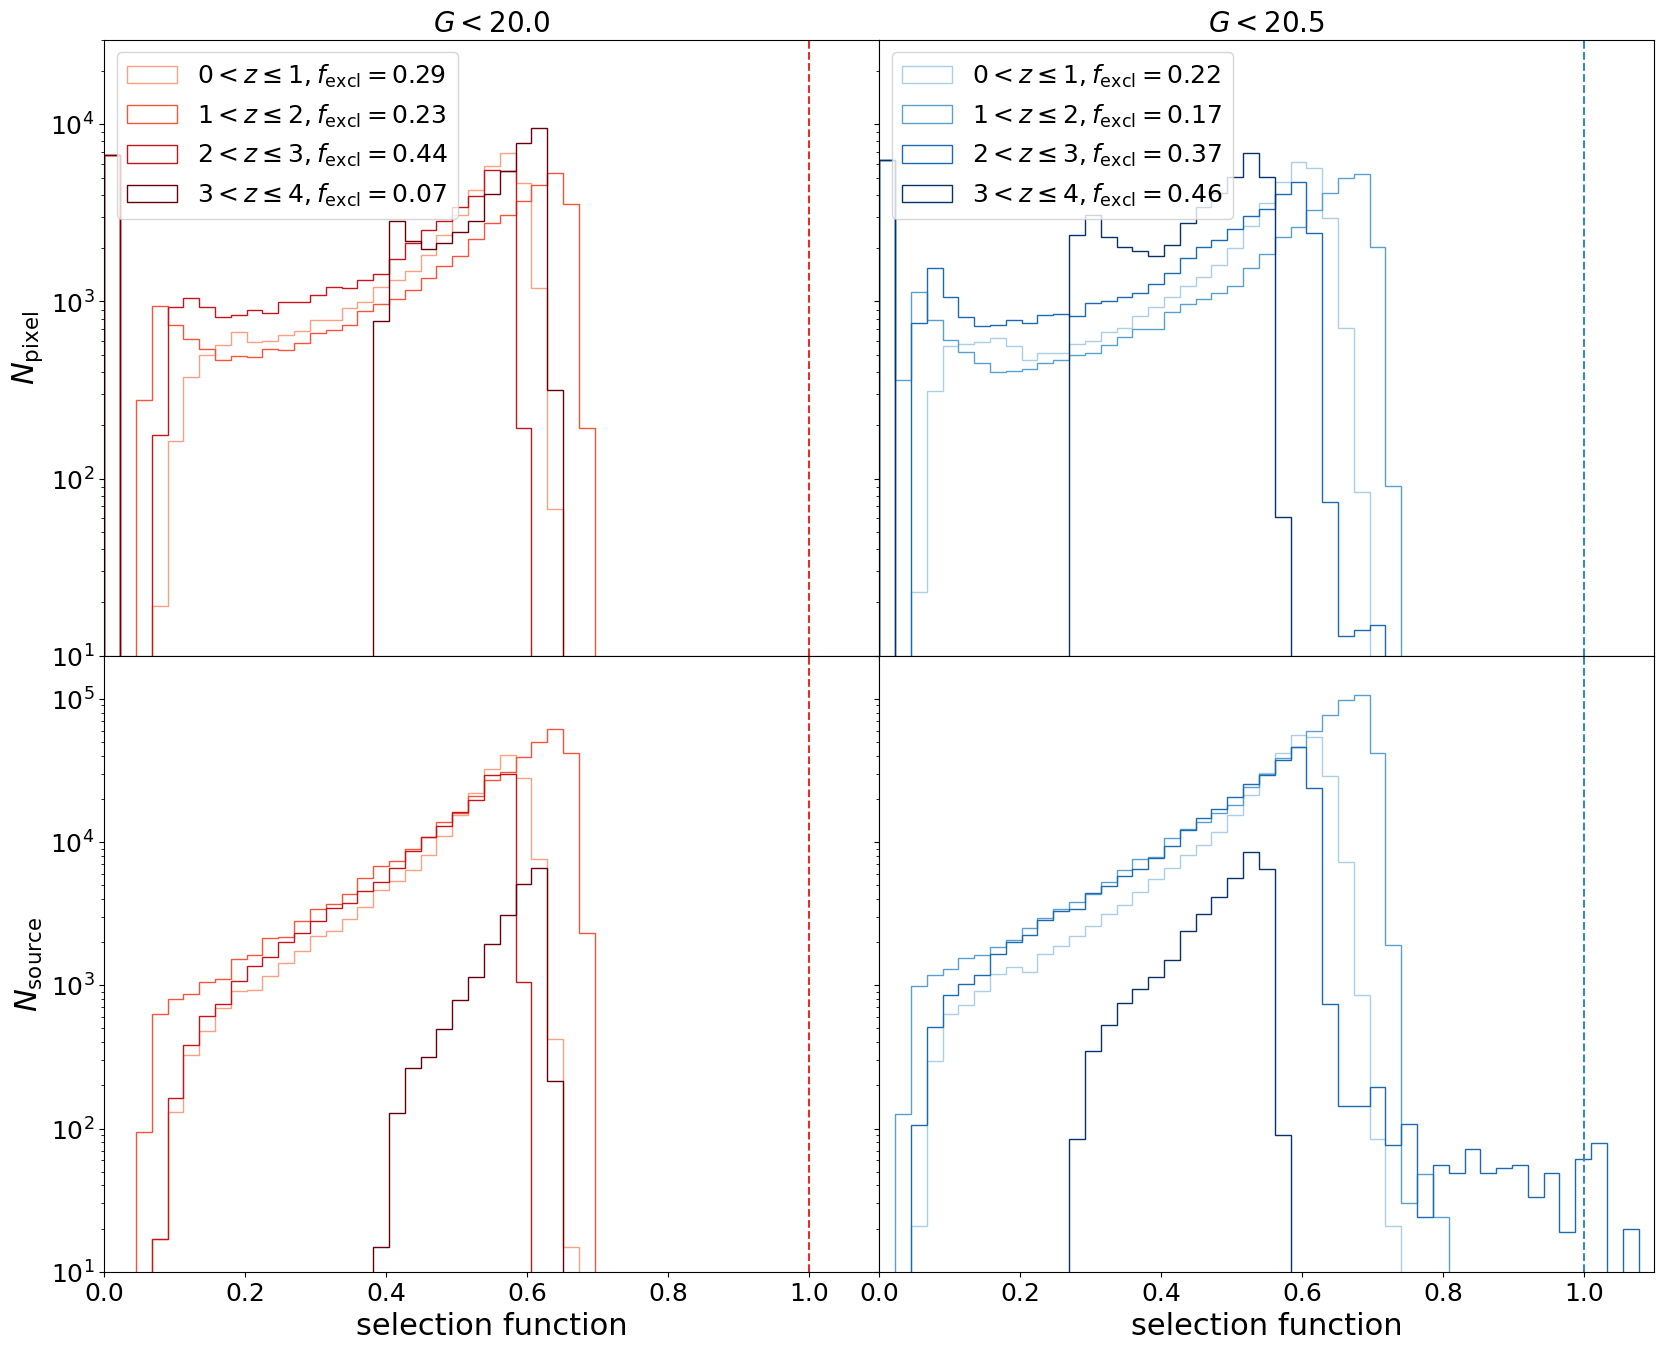

In [20]:
fig = plt.figure(figsize=(20,16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0)
fac_rand = 25
bins = np.linspace(0,1.1)
# xlims = [(0.475, 1.025), (0.475, 1.075)]
for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i])
    ax2 = fig.add_subplot(gs[i+2])
    
    for zbin in zbin_array[:-1]:

        _, _, _, _, _, frac, _ = quaia.make_bins(G_array[i], int(zbin),True, 'z', bins = zbin_array, tab_gcat_type = 'data',  method = 'minmax', 
                                                 fac_rand = fac_rand)
        _, _, _, _, weights1, _, selfunc_hi_bin0 = quaia.make_bins(G_array[i], int(zbin),True, 'z', bins = zbin_array, tab_gcat_type = 'data',
                                                                                                     method = 'minmax', fac_rand = fac_rand, 
                                                                                                                      mask_type = None)
        ax1.hist(selfunc_hi_bin0, log = True, histtype = 'step', color = cmaps[i][int(zbin)], 
                 label = '${:.0f}<z \leq{:.0f}, f_\mathrm{{excl}}={:.2f}$'.format(zbin, zbin+1, frac), bins = bins)
        ax2.hist(1/weights1, log = True, histtype = 'step', color = cmaps[i][int(zbin)], 
                 label = '${:.0f}<z \leq{:.0f}, f_\mathrm{{excl}}={:.2f}$'.format(zbin, zbin+1, frac), bins = bins)
        
    ax1.axvline(1, linestyle = '--', color = colors[i])
    ax2.axvline(1, linestyle = '--', color = colors[i])
    if i%2==1:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])
    else:
        ax1.set_ylabel('$N_\mathrm{pixel}$')
        ax2.set_ylabel('$N_\mathrm{source}$')
    ax1.set_xlim(0, 1.1)
    ax2.set_xlim(0, 1.1)
    ax1.set_ylim(1e1,3e4)
    ax2.set_ylim(1e1,2e5)
    ax1.set_title('$G<{}$'.format(G_array[i]))
    ax1.legend()
    ax1.set_xticklabels([])
    ax2.set_xlabel('selection function')

plt.show()

G20.0_Lsplit3bin0: 0.16              210964 vs 251950
G20.0_Lsplit3bin0: 0.00              251950 vs 251950
G20.0_Lsplit3bin1: 0.25              188449 vs 251950
G20.0_Lsplit3bin1: 0.00              251950 vs 251950
G20.0_Lsplit3bin2: 0.41              149723 vs 251950
G20.0_Lsplit3bin2: 0.00              251950 vs 251950
G20.5_Lsplit3bin0: 0.11              382895 vs 431834
G20.5_Lsplit3bin0: 0.00              431834 vs 431834
G20.5_Lsplit3bin1: 0.20              343394 vs 431834
G20.5_Lsplit3bin1: 0.00              431834 vs 431834
G20.5_Lsplit3bin2: 0.30              303012 vs 431834
G20.5_Lsplit3bin2: 0.00              431834 vs 431834


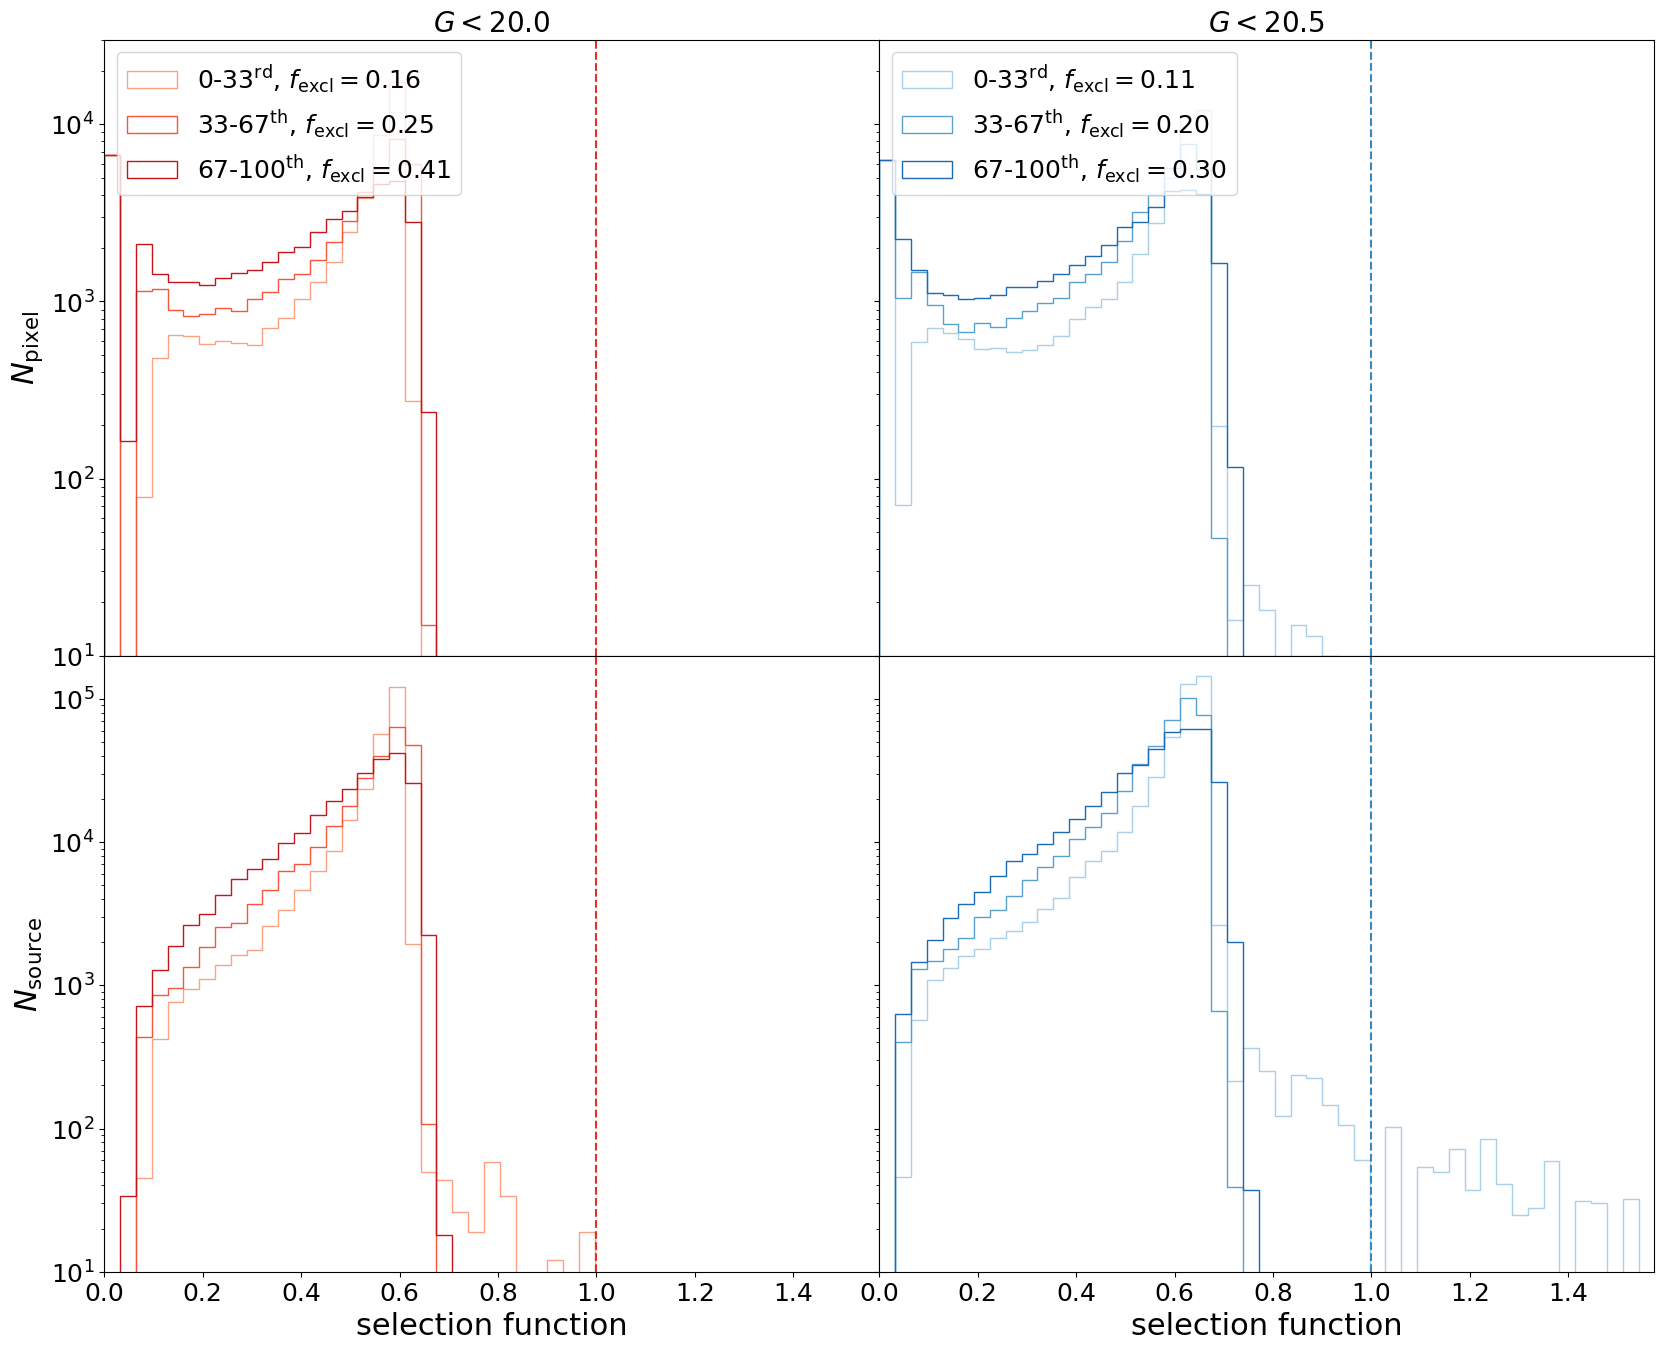

In [30]:
fig = plt.figure(figsize=(20,16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0)
fac_rand = 25
xlim = 0, 1.575
bins = np.linspace(xlim[0], xlim[1])
labels = ['0-33$^\mathrm{rd}$', '33-67$^\mathrm{th}$', '67-100$^\mathrm{th}$']
# xlims = [(0.475, 1.025), (0.475, 1.075)]
for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i])
    ax2 = fig.add_subplot(gs[i+2])
    
    for j in range(len(labels)):

        _, _, _, _, _, frac, _ = quaia.make_bins(G_array[i], j,True, 'L', n_bins = len(labels), tab_gcat_type = 'data',  method = 'split', 
                                                 fac_rand = fac_rand)
        _, _, _, _, weights1, _, selfunc_hi_bin0 = quaia.make_bins(G_array[i], j,True, 'L', n_bins = len(labels), tab_gcat_type = 'data',
                                                                                                     method = 'split', fac_rand = fac_rand, 
                                                                                                                      mask_type = None)
        ax1.hist(selfunc_hi_bin0, log = True, histtype = 'step', color = cmaps[i][j], 
                 label = '{}, $f_\mathrm{{excl}}={:.2f}$'.format(labels[j], frac), bins = bins)
        ax2.hist(1/weights1, log = True, histtype = 'step', color = cmaps[i][j], 
                 label = '{}, $f_\mathrm{{excl}}={:.2f}$'.format(labels[j], frac), bins = bins)
        
    ax1.axvline(1, linestyle = '--', color = colors[i])
    ax2.axvline(1, linestyle = '--', color = colors[i])
    if i%2==1:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])
    else:
        ax1.set_ylabel('$N_\mathrm{pixel}$')
        ax2.set_ylabel('$N_\mathrm{source}$')
    ax1.set_xlim(xlim[0], xlim[1])
    ax2.set_xlim(xlim[0], xlim[1])
    ax1.set_ylim(1e1,3e4)
    ax2.set_ylim(1e1,2e5)
    ax1.set_title('$G<{}$'.format(G_array[i]))
    ax1.legend()
    ax1.set_xticklabels([])
    ax2.set_xlabel('selection function')

plt.show()

G20.0_Lmin-32.0Lmax-28.0: 0.00              30750 vs 30757
G20.0_Lmin-32.0Lmax-28.0: 0.00              30757 vs 30757
G20.0_Lmin-28.0Lmax-26.0: 0.16              282491 vs 335369
G20.0_Lmin-28.0Lmax-26.0: 0.00              335369 vs 335369
G20.0_Lmin-26.0Lmax-24.0: 0.32              215344 vs 317040
G20.0_Lmin-26.0Lmax-24.0: 0.00              317040 vs 317040
G20.0_Lmin-24.0Lmax-20.0: 0.68              23203 vs 72658
G20.0_Lmin-24.0Lmax-20.0: 0.00              72658 vs 72658
G20.5_Lmin-32.0Lmax-28.0: 0.00              32181 vs 32189
G20.5_Lmin-32.0Lmax-28.0: 0.00              32189 vs 32189
G20.5_Lmin-28.0Lmax-26.0: 0.13              397510 vs 458263
G20.5_Lmin-28.0Lmax-26.0: 0.00              458263 vs 458263
G20.5_Lmin-26.0Lmax-24.0: 0.21              513742 vs 646971
G20.5_Lmin-26.0Lmax-24.0: 0.00              646971 vs 646971
G20.5_Lmin-24.0Lmax-20.0: 0.53              74562 vs 158039
G20.5_Lmin-24.0Lmax-20.0: 0.00              158039 vs 158039


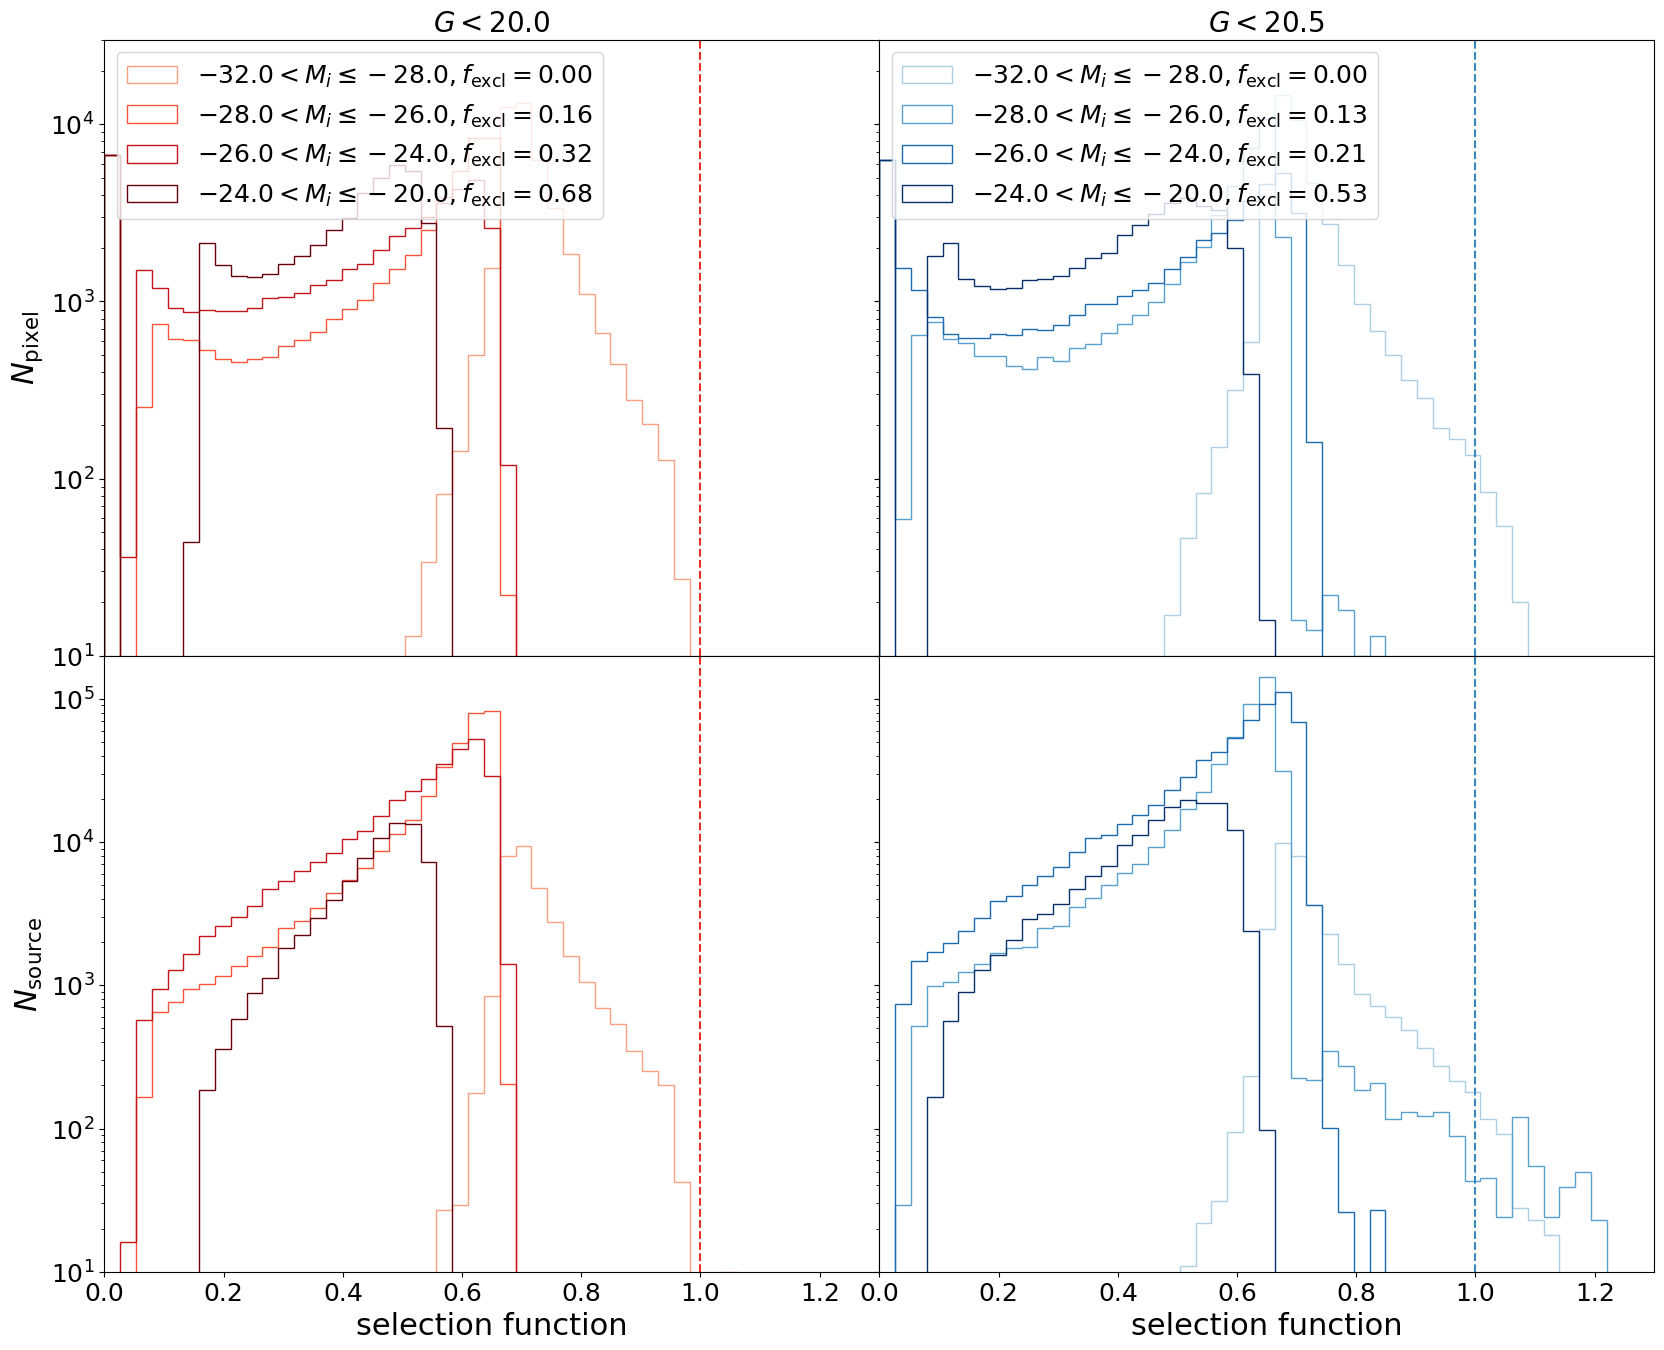

In [36]:
fig = plt.figure(figsize=(20,16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0)
fac_rand = 25
xlim = 0, 1.3
bins = np.linspace(xlim[0], xlim[1])
L_bins = [-32.0, -28.0, -26.0, -24.0, -20.0]
# xlims = [(0.475, 1.025), (0.475, 1.075)]
for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i])
    ax2 = fig.add_subplot(gs[i+2])
    
    for j in range(len(L_bins)-1):

        _, _, _, _, _, frac, _ = quaia.make_bins(G_array[i], j,True, 'L', bins = L_bins, tab_gcat_type = 'data',  method = 'minmax', 
                                                 fac_rand = fac_rand)
        _, _, _, _, weights1, _, selfunc_hi_bin0 = quaia.make_bins(G_array[i], j, True, 'L', bins = L_bins, tab_gcat_type = 'data',
                                                                                                     method = 'minmax', fac_rand = fac_rand, 
                                                                                                                      mask_type = None)
        ax1.hist(selfunc_hi_bin0, log = True, histtype = 'step', color = cmaps[i][j], 
                 label = '${}<M_i\leq{}, f_\mathrm{{excl}}={:.2f}$'.format(L_bins[j], L_bins[j+1], frac), bins = bins)
        ax2.hist(1/weights1, log = True, histtype = 'step', color = cmaps[i][j], 
                 label = '${}<M_i\leq{}, f_\mathrm{{excl}}={:.2f}$'.format(L_bins[j], L_bins[j+1], frac), bins = bins)
        
    ax1.axvline(1, linestyle = '--', color = colors[i])
    ax2.axvline(1, linestyle = '--', color = colors[i])
    if i%2==1:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])
    else:
        ax1.set_ylabel('$N_\mathrm{pixel}$')
        ax2.set_ylabel('$N_\mathrm{source}$')
    ax1.set_xlim(xlim[0], xlim[1])
    ax2.set_xlim(xlim[0], xlim[1])
    ax1.set_ylim(1e1,3e4)
    ax2.set_ylim(1e1,2e5)
    ax1.set_title('$G<{}$'.format(G_array[i]))
    ax1.legend()
    ax1.set_xticklabels([])
    ax2.set_xlabel('selection function')

plt.show()

G20.0_Lmin-32.0Lmax-27.0: 0.11              136805 vs 153834
G20.0_Lmin-32.0Lmax-27.0: 0.00              153834 vs 153834
Npixel range: (0.0, 1.2516246357887895)
Nsource range: (0.1388249903297794, 1.2516246357887895)

G20.0_Lmin-27.0Lmax-26.0: 0.28              153783 vs 212292
G20.0_Lmin-27.0Lmax-26.0: 0.00              212292 vs 212292
Npixel range: (0.0, 0.6437230578316521)
Nsource range: (0.08949047126277537, 0.6437230578316521)

G20.0_Lmin-26.0Lmax-25.0: 0.34              140460 vs 212564
G20.0_Lmin-26.0Lmax-25.0: 0.00              212564 vs 212564
Npixel range: (0.0, 0.6387705994700191)
Nsource range: (0.06915060556189997, 0.6387705994700191)

G20.0_Lmin-25.0Lmax-20.0: 0.47              93707 vs 177134
G20.0_Lmin-25.0Lmax-20.0: 0.00              177134 vs 177134
Npixel range: (0.0, 0.6542776379898616)
Nsource range: (0.07041916021121793, 0.6542776379898616)

G20.5_Lmin-32.0Lmax-27.0: 0.08              156465 vs 170931
G20.5_Lmin-32.0Lmax-27.0: 0.00              170931 vs 170931


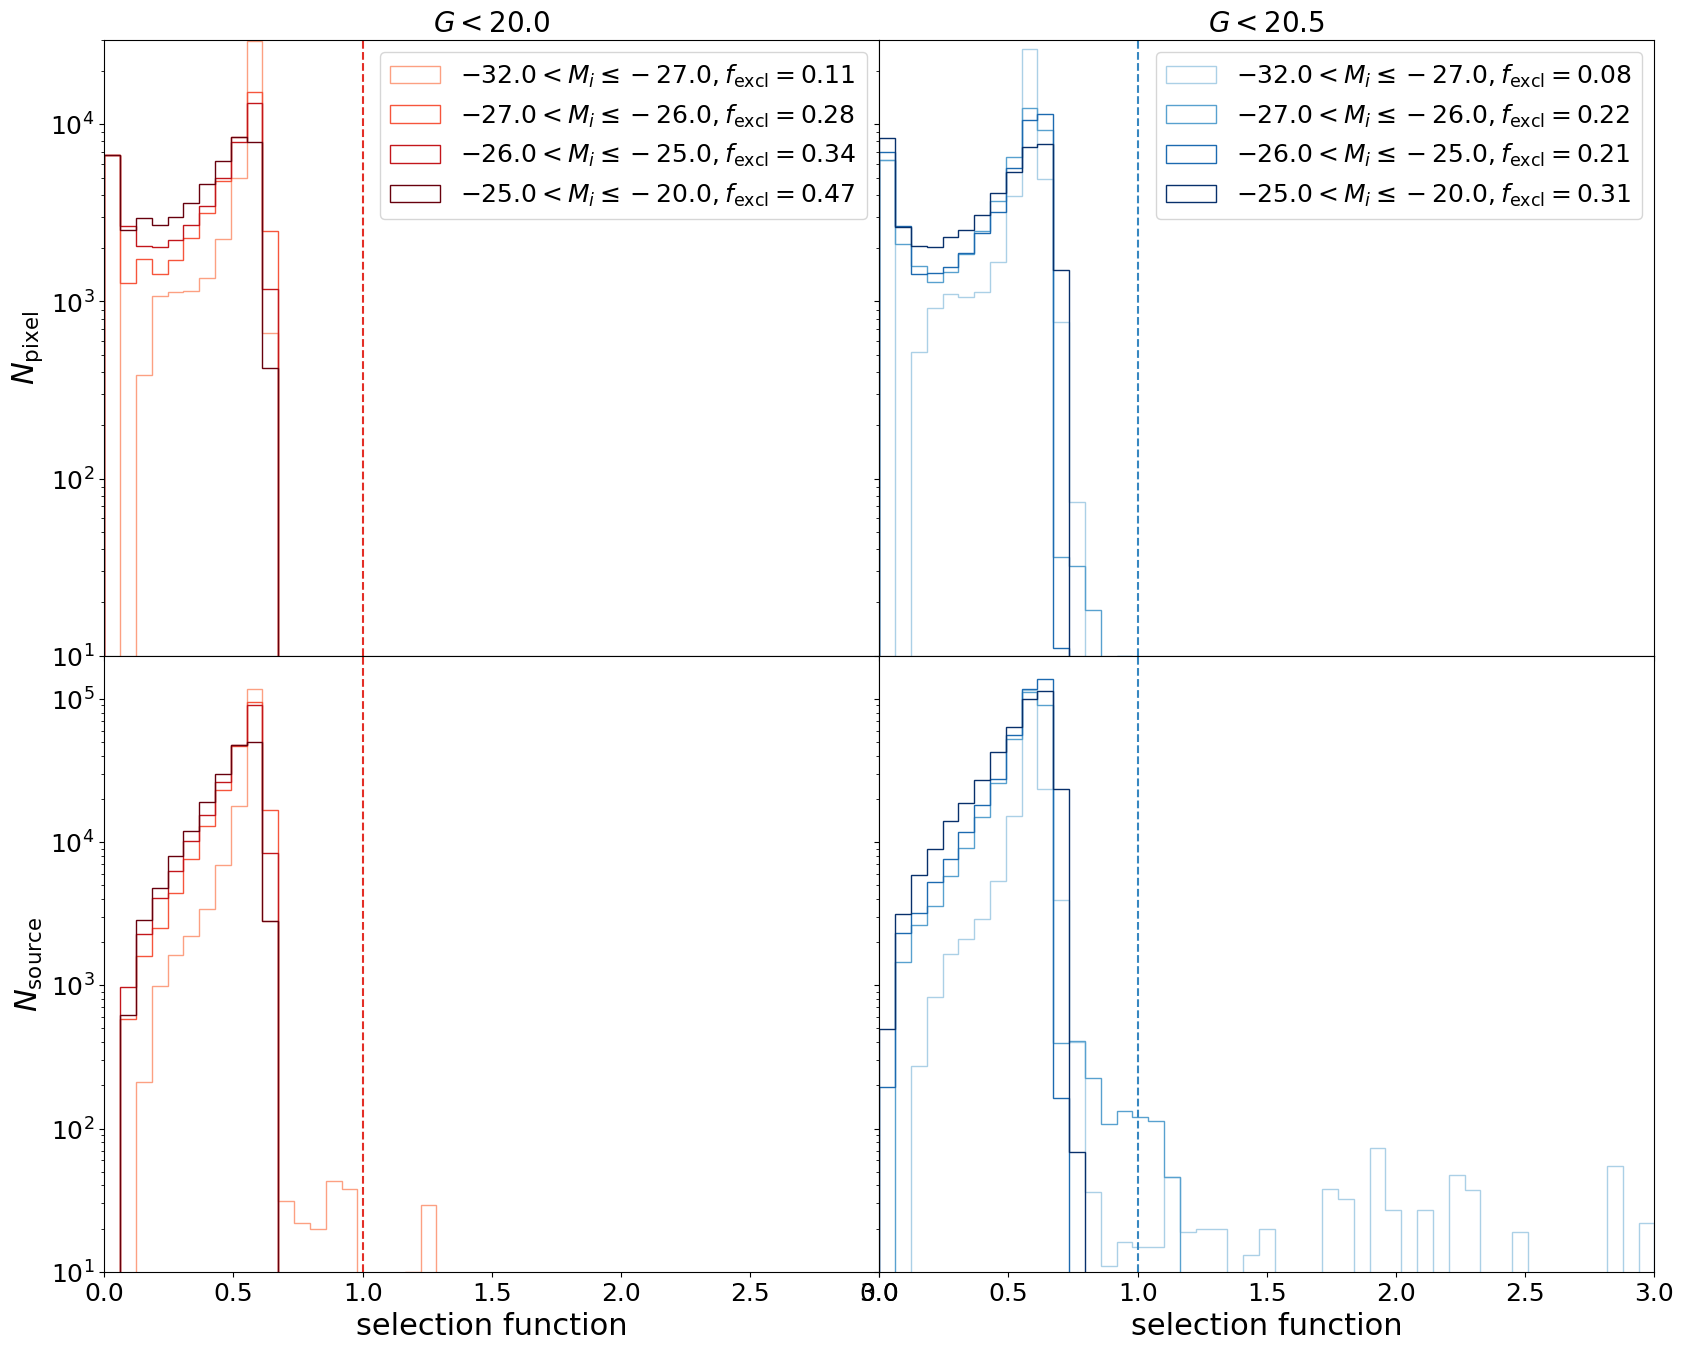

In [44]:
fig = plt.figure(figsize=(20,16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0)
fac_rand = 25
xlim = 0, 3
bins = np.linspace(xlim[0], xlim[1])
L_bins = [-32.0, -27.0, -26.0, -25.0, -20.0]
# xlims = [(0.475, 1.025), (0.475, 1.075)]
for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i])
    ax2 = fig.add_subplot(gs[i+2])
    
    for j in range(len(L_bins)-1):

        _, _, _, _, _, frac, _ = quaia.make_bins(G_array[i], j,True, 'L', bins = L_bins, tab_gcat_type = 'data',  method = 'minmax', 
                                                 fac_rand = fac_rand)
        _, _, _, _, weights1, _, selfunc_hi_bin0 = quaia.make_bins(G_array[i], j, True, 'L', bins = L_bins, tab_gcat_type = 'data',
                                                                                                     method = 'minmax', fac_rand = fac_rand, 
                                                                                                                      mask_type = None)
        ax1.hist(selfunc_hi_bin0, log = True, histtype = 'step', color = cmaps[i][j], 
                 label = '${}<M_i\leq{}, f_\mathrm{{excl}}={:.2f}$'.format(L_bins[j], L_bins[j+1], frac), bins = bins)
        ax2.hist(1/weights1, log = True, histtype = 'step', color = cmaps[i][j], 
                 label = '${}<M_i\leq{}, f_\mathrm{{excl}}={:.2f}$'.format(L_bins[j], L_bins[j+1], frac), bins = bins)
        
        print('Npixel range: ({}, {})'.format(np.min(selfunc_hi_bin0), np.max(selfunc_hi_bin0)))
        print('Nsource range: ({}, {})\n'.format(np.min(1/weights1), np.max(1/weights1)))
        
    ax1.axvline(1, linestyle = '--', color = colors[i])
    ax2.axvline(1, linestyle = '--', color = colors[i])
    if i%2==1:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])
    else:
        ax1.set_ylabel('$N_\mathrm{pixel}$')
        ax2.set_ylabel('$N_\mathrm{source}$')
    ax1.set_xlim(xlim[0], xlim[1])
    ax2.set_xlim(xlim[0], xlim[1])
    ax1.set_ylim(1e1,3e4)
    ax2.set_ylim(1e1,2e5)
    ax1.set_title('$G<{}$'.format(G_array[i]))
    ax1.legend()
    ax1.set_xticklabels([])
    ax2.set_xlabel('selection function')

plt.show()

### Post-masking

G20.0_zmin0.0zmax1.0: 0.29              142897 vs 200785
G20.0_zmin1.0zmax2.0: 0.23              285720 vs 369335
G20.0_zmin2.0zmax3.0: 0.44              92402 vs 165277
G20.0_zmin3.0zmax4.0: 0.07              18618 vs 20035
G20.5_zmin0.0zmax1.0: 0.22              253398 vs 324336
G20.5_zmin1.0zmax2.0: 0.17              536368 vs 648196
G20.5_zmin2.0zmax3.0: 0.37              179640 vs 286508
G20.5_zmin3.0zmax4.0: 0.46              19252 vs 35630


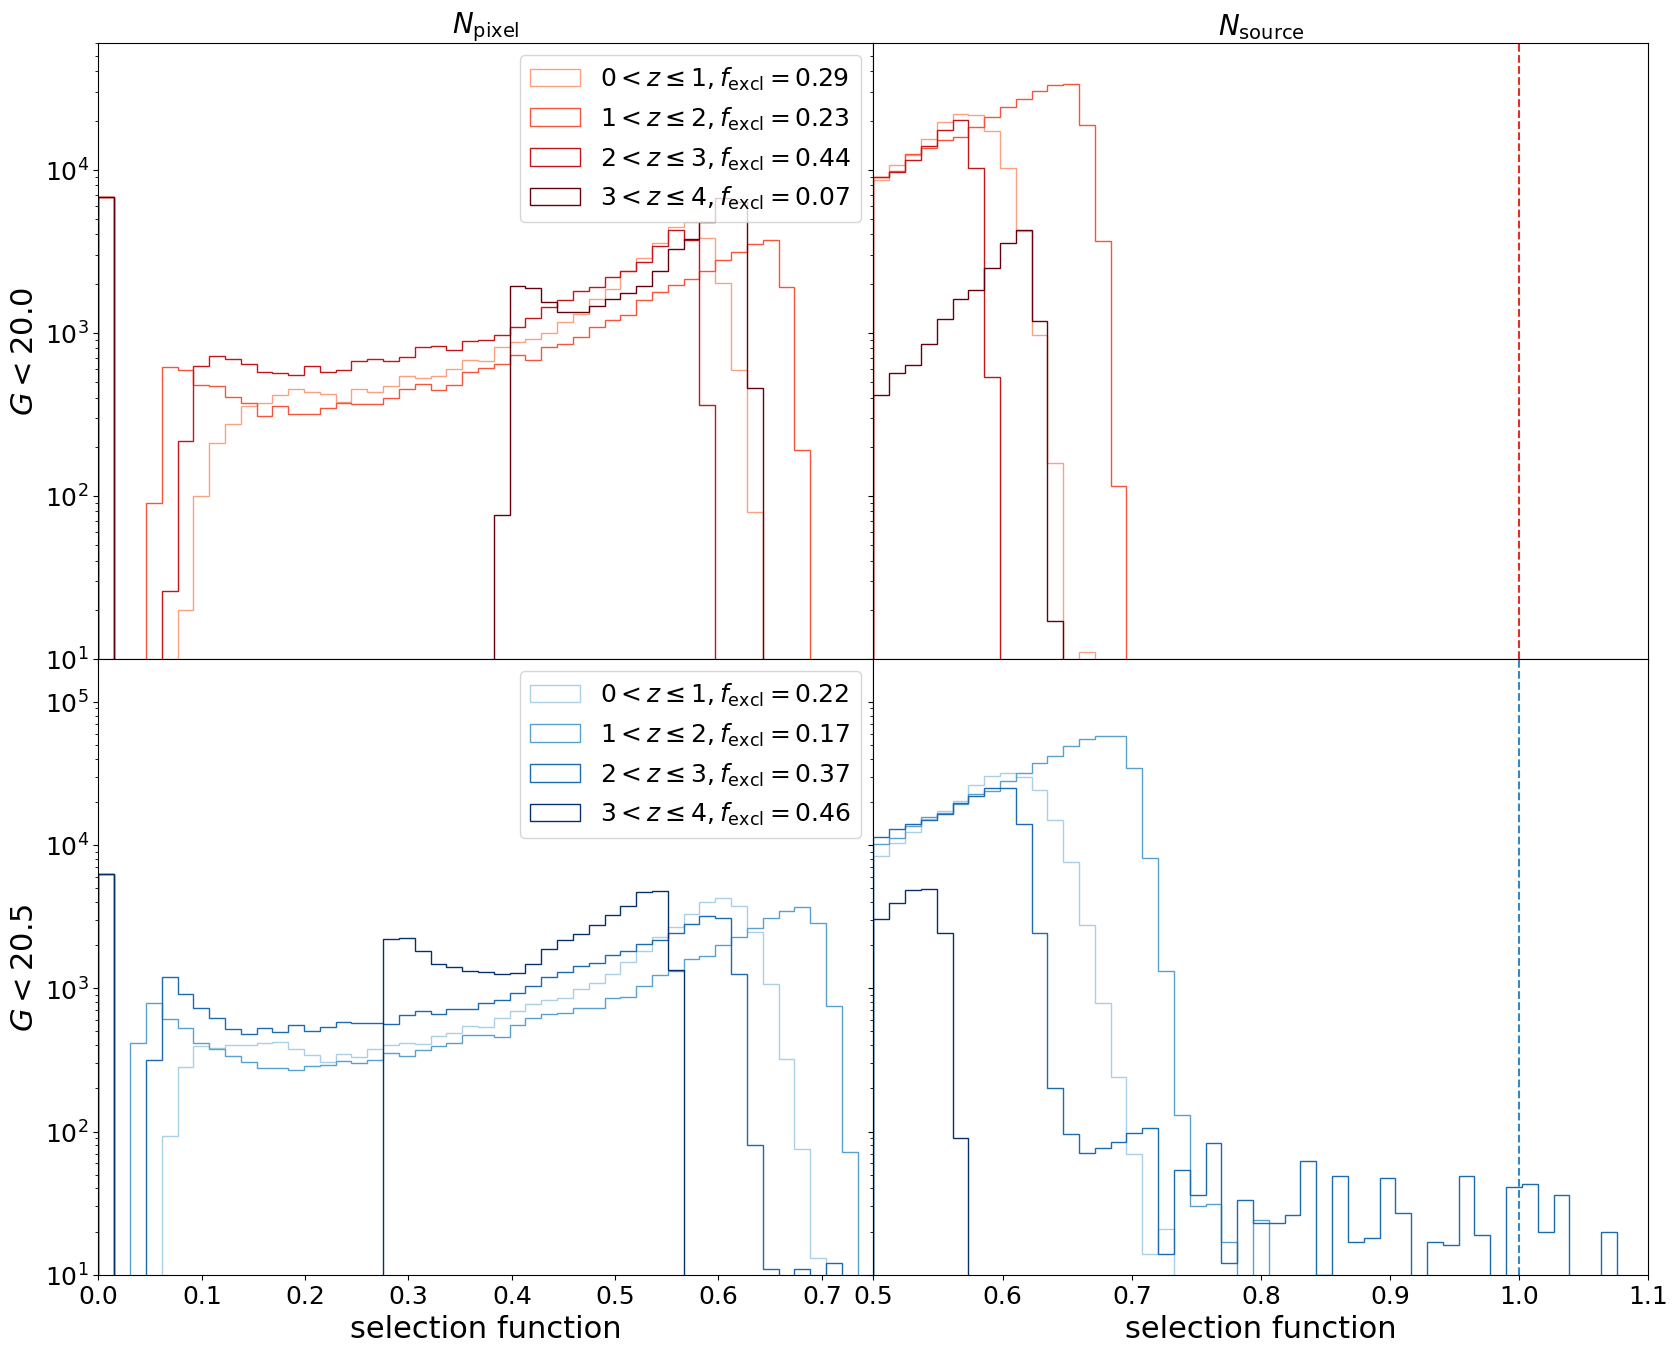

In [56]:
fig = plt.figure(figsize=(20,16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0)
fac_rand = 25
xlims = [(0, 0.75), (0.5, 1.1)]
ylims = [(1e1,6e4), (1e1,2e5)]
for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i*2])
    ax2 = fig.add_subplot(gs[i*2+1])
    
    for zbin in zbin_array[:-1]:

        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, weights1, frac, selfunc_hi_bin0 = quaia.make_bins(G_array[i], int(zbin),True, 'z',
                                                                                                     bins = zbin_array, tab_gcat_type = 'data',
                                                                                                     method = 'minmax', fac_rand = fac_rand)
        ax1.hist(selfunc_hi_bin0, log = True, histtype = 'step', color = cmaps[i][int(zbin)], 
                 label = '${:.0f}<z \leq{:.0f}, f_\mathrm{{excl}}={:.2f}$'.format(zbin, zbin+1, frac), bins = np.linspace(xlims[0][0],xlims[0][1]))
        ax2.hist(1/weights1, log = True, histtype = 'step', color = cmaps[i][int(zbin)], 
                 label = '${:.0f}<z \leq{:.0f}, f_\mathrm{{excl}}={:.2f}$'.format(zbin, zbin+1, frac), bins = np.linspace(xlims[1][0],xlims[1][1]))
        
    ax1.axvline(1, linestyle = '--', color = colors[i])
    ax2.axvline(1, linestyle = '--', color = colors[i])
    ax1.set_ylabel('$G<{}$'.format(G_array[i]))
    ax2.set_yticklabels([])
    ax1.set_xlim(xlims[0])
    ax2.set_xlim(xlims[1])
    ax1.set_ylim(ylims[i])
    ax2.set_ylim(ylims[i])
    ax1.legend()
    if i==1:
        ax1.set_xlabel('selection function')
        ax2.set_xlabel('selection function')
    else:
        ax1.set_title('$N_\mathrm{pixel}$')
        ax2.set_title('$N_\mathrm{source}$')
        ax1.set_xticklabels([])
        ax2.set_xticklabels([])

plt.show()

G20.0_Lsplit3bin0: 0.16              210964 vs 251950
G20.0_Lsplit3bin1: 0.25              188449 vs 251950
G20.0_Lsplit3bin2: 0.41              149723 vs 251950
G20.5_Lsplit3bin0: 0.11              382895 vs 431834
G20.5_Lsplit3bin1: 0.20              343394 vs 431834
G20.5_Lsplit3bin2: 0.30              303012 vs 431834


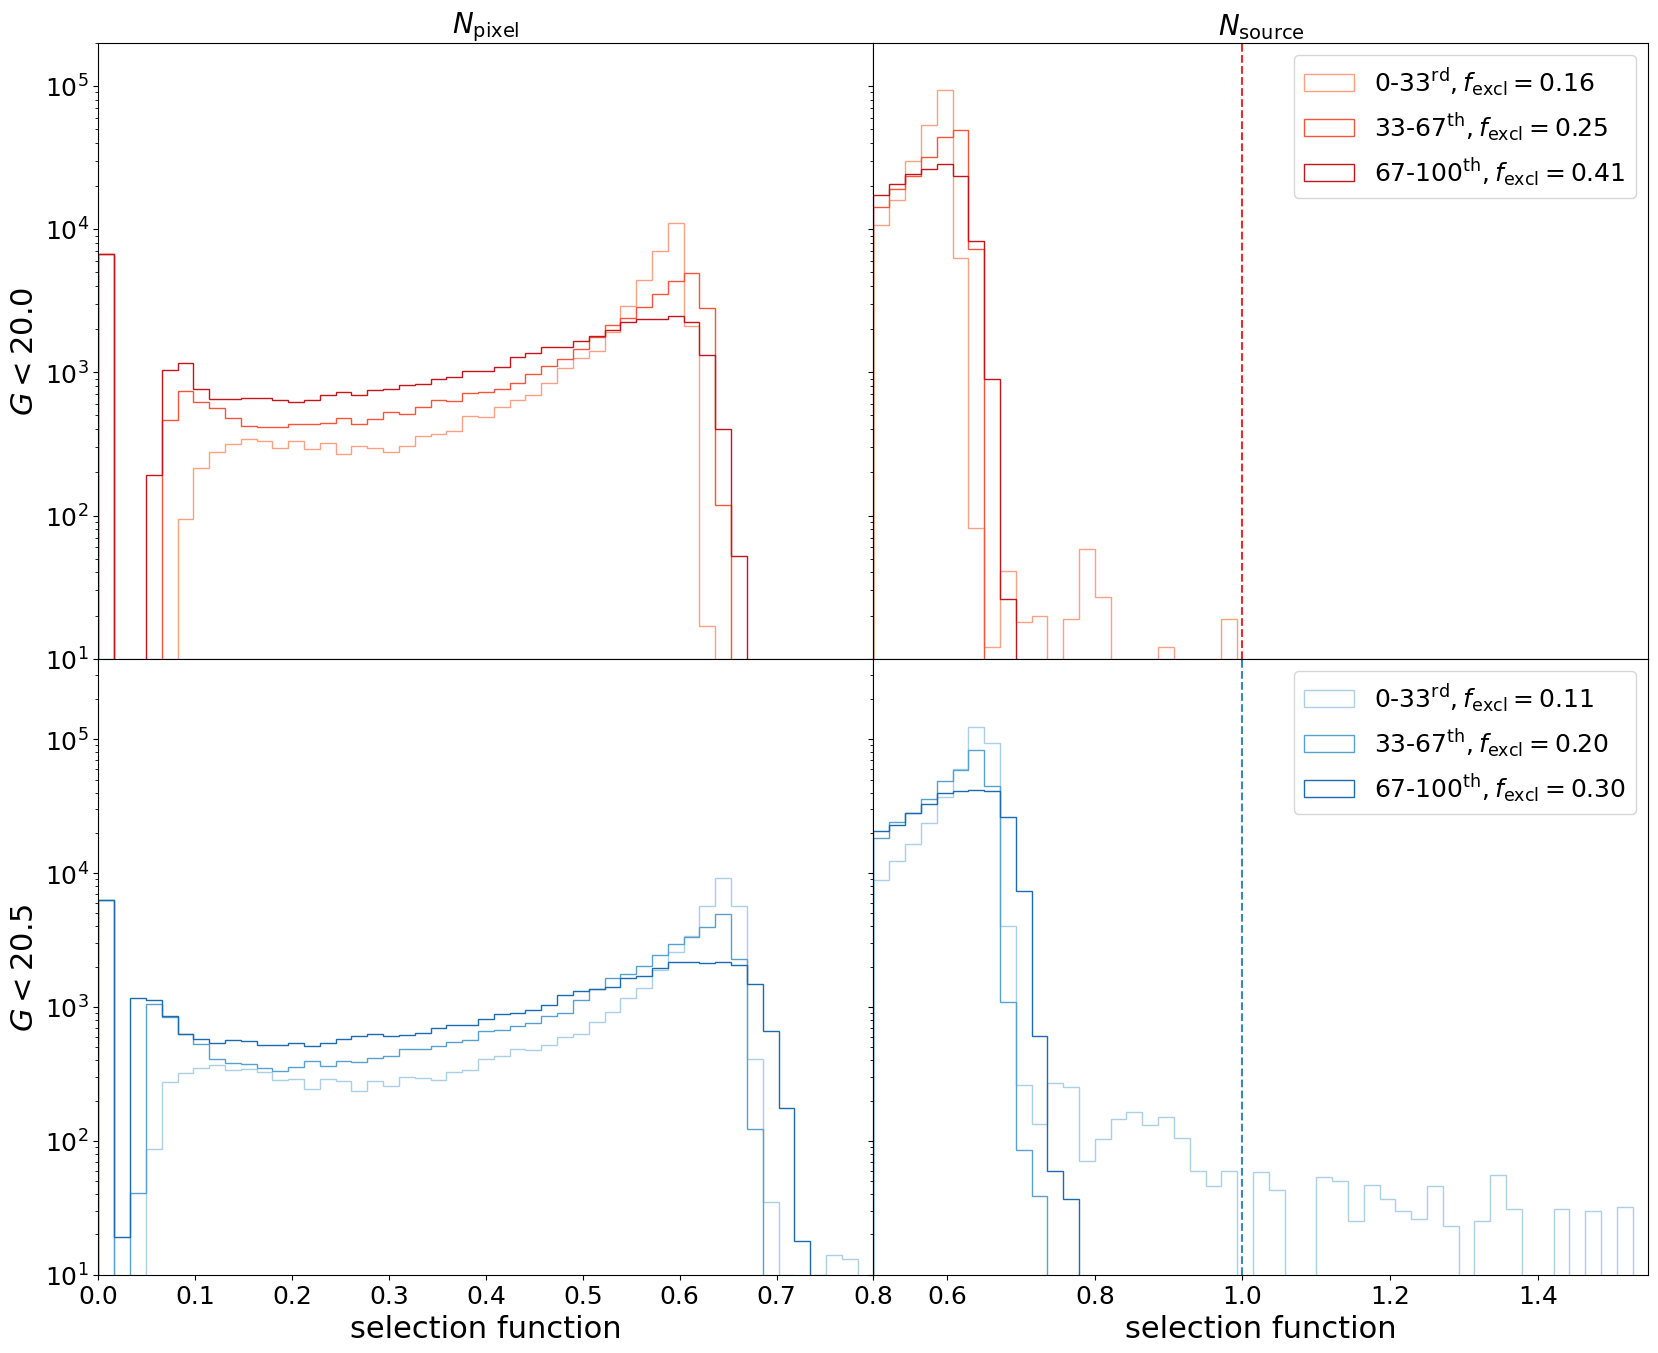

In [50]:
fig = plt.figure(figsize=(20,16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0)
fac_rand = 25
labels = ['0-33$^\mathrm{rd}$', '33-67$^\mathrm{th}$', '67-100$^\mathrm{th}$']
xlims = [(0, 0.8), (0.5, 1.55)]
ylims = [(1e1,2e5), (1e1,4e5)]
for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i*2])
    ax2 = fig.add_subplot(gs[i*2+1])
    
    for j in range(len(labels)):

        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, weights1, frac, selfunc_hi_bin0 = quaia.make_bins(G_array[i], j, True, 'L', 
                                                                                                     n_bins = len(labels), tab_gcat_type = 'data',
                                                                                                     method = 'split', fac_rand = fac_rand)
        ax1.hist(selfunc_hi_bin0, log = True, histtype = 'step', color = cmaps[i][j], 
                 label = '{}$, f_\mathrm{{excl}}={:.2f}$'.format(labels[j], frac), bins = np.linspace(xlims[0][0],xlims[0][1]))
        ax2.hist(1/weights1, log = True, histtype = 'step', color = cmaps[i][j], 
                 label = '{}$, f_\mathrm{{excl}}={:.2f}$'.format(labels[j], frac), bins = np.linspace(xlims[1][0],xlims[1][1]))
        
    ax1.axvline(1, linestyle = '--', color = colors[i])
    ax2.axvline(1, linestyle = '--', color = colors[i])
    ax1.set_ylabel('$G<{}$'.format(G_array[i]))
    ax2.set_yticklabels([])
    ax1.set_xlim(xlims[0])
    ax2.set_xlim(xlims[1])
    ax1.set_ylim(ylims[i])
    ax2.set_ylim(ylims[i])
    ax2.legend()
    if i==1:
        ax1.set_xlabel('selection function')
        ax2.set_xlabel('selection function')
    else:
        ax1.set_title('$N_\mathrm{pixel}$')
        ax2.set_title('$N_\mathrm{source}$')
        ax1.set_xticklabels([])
        ax2.set_xticklabels([])

plt.show()

G20.0_Lmin-32.0Lmax-28.0: 0.00              30750 vs 30757
G20.0_Lmin-28.0Lmax-26.0: 0.16              282491 vs 335369
G20.0_Lmin-26.0Lmax-24.0: 0.32              215344 vs 317040
G20.0_Lmin-24.0Lmax-20.0: 0.68              23203 vs 72658
G20.5_Lmin-32.0Lmax-28.0: 0.00              32181 vs 32189
G20.5_Lmin-28.0Lmax-26.0: 0.13              397510 vs 458263
G20.5_Lmin-26.0Lmax-24.0: 0.21              513742 vs 646971
G20.5_Lmin-24.0Lmax-20.0: 0.53              74562 vs 158039


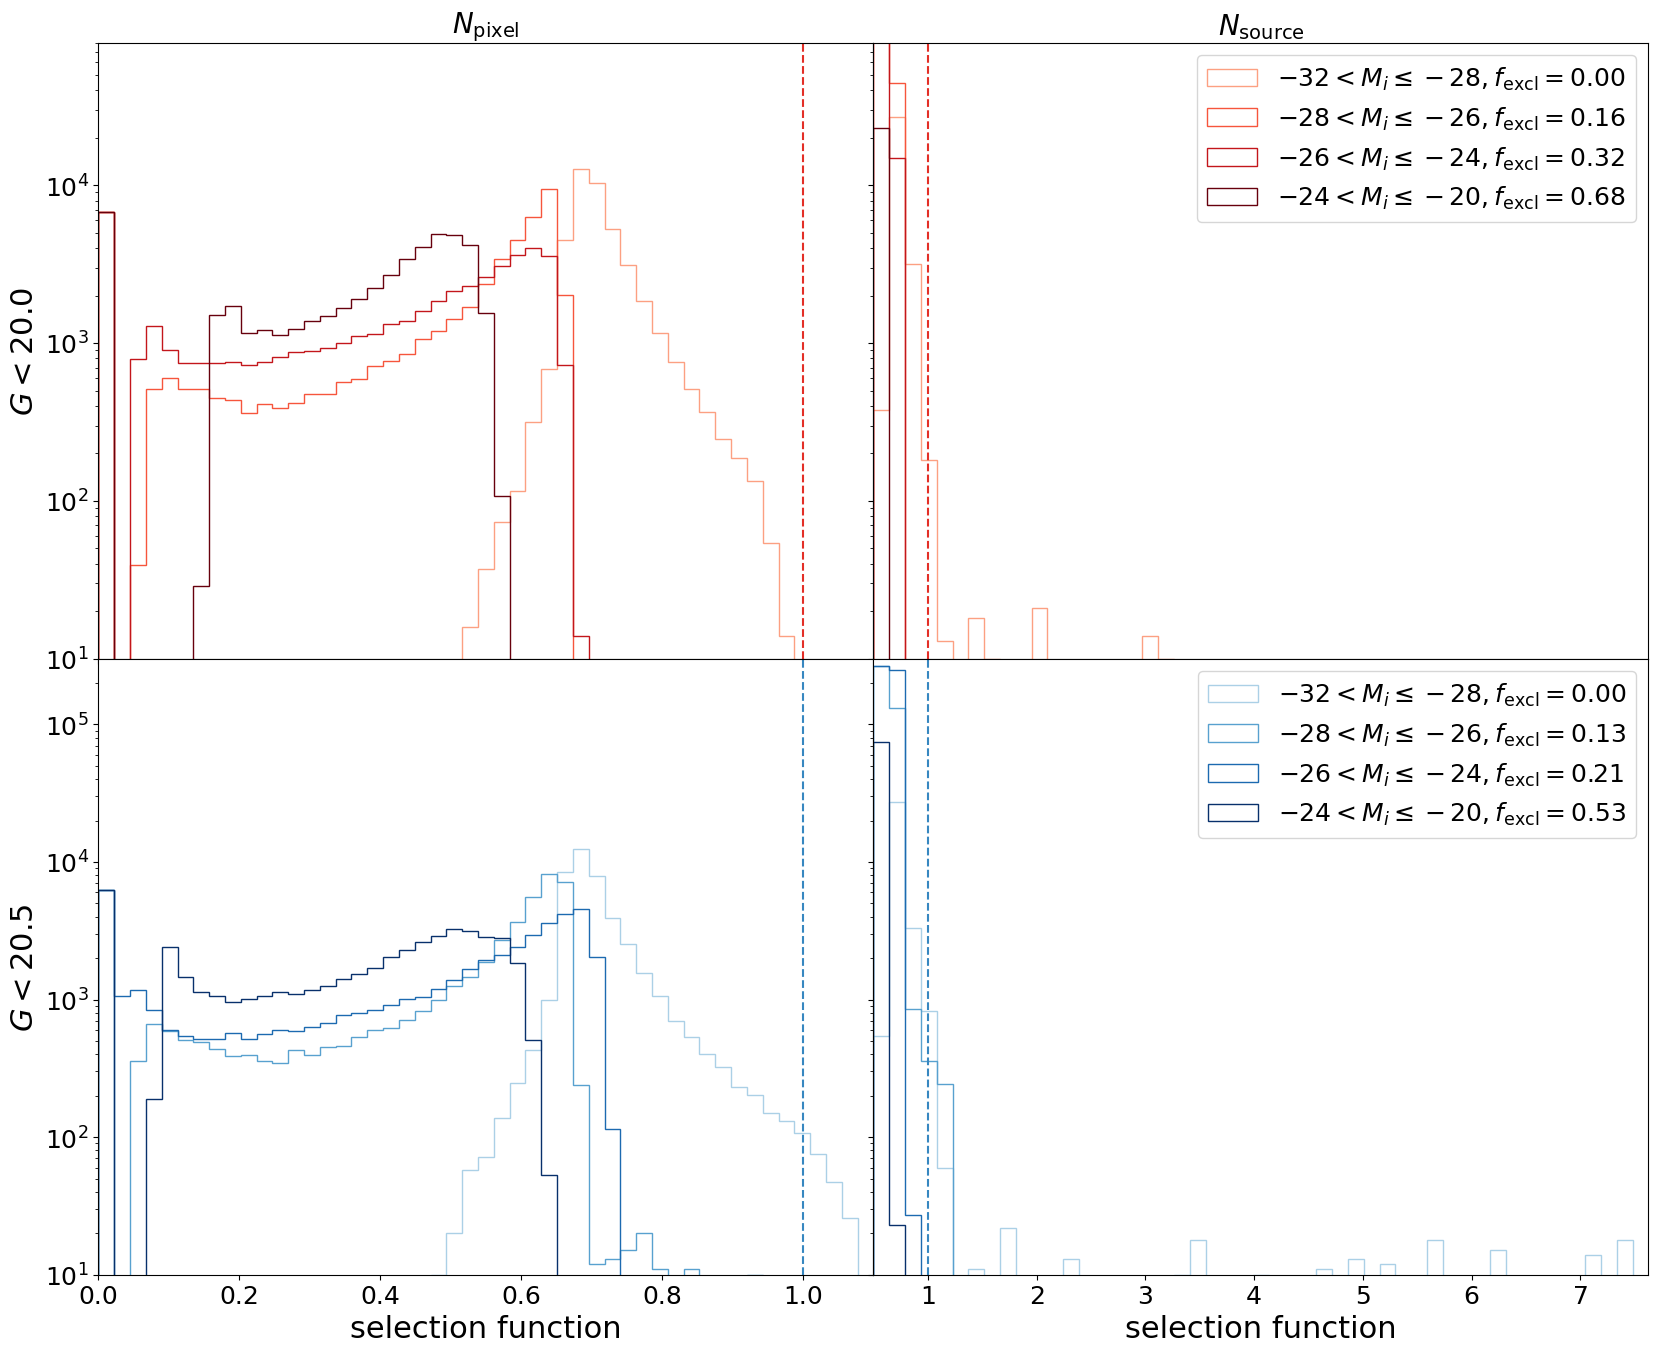

In [54]:
fig = plt.figure(figsize=(20,16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0)
fac_rand = 25
xlims = [(0, 1.1), (0.5, 7.625)]
ylims = [(1e1,8e4), (1e1,3e5)]
L_array = [-32.0, -28.0, -26.0, -24.0, -20.0]
for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i*2])
    ax2 = fig.add_subplot(gs[i*2+1])
    
    for j in range(len(L_array)-1):

        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, weights1, frac, selfunc_hi_bin0 = quaia.make_bins(G_array[i], j, True, 'L', 
                                                                                                     bins = L_array, tab_gcat_type = 'data',
                                                                                                     method = 'minmax', fac_rand = fac_rand)
        ax1.hist(selfunc_hi_bin0, log = True, histtype = 'step', color = cmaps[i][j], 
                 label = '${:.0f}<M_i \leq{:.0f}, f_\mathrm{{excl}}={:.2f}$'.format(L_array[j], L_array[j+1], frac), 
                 bins = np.linspace(xlims[0][0],xlims[0][1]))
        ax2.hist(1/weights1, log = True, histtype = 'step', color = cmaps[i][j], 
                 label = '${:.0f}<M_i \leq{:.0f}, f_\mathrm{{excl}}={:.2f}$'.format(L_array[j], L_array[j+1], frac), 
                 bins = np.linspace(xlims[1][0],xlims[1][1]))
        
    ax1.axvline(1, linestyle = '--', color = colors[i])
    ax2.axvline(1, linestyle = '--', color = colors[i])
    ax1.set_ylabel('$G<{}$'.format(G_array[i]))
    ax2.set_yticklabels([])
    ax1.set_xlim(xlims[0])
    ax2.set_xlim(xlims[1])
    ax1.set_ylim(ylims[i])
    ax2.set_ylim(ylims[i])
    ax2.legend()
    if i==1:
        ax1.set_xlabel('selection function')
        ax2.set_xlabel('selection function')
    else:
        ax1.set_title('$N_\mathrm{pixel}$')
        ax2.set_title('$N_\mathrm{source}$')
        ax1.set_xticklabels([])
        ax2.set_xticklabels([])

plt.show()

G20.0_Lmin-32.0Lmax-27.0: 0.11              136805 vs 153834
G20.0_Lmin-27.0Lmax-26.0: 0.28              153783 vs 212292
G20.0_Lmin-26.0Lmax-25.0: 0.34              140460 vs 212564
G20.0_Lmin-25.0Lmax-20.0: 0.47              93707 vs 177134
G20.5_Lmin-32.0Lmax-27.0: 0.08              156465 vs 170931
G20.5_Lmin-27.0Lmax-26.0: 0.22              250505 vs 319521
G20.5_Lmin-26.0Lmax-25.0: 0.21              303263 vs 385567
G20.5_Lmin-25.0Lmax-20.0: 0.31              289746 vs 419443


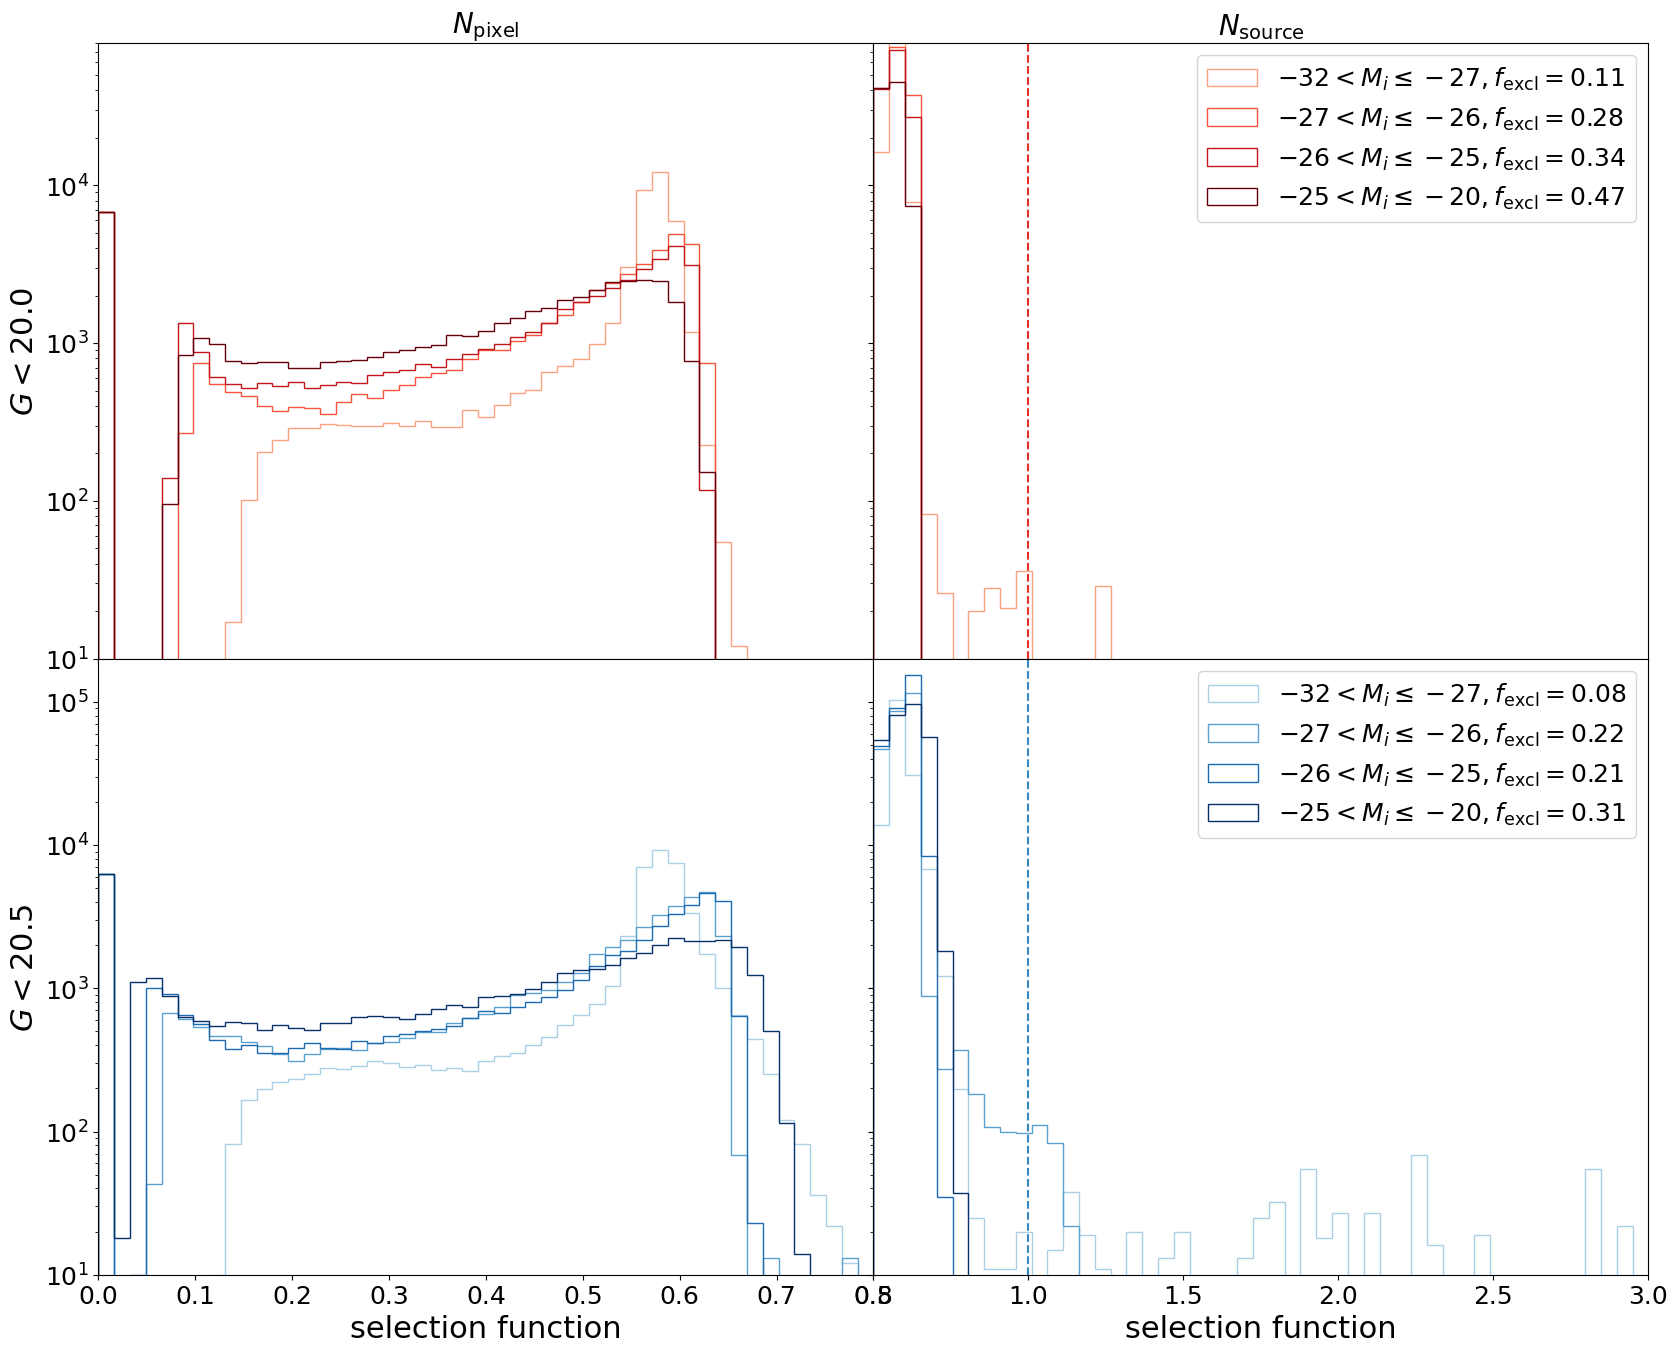

In [52]:
fig = plt.figure(figsize=(20,16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0)
fac_rand = 25
xlims = [(0, 0.8), (0.5, 3)]
ylims = [(1e1,8e4), (1e1,2e5)]
L_array = [-32.0, -27.0, -26.0, -25.0, -20.0]
for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i*2])
    ax2 = fig.add_subplot(gs[i*2+1])
    
    for j in range(len(L_array)-1):

        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, weights1, frac, selfunc_hi_bin0 = quaia.make_bins(G_array[i], j, True, 'L', 
                                                                                                     bins = L_array, tab_gcat_type = 'data',
                                                                                                     method = 'minmax', fac_rand = fac_rand)
        ax1.hist(selfunc_hi_bin0, log = True, histtype = 'step', color = cmaps[i][j], 
                 label = '${:.0f}<M_i \leq{:.0f}, f_\mathrm{{excl}}={:.2f}$'.format(L_array[j], L_array[j+1], frac), 
                 bins = np.linspace(xlims[0][0],xlims[0][1]))
        ax2.hist(1/weights1, log = True, histtype = 'step', color = cmaps[i][j], 
                 label = '${:.0f}<M_i \leq{:.0f}, f_\mathrm{{excl}}={:.2f}$'.format(L_array[j], L_array[j+1], frac), 
                 bins = np.linspace(xlims[1][0],xlims[1][1]))
        
    ax1.axvline(1, linestyle = '--', color = colors[i])
    ax2.axvline(1, linestyle = '--', color = colors[i])
    ax1.set_ylabel('$G<{}$'.format(G_array[i]))
    ax2.set_yticklabels([])
    ax1.set_xlim(xlims[0])
    ax2.set_xlim(xlims[1])
    ax1.set_ylim(ylims[i])
    ax2.set_ylim(ylims[i])
    ax2.legend()
    if i==1:
        ax1.set_xlabel('selection function')
        ax2.set_xlabel('selection function')
    else:
        ax1.set_title('$N_\mathrm{pixel}$')
        ax2.set_title('$N_\mathrm{source}$')
        ax1.set_xticklabels([])
        ax2.set_xticklabels([])

plt.show()

# Compute clustering in four z bins
## $\xi(s)$
### Fiducial

In [14]:
# Create the bins array
rmin = 0.1 # 0.1 # start higher
rmax = 180.0 # 20.0 #50.0
nbins = 20 #90 #20
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

# # Create the bins array
# rmin = 0.1 # 0.1 # start higher
# rmax = 155.0 # 20.0 #50.0
# nbins = 20 #90 #20
# rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'lin'

_G20.0_zmin0.0zmax1.0


[Warning] The CPU supports AVX512F but the compiler does not.  Can you try another compiler?
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.0_zmin1.0zmax2.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.0_zmin2.0zmax3.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.0_zmin3.0zmax4.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


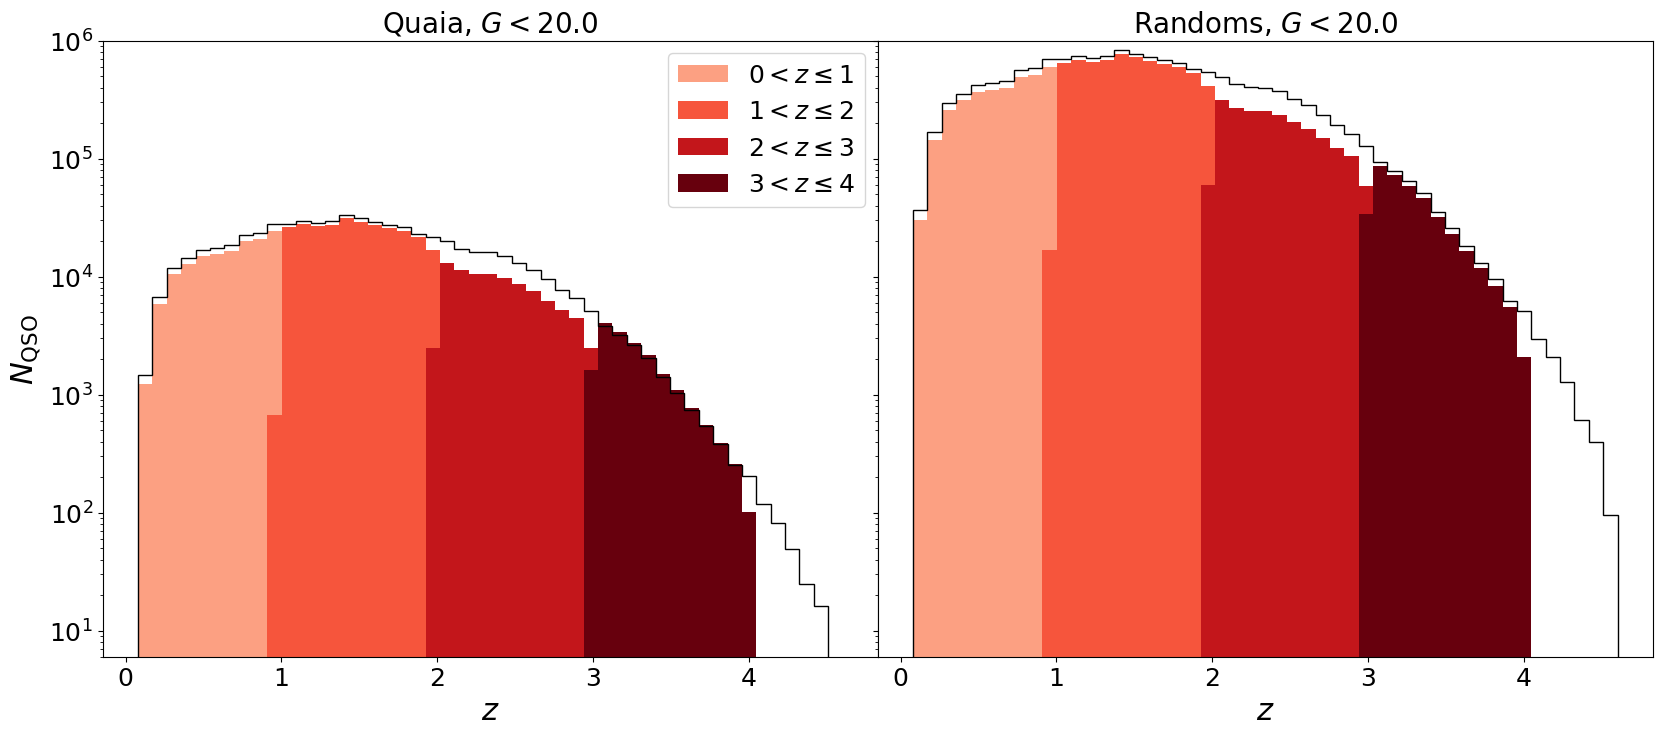

_G20.5_zmin0.0zmax1.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.5_zmin1.0zmax2.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.5_zmin2.0zmax3.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.5_zmin3.0zmax4.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


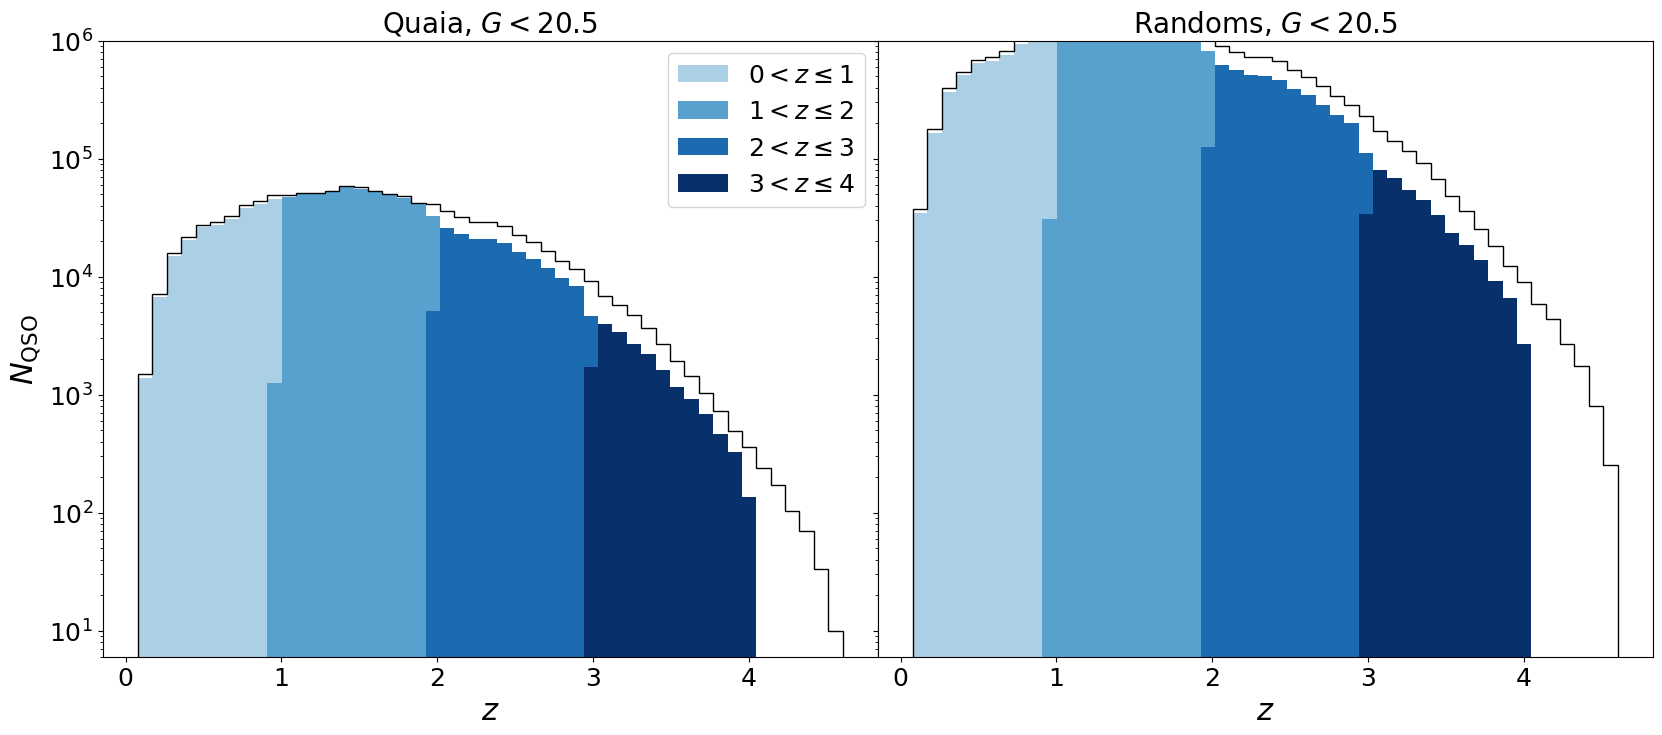

In [15]:
# plot data
bins = np.linspace(0.08, 4.6)
cf = {20.0: [], 20.5: []}
fac_rand = 25
for G, cmap in zip(G_array, cmaps):

    fn_selhi = '../data/maps/selection_function_NSIDE64_G{}.fits'.format(G)
    selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

    fn_datahi = '../data/quaia_G{}.fits'.format(G)
    tab_datahi = Table.read(fn_datahi)
    pixel_indices_datahi = hp.ang2pix(NSIDE, tab_datahi['ra'], tab_datahi['dec'], lonlat=True)
    mask_datahi = selfunc_hi[pixel_indices_datahi]>=0.5

    # plot!
    fig = plt.figure(figsize = (20, 8))
    gs = gridspec.GridSpec(1, 2, wspace = 0)

    ax1 = fig.add_subplot(gs[0])
    ax1.hist(tab_datahi['redshift_quaia'][mask_datahi], bins=bins, histtype = 'step', color='black')

    # plot randoms  
    ax2 = fig.add_subplot(gs[1])

    # for comparison purposes
    fn_randhi = '../data/randoms/random_G{}_{}x.fits'.format(G, fac_rand)
    tab_randhi = Table.read(fn_randhi)
    pixel_indices_randhi = hp.ang2pix(NSIDE, tab_randhi['ra'], tab_randhi['dec'], lonlat=True)
    mask_randhi = selfunc_hi[pixel_indices_randhi]>=0.5
    N_randhi_mask = len(tab_randhi['ra'][mask_randhi])
    N_datahi_mask = len(tab_datahi['ra'][mask_datahi])
    quaia.z_dist(tab_datahi, tab_randhi, mask_datahi, mask_randhi, N_datahi_mask, N_randhi_mask, mask_type = mask_type)
    ax2.hist(tab_randhi['redshift_quaia_'+mask_type], histtype = 'step', bins = bins, 
             color = 'black')

    for zbin in zbin_array[:-1]:
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _ = quaia.make_bins(G, int(zbin),True, 'z', bins = zbin_array, 
                                                                                           tab_gcat_type = 'data', method = 'minmax', 
                                                                                        fac_rand = fac_rand)
        ax1.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1), 
                 bins = bins, color = cmap[int(zbin)])
        ax2.hist(tab_randhi_mask_zbin0['redshift_quaia_{}'.format(key_zbin0)], label = 'bin{}'.format(zbin),
                 bins = bins, color = cmap[int(zbin)])
        
        cf[G].append(quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, rbins = rbins))

    ax1.set_xlabel('$z$')
    ax1.set_ylabel('$N_\mathrm{QSO}$')
    ax1.set_yscale('log')
    ax1.set_ylim(6,1e6)
    ax1.set_title('Quaia, $G<{}$'.format(G))
    ax1.legend()

    ax2.set_xlabel('$z$')
    ax2.set_yscale('log')
    ax2.set_ylim(6,1e6)
    ax2.set_title('Randoms, $G<{}$'.format(G))
    ax2.set_yticklabels([])
    plt.show()

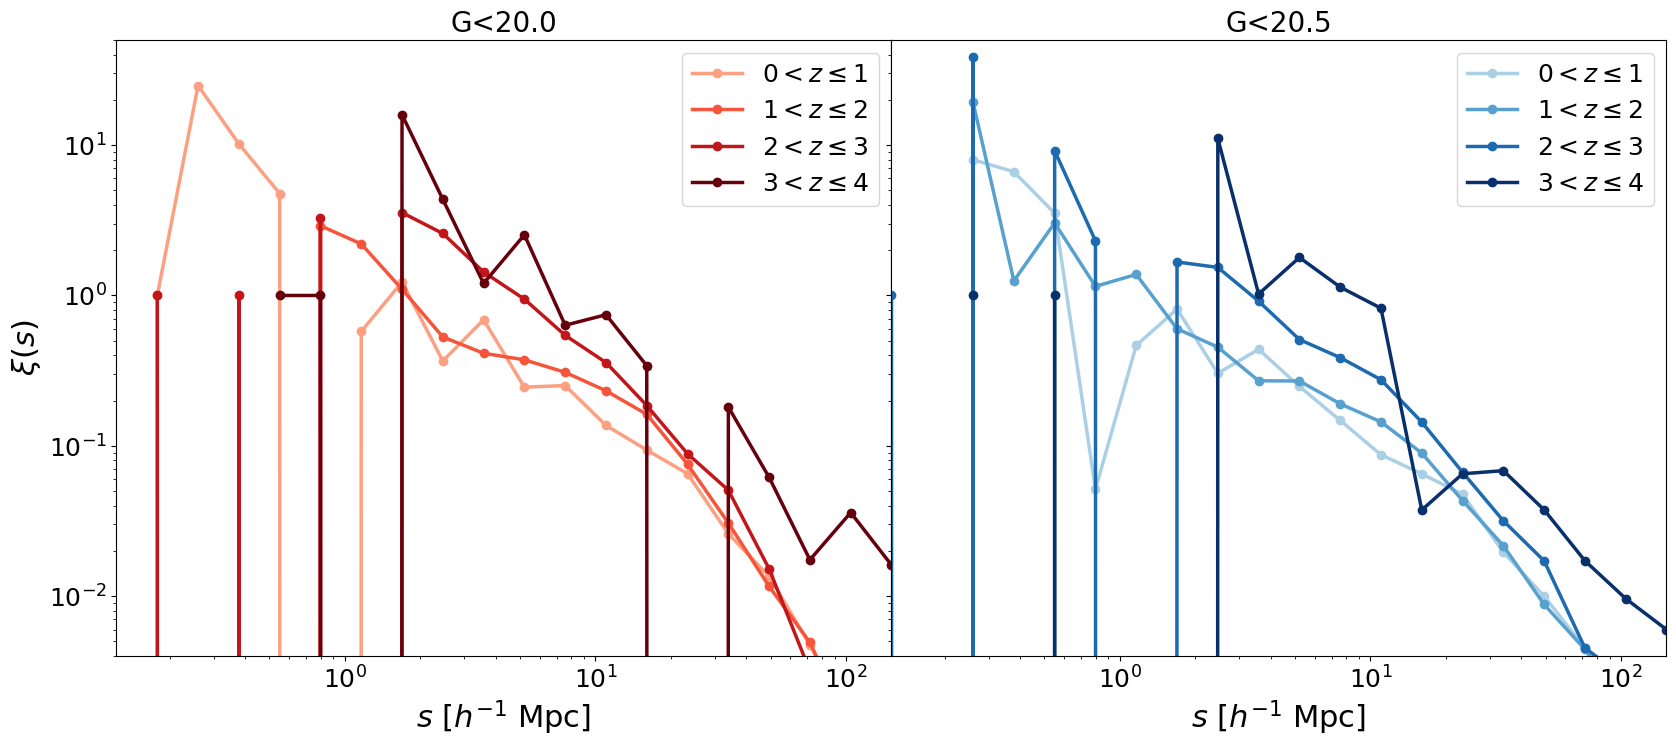

In [16]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

# G_array = [20.0, 20.5]
for i in range(len(G_array)):
# i = 0
    ax1 = fig.add_subplot(gs[i])
    for zbin in zbin_array[:-1]:
        ax1.plot(quaia.recenter(rbins), cf[G_array[i]][int(zbin)], marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1), 
                 linewidth = 2.5, color = cmaps[i][int(zbin)])
        ax1.set_title('G<{}'.format(G_array[i]))
        ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(4e-3, 5e1)
        ax1.legend()
        if i==0:
            ax1.set_ylabel(r"$\xi(s)$")
        else:
            ax1.set_yticklabels([])

plt.show()

### All sky

_G20.0_zmin0.0zmax1.0
weighting DR
weighting DD


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.0_zmin1.0zmax2.0
weighting DR
weighting DD


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.0_zmin2.0zmax3.0
weighting DR
weighting DD


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.0_zmin3.0zmax4.0
weighting DR
weighting DD


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


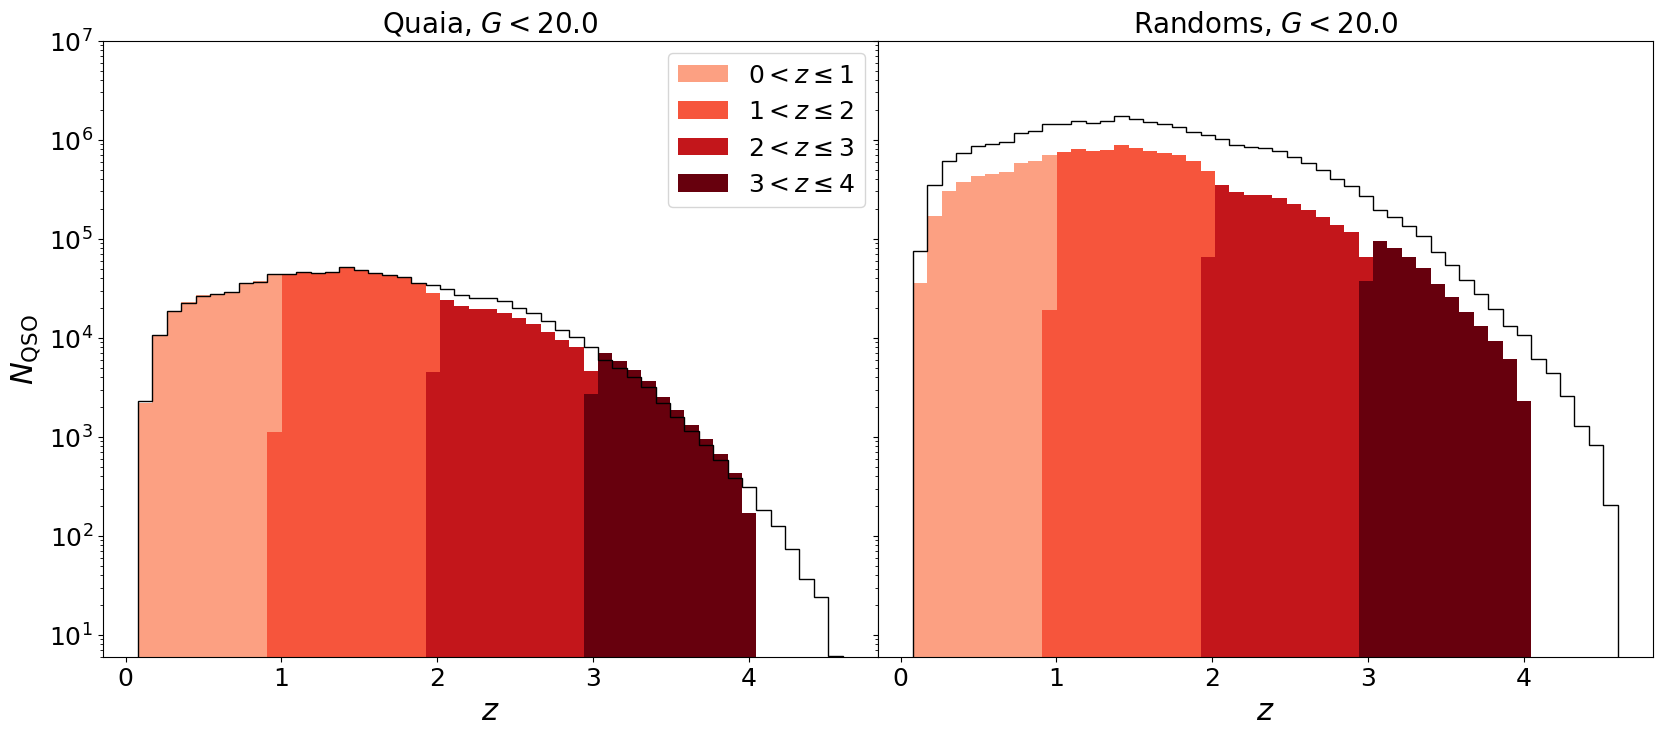

_G20.5_zmin0.0zmax1.0
weighting DR
weighting DD


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.5_zmin1.0zmax2.0
weighting DR
weighting DD


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.5_zmin2.0zmax3.0
weighting DR
weighting DD


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.5_zmin3.0zmax4.0
weighting DR
weighting DD


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


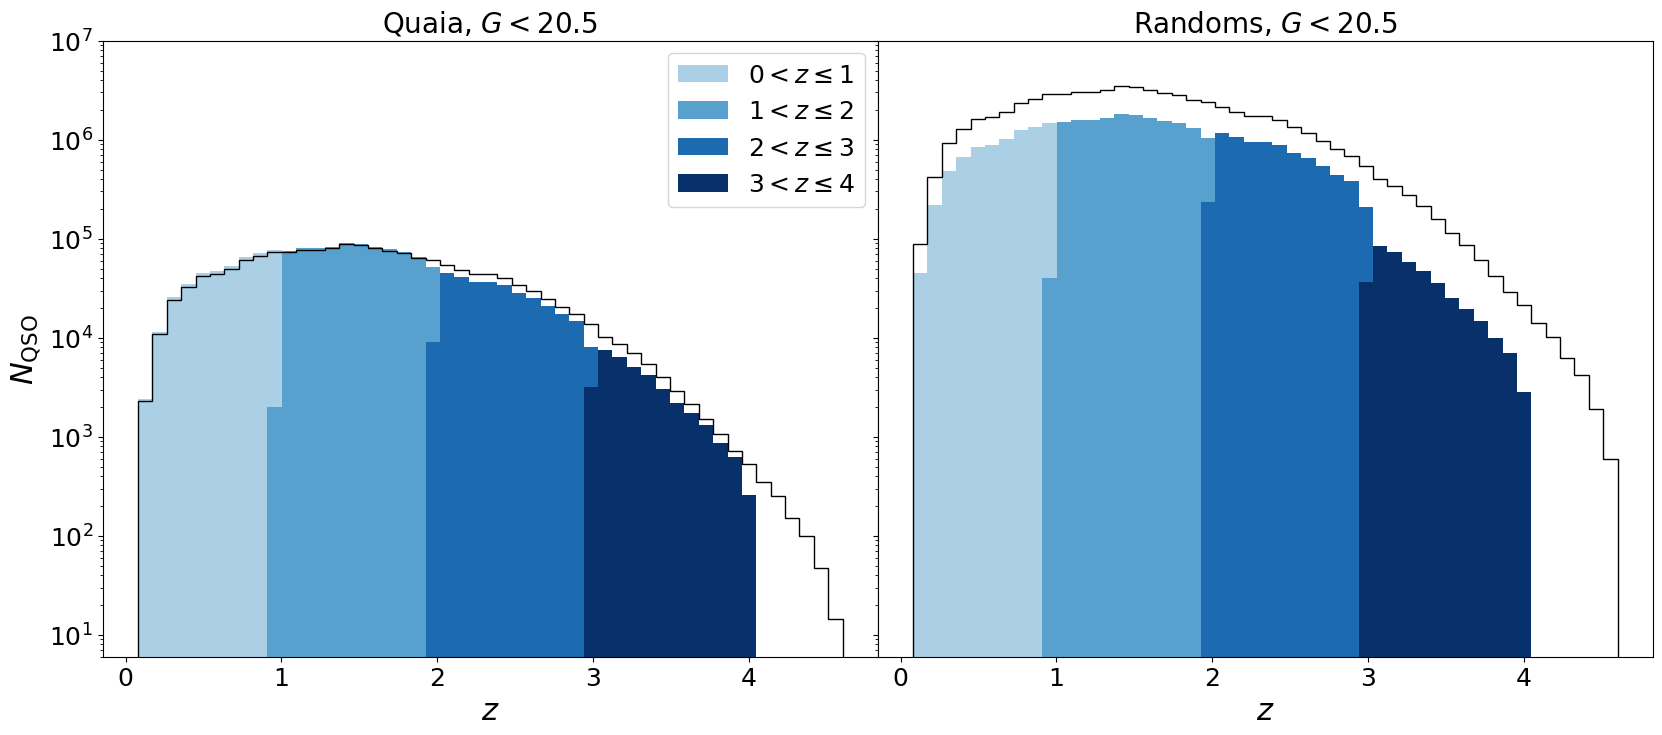

In [17]:
# plot data
bins = np.linspace(0.08, 4.6)
cf_allsky = {20.0: [], 20.5: []}
for G, cmap in zip(G_array, cmaps):

    fn_selhi = '../data/maps/selection_function_NSIDE64_G{}.fits'.format(G)
    selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

    fn_datahi = '../data/quaia_G{}.fits'.format(G)
    tab_datahi = Table.read(fn_datahi)
    pixel_indices_datahi = hp.ang2pix(NSIDE, tab_datahi['ra'], tab_datahi['dec'], lonlat=True)
    mask_datahi = selfunc_hi[pixel_indices_datahi]>=0.5

    # plot!
    fig = plt.figure(figsize = (20, 8))
    gs = gridspec.GridSpec(1, 2, wspace = 0)

    ax1 = fig.add_subplot(gs[0])
    ax1.hist(tab_datahi['redshift_quaia'][mask_datahi], bins=bins, histtype = 'step', color='black', 
             weights = 1/selfunc_hi[pixel_indices_datahi][mask_datahi])

    # plot randoms  
    ax2 = fig.add_subplot(gs[1])

    # for comparison purposes
    fn_randhi = '../data/randoms/random_G{}_allsky_{}x.fits'.format(G, fac_rand)
    tab_randhi = Table.read(fn_randhi)
    # pixel_indices_randhi = hp.ang2pix(NSIDE, tab_randhi['ra'], tab_randhi['dec'], lonlat=True)
    # mask_randhi = selfunc_hi[pixel_indices_randhi]>=0.5
    # N_randhi_mask = len(tab_randhi['ra'][mask_randhi])
    N_randhi = len(tab_randhi['ra'])
    N_datahi_mask = len(tab_datahi['ra'][mask_datahi])
    quaia.z_dist(tab_datahi, tab_randhi, mask_datahi, np.full(N_randhi, True), N_datahi_mask, N_randhi, mask_type = mask_type)
    ax2.hist(tab_randhi['redshift_quaia_'+mask_type], histtype = 'step', bins = bins,
             color = 'black')

    for zbin in zbin_array[:-1]:
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, weights1 = quaia.make_bins(G, int(zbin),True, 'z', bins = zbin_array,
                                                                                               tab_gcat_type = 'data', method = 'minmax', 
                                                                                               allsky = '_allsky', fac_rand = fac_rand)
        ax1.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1), 
                 bins = bins, color = cmap[int(zbin)], weights = weights1)
        ax2.hist(tab_randhi_mask_zbin0['redshift_quaia_{}'.format(key_zbin0)], label = 'bin{}'.format(zbin),
                 bins = bins, color = cmap[int(zbin)])
        
        cf_allsky[G].append(quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, rbins = rbins, 
                                       weights1 = weights1))

    ax1.set_xlabel('$z$')
    ax1.set_ylabel('$N_\mathrm{QSO}$')
    ax1.set_yscale('log')
    ax1.set_ylim(6,1e7)
    ax1.set_title('Quaia, $G<{}$'.format(G))
    ax1.legend()

    ax2.set_xlabel('$z$')
    ax2.set_yscale('log')
    ax2.set_ylim(6,1e7)
    ax2.set_title('Randoms, $G<{}$'.format(G))
    ax2.set_yticklabels([])
    plt.show()

In [18]:
hist, bin_edges = np.histogram(tab_datahi['redshift_quaia'][mask_datahi], bins=bins, weights = 1/selfunc_hi[pixel_indices_datahi][mask_datahi])

In [19]:
len(tab_randhi['redshift_quaia_'+mask_type])/np.sum(hist)

39.304629510332035

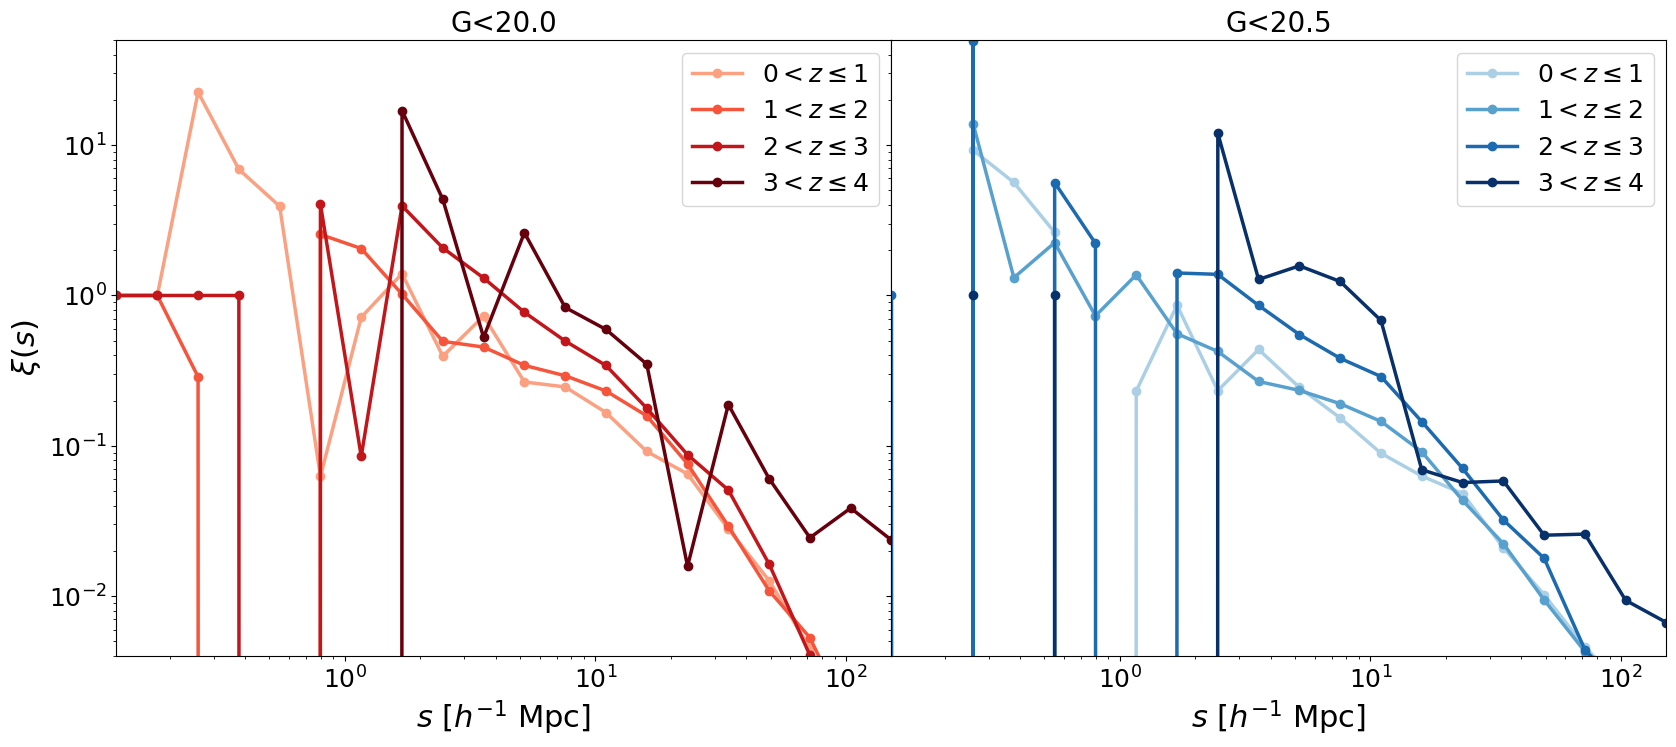

In [20]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

# G_array = [20.0, 20.5]
for i in range(len(G_array)):
# i = 0
    ax1 = fig.add_subplot(gs[i])
    for zbin in zbin_array[:-1]:
        ax1.plot(quaia.recenter(rbins), cf_allsky[G_array[i]][int(zbin)], marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1), 
                 linewidth = 2.5, color = cmaps[i][int(zbin)])
        ax1.set_title('G<{}'.format(G_array[i]))
        ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(4e-3, 5e1)
        ax1.legend()
        if i==0:
            ax1.set_ylabel(r"$\xi(s)$")
        else:
            ax1.set_yticklabels([])

plt.show()

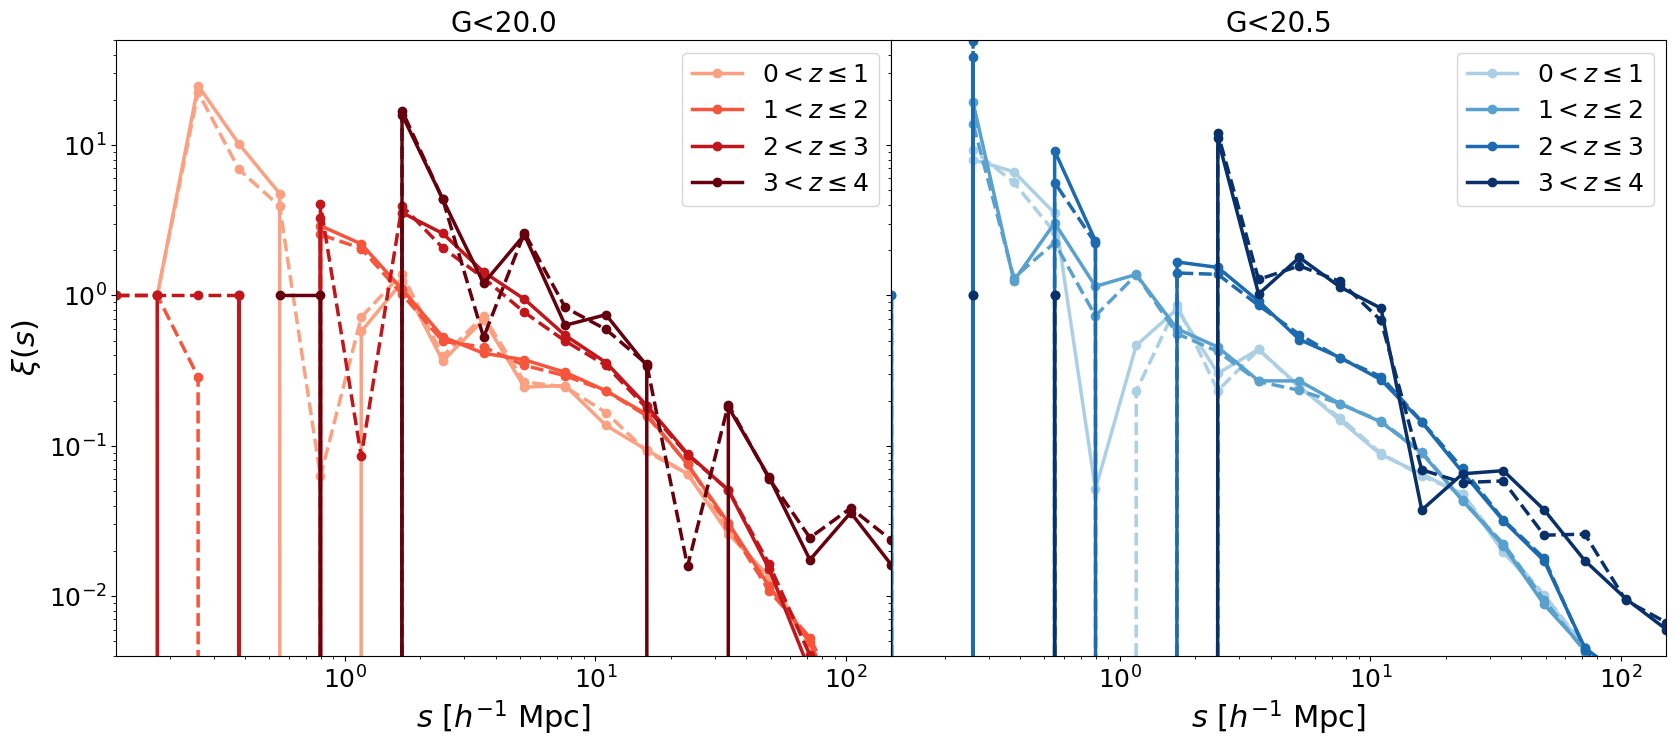

In [21]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

# G_array = [20.0, 20.5]
for i in range(len(G_array)):
# i = 0
    ax1 = fig.add_subplot(gs[i])
    for zbin in zbin_array[:-1]:
        ax1.plot(quaia.recenter(rbins), cf[G_array[i]][int(zbin)], marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1), 
                 linewidth = 2.5, color = cmaps[i][int(zbin)])
        ax1.plot(quaia.recenter(rbins), cf_allsky[G_array[i]][int(zbin)], marker = 'o', 
                 linewidth = 2.5, color = cmaps[i][int(zbin)], linestyle = '--')
        ax1.set_title('G<{}'.format(G_array[i]))
        ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(4e-3, 5e1)
        ax1.legend()
        if i==0:
            ax1.set_ylabel(r"$\xi(s)$")
        else:
            ax1.set_yticklabels([])

plt.show()

Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
Number of data sources: 18891763
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 32261520
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>
weighting DR
weighting DD


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 1295502
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
Number of data sources: 32399722
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 65027536
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>
weighting DR
weighting DD


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


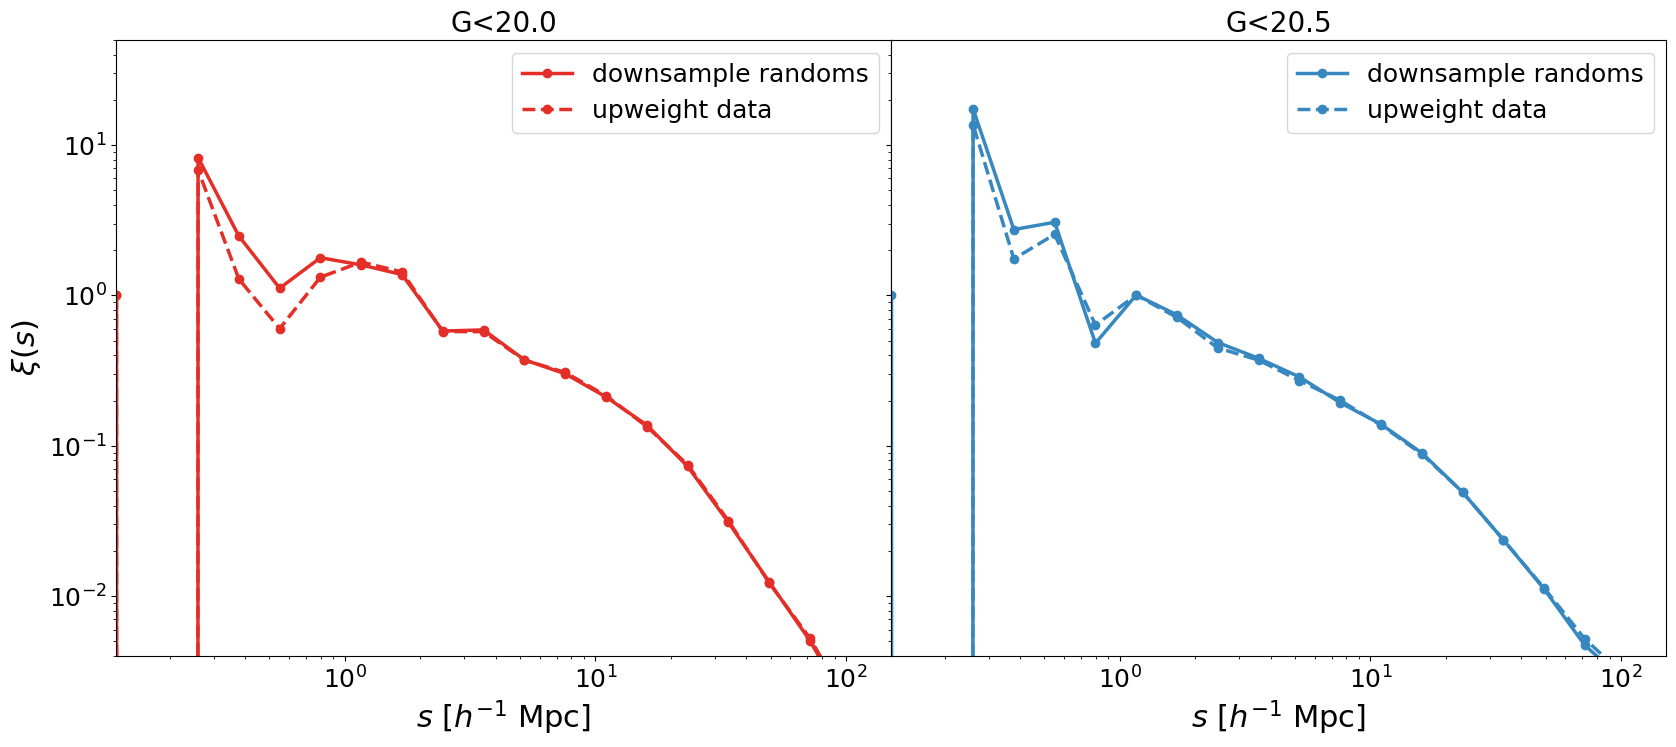

In [22]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)
    
cf_test = {G_lo: [], G_hi: []}
cf_test_allsky = {G_lo: [], G_hi: []}
for G, ax, color in zip(G_array, gs, colors):
    
    ax1 = fig.add_subplot(ax)

    # for comparison purposes
    # fn_randhi = '../data/randoms/random_G{}_allsky_10x.fits'.format(G)
    # tab_randhi = Table.read(fn_randhi)
    # pixel_indices_randhi = hp.ang2pix(NSIDE, tab_randhi['ra'], tab_randhi['dec'], lonlat=True)
    
    fn_selhi = '../data/maps/selection_function_NSIDE64_G{}.fits'.format(G)
    selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

    # mask_randhi = selfunc_hi[pixel_indices_randhi]>=0.5    
    # N_randhi_mask = len(tab_randhi['ra'][mask_randhi])
    # N_datahi_mask = len(tab_datahi['ra'][mask_datahi])
    
    tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read('../data/quaia_G{}.fits'.format(G), G, fn_selhi, 
                                                                                   mask_type = mask_type)

    # regular method
    tab_randhi, pixel_indices_randhi_mask, N_randhi_mask, mask_randhi = quaia.read('../data/randoms/random_G{}_{}x.fits'.format(G, fac_rand), G, 
                                                                                   fn_selhi, mask_type = mask_type)
    key = quaia.z_dist(tab_datahi, tab_randhi, mask_datahi, mask_randhi, N_datahi_mask, N_randhi_mask, mask_type = mask_type)
    cf_test[G] = quaia.xi_s(tab_datahi[mask_datahi], tab_randhi[mask_randhi], key, nthreads = nthreads, rbins = rbins)
    ax1.plot(quaia.recenter(rbins), cf_test[G], marker = 'o', label = 'downsample randoms', 
                 linewidth = 2.5, color = color)
    
    # upweighted method
    # N_randhi = len(tab_randhi['ra'])
    # _, pixel_indices_datahi, N_datahi, _ = quaia.read('../data/quaia_G{}.fits'.format(G), G, fn_selhi)
    (tab_randhi_allsky, pixel_indices_randhi_mask_allsky, N_randhi_mask_allsky, 
     mask_randhi_allsky) = quaia.read('../data/randoms/random_G{}_allsky_{}x.fits'.format(G, fac_rand), G, fn_selhi, mask_type = mask_type)
    key_allsky = quaia.z_dist(tab_datahi, tab_randhi_allsky,  mask_datahi, mask_randhi_allsky, N_datahi_mask, N_randhi_mask_allsky, 
                              mask_type = 'allsky')
    cf_test_allsky[G] = quaia.xi_s(tab_datahi[mask_datahi], tab_randhi_allsky[mask_randhi_allsky], key_allsky, nthreads = nthreads, rbins = rbins, 
                                weights1 = 1/selfunc_hi[pixel_indices_datahi_mask])  
    ax1.plot(quaia.recenter(rbins), cf_test_allsky[G], marker = 'o', label = 'upweight data', 
                 linewidth = 2.5, color = color, linestyle = '--')
    
    ax1.set_title('G<{}'.format(G))
    ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(4e-3, 5e1)
    ax1.legend()
    if G==G_lo:
        ax1.set_ylabel(r"$\xi(s)$")
    else:
        ax1.set_yticklabels([])

plt.show()

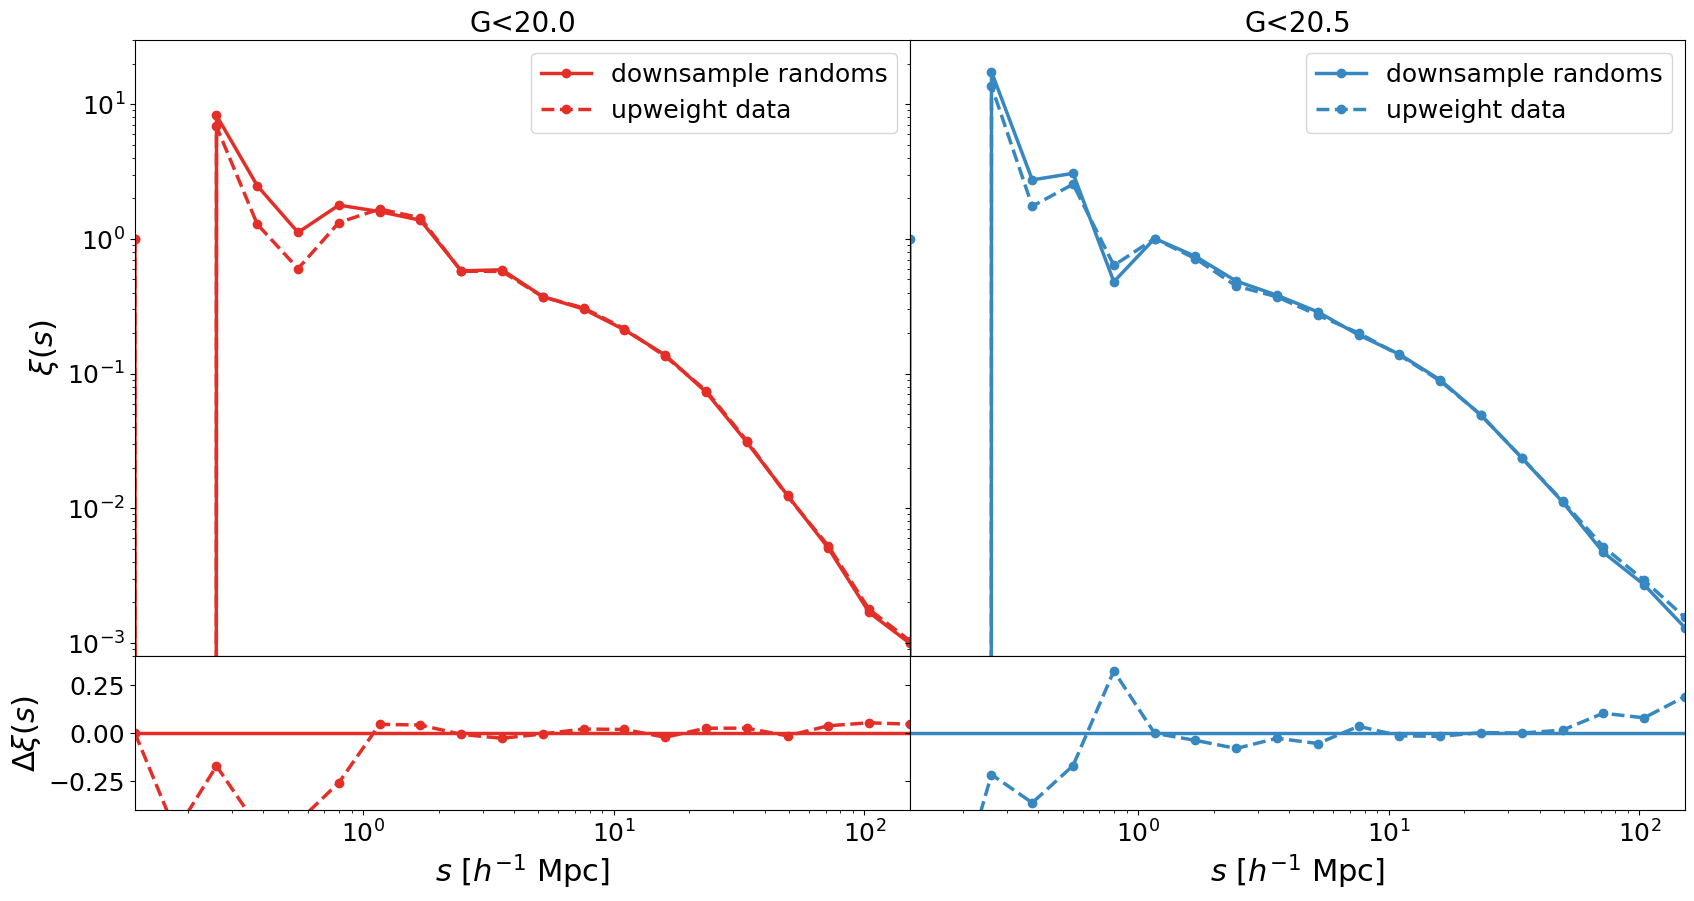

In [23]:
# plot!
fig = plt.figure(figsize = (20, 10))
gs = gridspec.GridSpec(2, 2, wspace = 0, height_ratios = [4,1], hspace = 0)

for i in range(len(colors)):
    
    ax1 = fig.add_subplot(gs[i])
    
#     fn_selhi = '../data/maps/selection_function_NSIDE64_G{}.fits'.format(G_array[i])
#     selfunc_hi = hp.fitsfunc.read_map(fn_selhi)
    
#     tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read('../data/quaia_G{}.fits'.format(G_array[i]), G_array[i], fn_selhi, 
#                                                                                    mask_type = mask_type)

#     # regular method
#     tab_randhi, pixel_indices_randhi_mask, N_randhi_mask, mask_randhi = quaia.read('../data/randoms/random_G{}_10x.fits'.format(G_array[i]), 
#                                                                                    G_array[i], fn_selhi, mask_type = mask_type)
#     key = quaia.z_dist(tab_datahi, tab_randhi, mask_datahi, mask_randhi, N_datahi_mask, N_randhi_mask, mask_type = mask_type)
#     cf_test = quaia.xi_s(tab_datahi[mask_datahi], tab_randhi[mask_randhi], key, nthreads = nthreads, rbins = rbins)
    ax1.plot(quaia.recenter(rbins), cf_test[G_array[i]], marker = 'o', label = 'downsample randoms', 
                 linewidth = 2.5, color = colors[i])
    
    # upweighted method
    # (tab_randhi_allsky, pixel_indices_randhi_mask_allsky, N_randhi_mask_allsky, 
    #  mask_randhi_allsky) = quaia.read('../data/randoms/random_G{}_allsky_10x.fits'.format(G_array[i]), G_array[i], fn_selhi, mask_type = mask_type)
    # key_allsky = quaia.z_dist(tab_datahi, tab_randhi_allsky,  mask_datahi, mask_randhi_allsky, N_datahi_mask, N_randhi_mask_allsky, 
    #                           mask_type = 'allsky')
    # cf_test_allsky = quaia.xi_s(tab_datahi[mask_datahi], tab_randhi_allsky[mask_randhi_allsky], key_allsky, nthreads = nthreads, rbins = rbins, 
    #                             weights1 = 1/selfunc_hi[pixel_indices_datahi_mask])  
    ax1.plot(quaia.recenter(rbins), cf_test_allsky[G_array[i]], marker = 'o', label = 'upweight data', 
                 linewidth = 2.5, color = colors[i], linestyle = '--')
    
    ax1.set_title('G<{}'.format(G_array[i]))
    # ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    ax1.set_xticklabels([])
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(8e-4, 3e1)
    ax1.legend()
        
    ax2 = fig.add_subplot(gs[i+2])
    
    ax2.axhline(0, linewidth = 2.5, color = colors[i])
    ax2.plot(quaia.recenter(rbins), (cf_test_allsky[G_array[i]]-cf_test[G_array[i]])/cf_test[G_array[i]], marker = 'o', label = 'upweight data', 
                 linewidth = 2.5, color = colors[i], linestyle = '--')
    ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(-0.4, 0.4)
    
    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')
    
    if i == 0:
        ax1.set_ylabel(r"$\xi(s)$")
        ax2.set_ylabel(r"$\Delta\xi(s)$")
    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

plt.show()

# Understand facrand
## $\xi(s)$

Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
Number of data sources: 7563151
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 12904608
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>
weighting DR
weighting DD


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 1295502
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
Number of data sources: 12955802
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>


...

/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 1295502
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
Number of data sources: 129616435
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


weighting DR
weighting DD


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


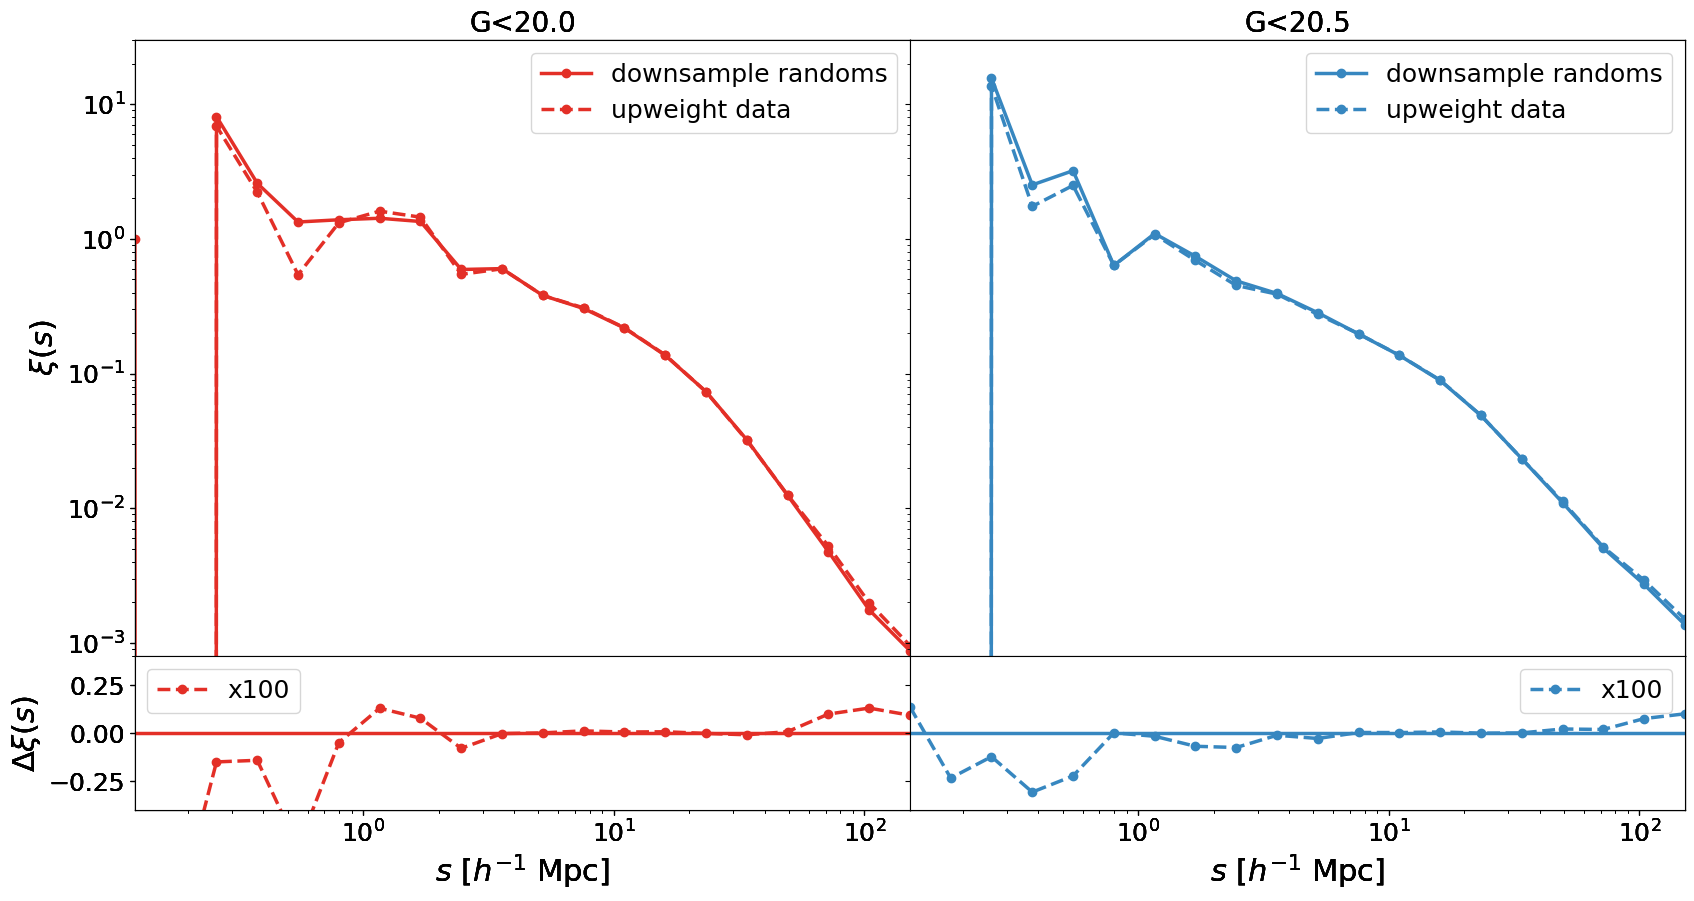

In [68]:
# plot!
# fig = plt.figure(figsize = (20, 10))
# gs = gridspec.GridSpec(2, 2, wspace = 0, height_ratios = [4,1], hspace = 0)

cf_test = {G_lo: [], G_hi: []}
cf_test_allsky = {G_lo: [], G_hi: []}
facrand = [10, 25, 50, 100]
for j in range(len(facrand)):
    
    for i in range(len(colors)):

        # ax1 = fig.add_subplot(gs[i])

        fn_selhi = '../data/maps/selection_function_NSIDE64_G{}.fits'.format(G_array[i])
        selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

        tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read('../data/quaia_G{}.fits'.format(G_array[i]), G_array[i], 
                                                                                       fn_selhi, mask_type = mask_type)

        # regular method
        tab_randhi, pixel_indices_randhi_mask, N_randhi_mask, mask_randhi = quaia.read('../data/randoms/random_G{}_{}x.fits'.format(G_array[i], 
                                                                                                                                    facrand[j]), 
                                                                                       G_array[i], fn_selhi, mask_type = mask_type)
        key = quaia.z_dist(tab_datahi, tab_randhi, mask_datahi, mask_randhi, N_datahi_mask, N_randhi_mask, mask_type = mask_type)
        cf_test[G_array[i]].append(quaia.xi_s(tab_datahi[mask_datahi], tab_randhi[mask_randhi], key, nthreads = nthreads, rbins = rbins))
        # ax1.plot(quaia.recenter(rbins), cf_test[G_array[i]][j], marker = 'o', label = 'downsample randoms', 
        #              linewidth = 2.5, color = colors[i])

        # upweighted method
        (tab_randhi_allsky, pixel_indices_randhi_mask_allsky, N_randhi_mask_allsky, 
         mask_randhi_allsky) = quaia.read('../data/randoms/random_G{}_allsky_{}x.fits'.format(G_array[i], facrand[j]), G_array[i], fn_selhi, 
                                          mask_type = mask_type)
        key_allsky = quaia.z_dist(tab_datahi, tab_randhi_allsky,  mask_datahi, mask_randhi_allsky, N_datahi_mask, N_randhi_mask_allsky, 
                                  mask_type = 'allsky')
        cf_test_allsky[G_array[i]].append(quaia.xi_s(tab_datahi[mask_datahi], tab_randhi_allsky[mask_randhi_allsky], key_allsky, nthreads = nthreads,
                                          rbins = rbins, weights1 = 1/selfunc_hi[pixel_indices_datahi_mask]))
#         ax1.plot(quaia.recenter(rbins), cf_test_allsky[G_array[i]][j], marker = 'o', label = 'upweight data', 
#                      linewidth = 2.5, color = colors[i], linestyle = '--')

#         ax1.set_title('G<{}'.format(G_array[i]))
#         # ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
#         ax1.set_xticklabels([])
#         ax1.set_yscale('log')
#         ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
#         ax1.set_ylim(8e-4, 3e1)
#         ax1.legend()

#         ax2 = fig.add_subplot(gs[i+2])

#         ax2.axhline(0, linewidth = 2.5, color = colors[i])
#         ax2.plot(quaia.recenter(rbins), (cf_test_allsky[G_array[i]][j]-cf_test[G_array[i]][j])/cf_test[G_array[i]][j], marker = 'o', 
#                  label = 'x{}'.format(facrand[j]), linewidth = 2.5, color = colors[i], linestyle = '--')
#         ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
#         ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
#         ax2.set_ylim(-0.4, 0.4)
#         ax2.legend()

#         if scale == 'log':
#             ax1.set_xscale('log')
#             ax2.set_xscale('log')

#         if i == 0:
#             ax1.set_ylabel(r"$\xi(s)$")
#             ax2.set_ylabel(r"$\Delta\xi(s)$")
#         else:
#             ax1.set_yticklabels([])
#             ax2.set_yticklabels([])

# plt.show()

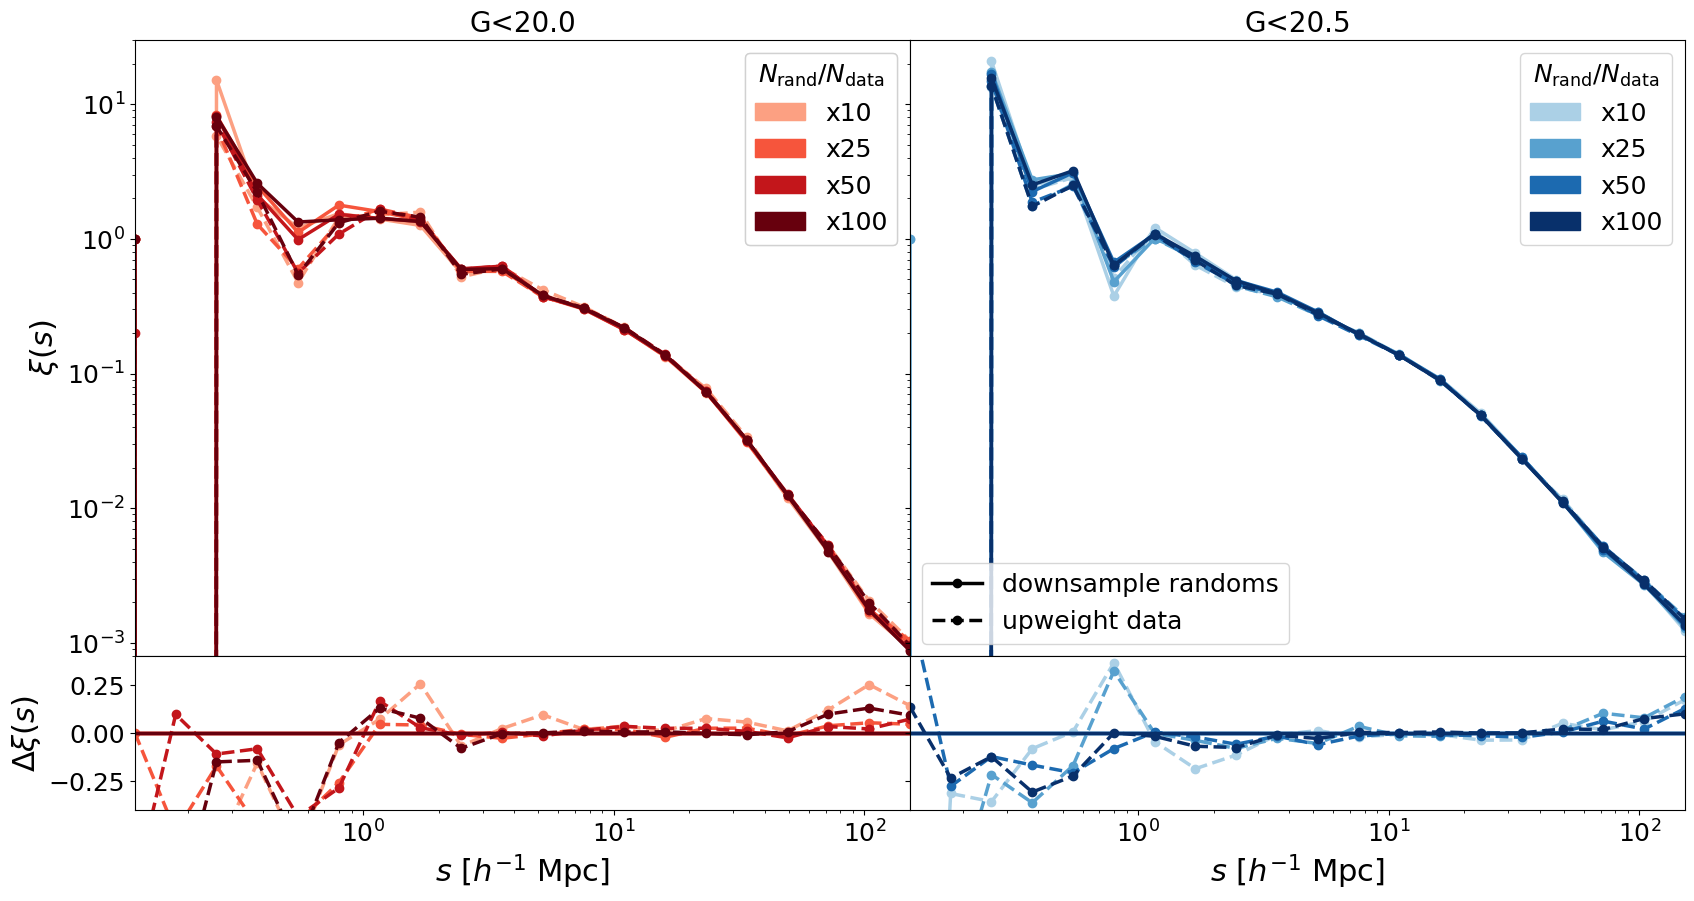

In [111]:
# plot!
fig = plt.figure(figsize = (20, 10))
gs = gridspec.GridSpec(2, 2, wspace = 0, height_ratios = [4,1], hspace = 0)

# cf_test = {G_lo: [], G_hi: []}
# cf_test_allsky = {G_lo: [], G_hi: []}
# facrand = [10, 25, 50, 100]
    
for i in range(len(colors)):

    ax1 = fig.add_subplot(gs[i])
    ax2 = fig.add_subplot(gs[i+2])
    
    for j in range(len(facrand)):

#         fn_selhi = '../data/maps/selection_function_NSIDE64_G{}.fits'.format(G_array[i])
#         selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

#         tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read('../data/quaia_G{}.fits'.format(G_array[i]), G_array[i], 
#                                                                                        fn_selhi, mask_type = mask_type)

#         # regular method
#         tab_randhi, pixel_indices_randhi_mask, N_randhi_mask, mask_randhi = quaia.read('../data/randoms/random_G{}_{}x.fits'.format(G_array[i], 
#                                                                                                                                     facrand[j]), 
#                                                                                        G_array[i], fn_selhi, mask_type = mask_type)
#         key = quaia.z_dist(tab_datahi, tab_randhi, mask_datahi, mask_randhi, N_datahi_mask, N_randhi_mask, mask_type = mask_type)
#         cf_test[G_array[i]].append(quaia.xi_s(tab_datahi[mask_datahi], tab_randhi[mask_randhi], key, nthreads = nthreads, rbins = rbins))
        ax1.plot(quaia.recenter(rbins), cf_test[G_array[i]][j], marker = 'o', label = 'downsample randoms', 
                     linewidth = 2.5, color = cmaps[i][j])

        # upweighted method
        # (tab_randhi_allsky, pixel_indices_randhi_mask_allsky, N_randhi_mask_allsky, 
        #  mask_randhi_allsky) = quaia.read('../data/randoms/random_G{}_allsky_{}x.fits'.format(G_array[i], facrand[j]), G_array[i], fn_selhi, 
        #                                   mask_type = mask_type)
        # key_allsky = quaia.z_dist(tab_datahi, tab_randhi_allsky,  mask_datahi, mask_randhi_allsky, N_datahi_mask, N_randhi_mask_allsky, 
        #                           mask_type = 'allsky')
        # cf_test_allsky[G_array[i]].append(quaia.xi_s(tab_datahi[mask_datahi], tab_randhi_allsky[mask_randhi_allsky], key_allsky, nthreads = nthreads,
        #                                   rbins = rbins, weights1 = 1/selfunc_hi[pixel_indices_datahi_mask]))
        ax1.plot(quaia.recenter(rbins), cf_test_allsky[G_array[i]][j], marker = 'o', label = 'upweight data', 
                     linewidth = 2.5, color = cmaps[i][j], linestyle = '--')

        ax1.set_title('G<{}'.format(G_array[i]))
        # ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        ax1.set_xticklabels([])
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(8e-4, 3e1)
        # ax1.legend()

        # print('x{}'.format(facrand[j]))
        # print('../data/randoms/random_G{}_allsky_{}x.fits'.format(G_array[i], facrand[j]))
        ax2.axhline(0, linewidth = 2.5,color = cmaps[i][j])
        # j=0
        ax2.plot(quaia.recenter(rbins), (cf_test_allsky[G_array[i]][j]-cf_test[G_array[i]][j])/cf_test[G_array[i]][j], marker = 'o', 
                 label = 'x{}'.format(facrand[j]), linewidth = 2.5, color = cmaps[i][j], linestyle = '--')
        ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax2.set_ylim(-0.4, 0.4)
        # ax2.legend()

        if scale == 'log':
            ax1.set_xscale('log')
            ax2.set_xscale('log')

        if i == 0:
            ax1.set_ylabel(r"$\xi(s)$")
            ax2.set_ylabel(r"$\Delta\xi(s)$")
        else:
            ax1.set_yticklabels([])
            ax2.set_yticklabels([])
            
    patch = [mpatches.Patch(color=cmaps[i][k], label='x{}'.format(facrand[k])) for k in range(len(cmaps[i]))]
    first_legend = ax1.legend(handles=patch, loc = 'upper right', title = "$N_\mathrm{rand}/N_\mathrm{data}$", title_fontsize = 18)
    ax1.add_artist(first_legend)

custom_lines = [Line2D([0], [0], color = 'black', linewidth = 2.5, linestyle = '-', marker = 'o'), 
                Line2D([0], [0], color = 'black', linewidth = 2.5, linestyle = '--', marker = 'o')]
ax1.legend(custom_lines, ['downsample randoms', 'upweight data'], loc = 'lower left')

plt.show()

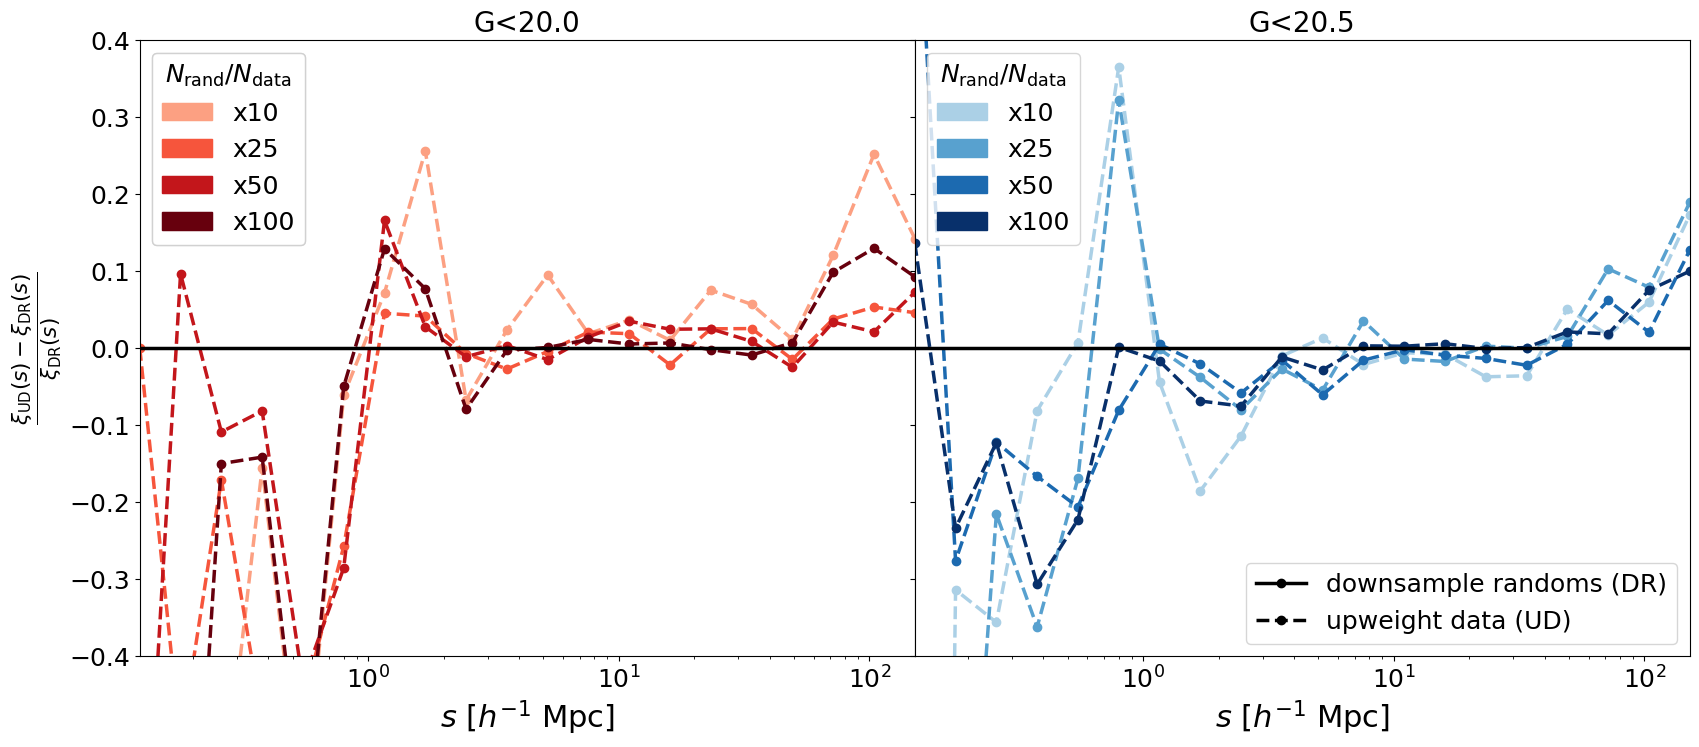

In [118]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

for i in range(len(colors)):

    ax1 = fig.add_subplot(gs[i])
    
    for j in range(len(facrand)):

#         # regular method
#         ax1.plot(quaia.recenter(rbins), cf_test[G_array[i]][j], marker = 'o', label = 'downsample randoms', 
#                      linewidth = 2.5, color = colors[i])

#         # upweighted method
#         ax1.plot(quaia.recenter(rbins), cf_test_allsky[G_array[i]][j], marker = 'o', label = 'upweight data', 
#                      linewidth = 2.5, color = cmaps[i][j], linestyle = '--')

        
#         ax1.set_xticklabels([])
#         ax1.set_yscale('log')
#         ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
#         ax1.set_ylim(8e-4, 3e1)

        ax1.plot(quaia.recenter(rbins), (cf_test_allsky[G_array[i]][j]-cf_test[G_array[i]][j])/cf_test[G_array[i]][j], marker = 'o', 
                 label = 'x{}'.format(facrand[j]), linewidth = 2.5, color = cmaps[i][j], linestyle = '--')
    
    ax1.set_title('G<{}'.format(G_array[i]))    
    ax1.axhline(0, linewidth = 2.5,color = 'black')
    ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(-0.4, 0.4)

    if scale == 'log':
        ax1.set_xscale('log')
        # ax2.set_xscale('log')

    if i == 0:
        # ax1.set_ylabel(r"$\xi(s)$")
        ax1.set_ylabel(r"$\frac{\xi_\mathrm{UD}(s)-\xi_\mathrm{DR}(s)}{\xi_\mathrm{DR}(s)}$")
    else:
        ax1.set_yticklabels([])
        # ax2.set_yticklabels([])

    patch = [mpatches.Patch(color=cmaps[i][k], label='x{}'.format(facrand[k])) for k in range(len(cmaps[i]))]
    first_legend = ax1.legend(handles=patch, loc = 'upper left', title = "$N_\mathrm{rand}/N_\mathrm{data}$", title_fontsize = 18)
    ax1.add_artist(first_legend)
    
custom_lines = [Line2D([0], [0], color = 'black', linewidth = 2.5, linestyle = '-', marker = 'o'), 
                Line2D([0], [0], color = 'black', linewidth = 2.5, linestyle = '--', marker = 'o')]
ax1.legend(custom_lines, ['downsample randoms (DR)', 'upweight data (UD)'], loc = 'lower right')

plt.show()

## $w_p(r_p)$

In [24]:
# Create the bins array
rmin = 0.15 # 0.5 # 0.1 # start higher
rmax = 240 # 120 #85 # 60.0 # 20.0 
nbins = 20 
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

# rmin = 0.15 # 0.5 # 0.1 # start higher
# rmax = 210 # 120 #85 # 60.0 # 20.0 
# nbins = 20 
# rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'lin'

In [25]:
pimax = 80 # 40 # 5000.0 # 40.0

In [26]:
i, j = 0, 0
facrand = [10, 25, 50, 100]
fn_selhi = '../data/maps/selection_function_NSIDE64_G{}.fits'.format(G_array[i])
selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read('../data/quaia_G{}.fits'.format(G_array[i]), G_array[i], 
                                                                               fn_selhi, mask_type = mask_type)
(tab_randhi_allsky, pixel_indices_randhi_mask_allsky, N_randhi_mask_allsky, 
 mask_randhi_allsky) = quaia.read('../data/randoms/random_G{}_allsky_{}x.fits'.format(G_array[i], facrand[j]), G_array[i], fn_selhi, 
                                  mask_type = mask_type)
key_allsky = quaia.z_dist(tab_datahi, tab_randhi_allsky, mask_datahi, mask_randhi_allsky, N_datahi_mask, N_randhi_mask_allsky, 
                          mask_type = 'allsky')
wp, rpavg = quaia.wp_rp(tab_datahi[mask_datahi], tab_randhi_allsky[mask_randhi_allsky], key_allsky, 
                                              nthreads = nthreads, rbins = rbins, nbins = nbins, pimax = pimax, 
                                              weights1 = 1/selfunc_hi[pixel_indices_datahi_mask])

Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
Number of data sources: 12904608
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>
weighting DR
weighting DD


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


In [27]:
wp, rpavg

(array([3.48447548e+02, 2.18432088e+02, 9.58356341e+01, 4.25496430e+01,
        6.15168368e+01, 5.50216102e+01, 3.99054195e+01, 3.22791364e+01,
        2.48970577e+01, 1.87548435e+01, 1.26208806e+01, 8.59538310e+00,
        6.70248659e+00, 3.79611294e+00, 1.96888727e+00, 1.11061274e+00,
        8.16654340e-01, 2.43845167e-01, 2.46593075e-01, 9.02236186e-02]),
 [0.18294441603581993,
  0.27549246199593963,
  0.3815667878118164,
  0.5645715830721538,
  0.8107962339690036,
  1.1658428509424326,
  1.692736090357049,
  2.4478762636181677,
  3.5410183955391106,
  5.121043389890555,
  7.411473654374754,
  10.715178753076122,
  15.503669263135302,
  22.42912942346271,
  32.43178413938517,
  46.922537008789284,
  67.83687500549978,
  98.10934971171048,
  141.86511474441,
  205.11735332526217])

In [28]:
tab_datahi[mask_datahi]

source_id,unwise_objid,redshift_quaia,redshift_quaia_err,ra,dec,l,b,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,mag_w1_vg,mag_w2_vg,pm,pmra,pmdec,pmra_error,pmdec_error
,,,,deg,deg,deg,deg,mag,mag,mag,mag,mag,mas / yr,mas / yr,mas / yr,mas / yr,mas / yr
int64,bytes16,float64,float64,float64,float64,float64,float64,float32,float32,float32,float64,float64,float64,float64,float64,float32,float32
10892037246720,0453p000o0015876,1.7364680767059326,0.09659415222167977,45.18857525358218,0.28242442525431893,176.85154355262011,-48.5708559360798,18.78724,19.080688,18.240915,15.21995,13.868094,0.15540553490476286,-0.09803741741546984,-0.12058003593273806,0.257395,0.22310686
15839839588736,0453p000o0017020,1.5130492448806763,0.0631867671012879,45.189480360571665,0.3591947400894022,176.76912910053676,-48.51684235773577,18.888464,19.17128,18.50937,15.317786,14.013617,0.44892476891575755,-0.31608849256513893,0.31878129338774636,0.36059502,0.3265819
22780506725760,0453p000o0016209,2.852853775024414,0.07664000000000004,44.79936522932521,0.30355729158111383,176.4176643816323,-48.83530904204095,19.218422,19.48634,18.8145,16.027142,15.041919,0.5232111830158942,0.16823689536016173,0.495425361757415,0.36143935,0.269473
29102698617216,0453p000o0018124,1.406,0.5532363144874572,45.07952191471843,0.43963647300547504,176.56632979004348,-48.539725067910446,19.837416,20.162195,19.387741,16.1484,14.913529,0.23629231353887195,0.13363335786463076,-0.19487478827025342,0.5716444,0.4993483
35115652874752,0453p000o0020193,0.803479790687561,0.06511159310874942,44.99106740350177,0.5817285409510972,176.31953253315504,-48.5037567938138,18.863981,19.050497,18.467363,14.405685,13.324464,0.20279393581240557,0.2025059976484399,-0.010802838455522882,0.22700854,0.22789434
45389214407424,0453p000o0019307,2.5434763431549072,0.06801999999999997,45.46314576335495,0.5223631031122293,176.87877917393385,-48.206673850472285,19.413044,19.660446,19.003618,16.437666,15.40919,0.8804402473639416,0.029875722687410865,0.8799332192684758,0.3681689,0.3576673
47931835055360,0453p000o0020960,1.036263346672058,0.07242524862289423,45.61545491514258,0.6311201802539346,176.9198990209358,-48.021551935865055,19.366932,19.695724,18.919903,15.398229,14.092303,0.2047768078318446,0.15813672856887673,0.13010117641026012,0.37432006,0.3599602
52158083142400,0453p000o0027329,2.338984727859497,0.36027150146484366,45.47519075007384,0.6924331071569837,176.70812720970287,-48.07977909142659,19.99409,20.349648,19.550968,16.712006,15.566061,1.4764786653690734,-1.3982448451759357,-0.4742368630009311,0.6254234,0.69609946


In [29]:
tab_randhi_allsky[mask_randhi_allsky]

ra,dec,ebv,redshift_quaia_allsky
deg,deg,,
float64,float64,float32,float64
143.4644728808064,35.2785739257293,0.012646286,0.559106366412629
30.516968778145657,-25.647864199806833,0.012116782,0.9253894724302485
267.93685459616984,44.777934460449515,0.02836191,0.6433995949412369
241.55415965131527,20.294394455061223,0.050400857,1.3686231222748395
301.4426405706802,-69.77459319539989,0.04080707,1.8725435330766245
144.60087468537793,-13.040632411210169,0.03161549,1.5522788255543187
342.7735270277468,-0.2639036343997674,0.07422317,2.042164776283825
342.3130991688188,-42.06909815556102,0.021546746,1.6282799689813


In [30]:
key_allsky, nthreads, rbins, nbins, pimax

('allsky',
 18,
 array([1.50000000e-01, 2.16918832e-01, 3.13691866e-01, 4.53637822e-01,
        6.56017244e-01, 9.48683298e-01, 1.37191516e+00, 1.98396156e+00,
        2.86905750e+00, 4.14901735e+00, 6.00000000e+00, 8.67675330e+00,
        1.25476746e+01, 1.81455129e+01, 2.62406898e+01, 3.79473319e+01,
        5.48766062e+01, 7.93584623e+01, 1.14762300e+02, 1.65960694e+02,
        2.40000000e+02]),
 20,
 80)

In [31]:
1/selfunc_hi[pixel_indices_datahi_mask]

array([1.85042501, 1.85042501, 1.85042501, ..., 1.82809318, 1.82809318,
       1.82809318])

In [32]:
wp_test = {G_lo: [], G_hi: []}
rpavg_test = {G_lo: [], G_hi: []}
wp_test_allsky = {G_lo: [], G_hi: []}
rpavg_test_allsky = {G_lo: [], G_hi: []}
facrand = [10, 25, 50, 100]
for j in range(len(facrand)):
    
    for i in range(len(colors)):


        fn_selhi = '../data/maps/selection_function_NSIDE64_G{}.fits'.format(G_array[i])
        selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

        tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read('../data/quaia_G{}.fits'.format(G_array[i]), G_array[i], 
                                                                                       fn_selhi, mask_type = mask_type)

        # regular method
        tab_randhi, pixel_indices_randhi_mask, N_randhi_mask, mask_randhi = quaia.read('../data/randoms/random_G{}_{}x.fits'.format(G_array[i], 
                                                                                                                                    facrand[j]), 
                                                                                       G_array[i], fn_selhi, mask_type = mask_type)
        key = quaia.z_dist(tab_datahi, tab_randhi, mask_datahi, mask_randhi, N_datahi_mask, N_randhi_mask, mask_type = mask_type)
        wp, rpavg = quaia.wp_rp(tab_datahi[mask_datahi], tab_randhi[mask_randhi], key, nthreads = nthreads, rbins = rbins, 
                                                           nbins = nbins, pimax = pimax)
        
        np.save('../results/wp_G{}_{}x'.format(G_array[i], facrand[j]), wp)
        np.save('../results/rpavg_G{}_{}x'.format(G_array[i], facrand[j]), rpavg)
        
        wp_test[G_array[i]].append(wp)
        rpavg_test[G_array[i]].append(rpavg)

        # upweighted method
        (tab_randhi_allsky, pixel_indices_randhi_mask_allsky, N_randhi_mask_allsky, 
         mask_randhi_allsky) = quaia.read('../data/randoms/random_G{}_allsky_{}x.fits'.format(G_array[i], facrand[j]), G_array[i], fn_selhi, 
                                          mask_type = mask_type)
        key_allsky = quaia.z_dist(tab_datahi, tab_randhi_allsky,  mask_datahi, mask_randhi_allsky, N_datahi_mask, N_randhi_mask_allsky, 
                                  mask_type = 'allsky')
        wp, rpavg = quaia.wp_rp(tab_datahi[mask_datahi], tab_randhi_allsky[mask_randhi_allsky], key_allsky, 
                                                      nthreads = nthreads, rbins = rbins, nbins = nbins, pimax = pimax, 
                                                      weights1 = 1/selfunc_hi[pixel_indices_datahi_mask])
        
        np.save('../results/wp_G{}_allsky_{}x'.format(G_array[i], facrand[j]), wp)
        np.save('../results/rpavg_G{}_allsky_{}x'.format(G_array[i], facrand[j]), rpavg)
        
        wp_test_allsky[G_array[i]].append(wp)
        rpavg_test_allsky[G_array[i]].append(rpavg)

Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
Number of data sources: 7563151
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 12904608
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>
weighting DR
weighting DD


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 1295502
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
Number of data sources: 12955802
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>


...

/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 1295502
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
Number of data sources: 129616435
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 260110147
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>
weighting DR
weighting DD


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


In [33]:
quaia.wp_rp(tab_datahi[mask_datahi], tab_randhi_allsky[mask_randhi_allsky], key_allsky, 
                                                      nthreads = nthreads, rbins = rbins, nbins = nbins, pimax = pimax, 
                                                      weights1 = 1/selfunc_hi[pixel_indices_datahi_mask])

weighting DR
weighting DD


(array([2.65864890e+02, 1.52322593e+02, 9.09797196e+01, 5.24587001e+01,
        3.79346762e+01, 3.58678276e+01, 2.83995835e+01, 2.27683127e+01,
        1.77150758e+01, 1.21023370e+01, 9.74243817e+00, 6.63999585e+00,
        4.49845617e+00, 2.97064365e+00, 1.89041914e+00, 1.02782612e+00,
        7.18598121e-01, 4.32437340e-01, 3.40131883e-01, 1.67130865e-01]),
 [0.18206449739102037,
  0.2703336979560458,
  0.38453186703535,
  0.5613816015828168,
  0.8085086432990205,
  1.1701119778089202,
  1.6925697831002693,
  2.4495849908408585,
  3.5436753457108043,
  5.121332349116244,
  7.417997666194335,
  10.72206526447304,
  15.50758574566632,
  22.42593208225169,
  32.44365695662326,
  46.91671502844822,
  67.84421903800146,
  98.11531239143962,
  141.87733955603323,
  205.13545495230827])

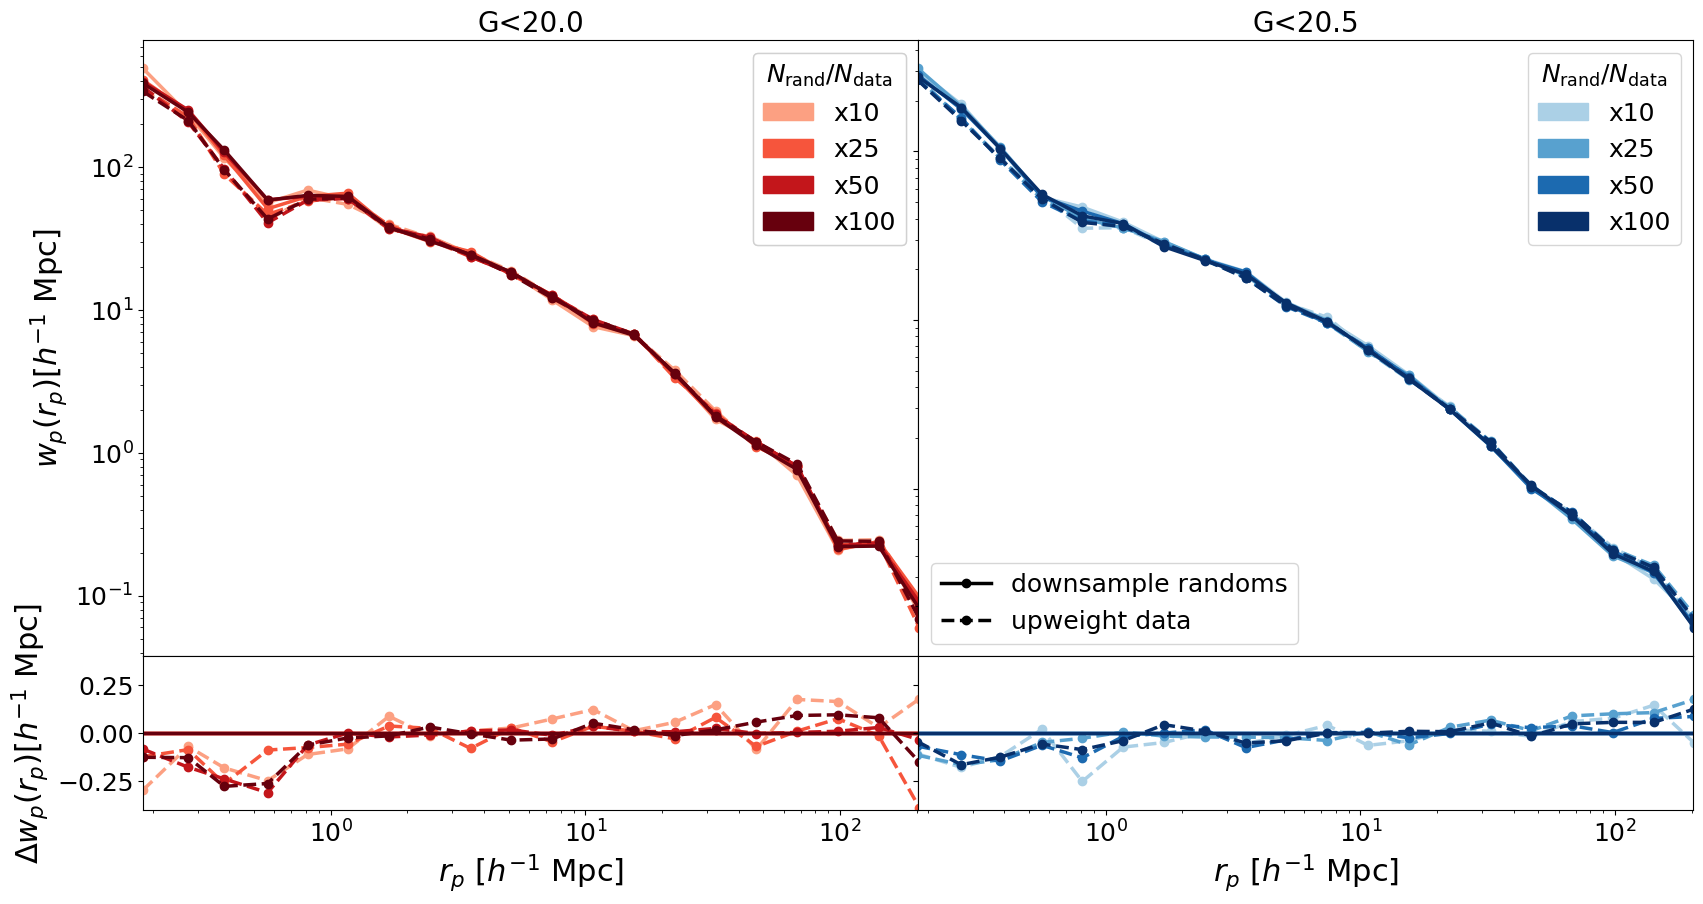

In [34]:
# # plot!
# fig = plt.figure(figsize = (20, 10))
# gs = gridspec.GridSpec(2, 2, wspace = 0, height_ratios = [4,1], hspace = 0)
    
# for i in range(len(colors)):

#     ax1 = fig.add_subplot(gs[i])
#     ax2 = fig.add_subplot(gs[i+2])
    
#     for j in range(len(facrand)):

#         rpavg = np.load('../results/rpavg_G{}_{}x.npy'.format(G_array[i], facrand[j]))
#         wp = np.load('../results/wp_G{}_{}x.npy'.format(G_array[i], facrand[j]))
#         ax1.plot(rpavg, wp, marker = 'o', label = 'downsample randoms', 
#                      linewidth = 2.5, color = cmaps[i][j])

#         # upweighted method
#         rpavg_allsky = np.load('../results/rpavg_G{}_allsky_{}x.npy'.format(G_array[i], facrand[j]))
#         wp_allsky = np.load('../results/wp_G{}_allsky_{}x.npy'.format(G_array[i], facrand[j]))
#         ax1.plot(rpavg_allsky, wp_allsky, marker = 'o', label = 'upweight data', 
#                      linewidth = 2.5, color = cmaps[i][j], linestyle = '--')

#         ax1.set_title('G<{}'.format(G_array[i]))
#         ax1.set_xticklabels([])
#         ax1.set_yscale('log')
#         ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
#         ax1.set_ylim(8e-4, 3e1)

#         ax2.axhline(0, linewidth = 2.5,color = cmaps[i][j])
#         ax2.plot(rpavg_allsky, (wp_allsky-wp)/wp, marker = 'o', 
#                  label = 'x{}'.format(facrand[j]), linewidth = 2.5, color = cmaps[i][j], linestyle = '--')
#         ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
#         ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
#         ax2.set_ylim(-0.4, 0.4)

#         if scale == 'log':
#             ax1.set_xscale('log')
#             ax2.set_xscale('log')

#         if i == 0:
#             ax1.set_ylabel(r"$w_p(r_p)[h^{-1}$ Mpc]")
#             ax2.set_ylabel(r"$\Delta w_p(r_p)[h^{-1}$ Mpc]")
#         else:
#             ax1.set_yticklabels([])
#             ax2.set_yticklabels([])
            
#     patch = [mpatches.Patch(color=cmaps[i][k], label='x{}'.format(facrand[k])) for k in range(len(cmaps[i]))]
#     first_legend = ax1.legend(handles=patch, loc = 'upper right', title = "$N_\mathrm{rand}/N_\mathrm{data}$", title_fontsize = 18)
#     ax1.add_artist(first_legend)

# custom_lines = [Line2D([0], [0], color = 'black', linewidth = 2.5, linestyle = '-', marker = 'o'), 
#                 Line2D([0], [0], color = 'black', linewidth = 2.5, linestyle = '--', marker = 'o')]
# ax1.legend(custom_lines, ['downsample randoms', 'upweight data'], loc = 'lower left')

# plt.show()

# plot!
fig = plt.figure(figsize = (20, 10))
gs = gridspec.GridSpec(2, 2, wspace = 0, height_ratios = [4,1], hspace = 0)
    
for i in range(len(colors)):

    ax1 = fig.add_subplot(gs[i])
    ax2 = fig.add_subplot(gs[i+2])
    
    for j in range(len(facrand)):

        ax1.plot(rpavg_test[G_array[i]][j], wp_test[G_array[i]][j], marker = 'o', label = 'downsample randoms', 
                     linewidth = 2.5, color = cmaps[i][j])

        # upweighted method
        ax1.plot(rpavg_test_allsky[G_array[i]][j], wp_test_allsky[G_array[i]][j], marker = 'o', label = 'upweight data', 
                     linewidth = 2.5, color = cmaps[i][j], linestyle = '--')

        ax1.set_title('G<{}'.format(G_array[i]))
        ax1.set_xticklabels([])
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        # ax1.set_ylim(8e-4, 3e1)

        ax2.axhline(0, linewidth = 2.5,color = cmaps[i][j])
        ax2.plot(rpavg_test_allsky[G_array[i]][j], (wp_test_allsky[G_array[i]][j]-wp_test[G_array[i]][j])/wp_test[G_array[i]][j], marker = 'o', 
                 label = 'x{}'.format(facrand[j]), linewidth = 2.5, color = cmaps[i][j], linestyle = '--')
        ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax2.set_ylim(-0.4, 0.4)

        if scale == 'log':
            ax1.set_xscale('log')
            ax2.set_xscale('log')

        if i == 0:
            ax1.set_ylabel(r"$w_p(r_p)[h^{-1}$ Mpc]")
            ax2.set_ylabel(r"$\Delta w_p(r_p)[h^{-1}$ Mpc]")
        else:
            ax1.set_yticklabels([])
            ax2.set_yticklabels([])
            
    patch = [mpatches.Patch(color=cmaps[i][k], label='x{}'.format(facrand[k])) for k in range(len(cmaps[i]))]
    first_legend = ax1.legend(handles=patch, loc = 'upper right', title = "$N_\mathrm{rand}/N_\mathrm{data}$", title_fontsize = 18)
    ax1.add_artist(first_legend)

custom_lines = [Line2D([0], [0], color = 'black', linewidth = 2.5, linestyle = '-', marker = 'o'), 
                Line2D([0], [0], color = 'black', linewidth = 2.5, linestyle = '--', marker = 'o')]
ax1.legend(custom_lines, ['downsample randoms', 'upweight data'], loc = 'lower left')

plt.show()

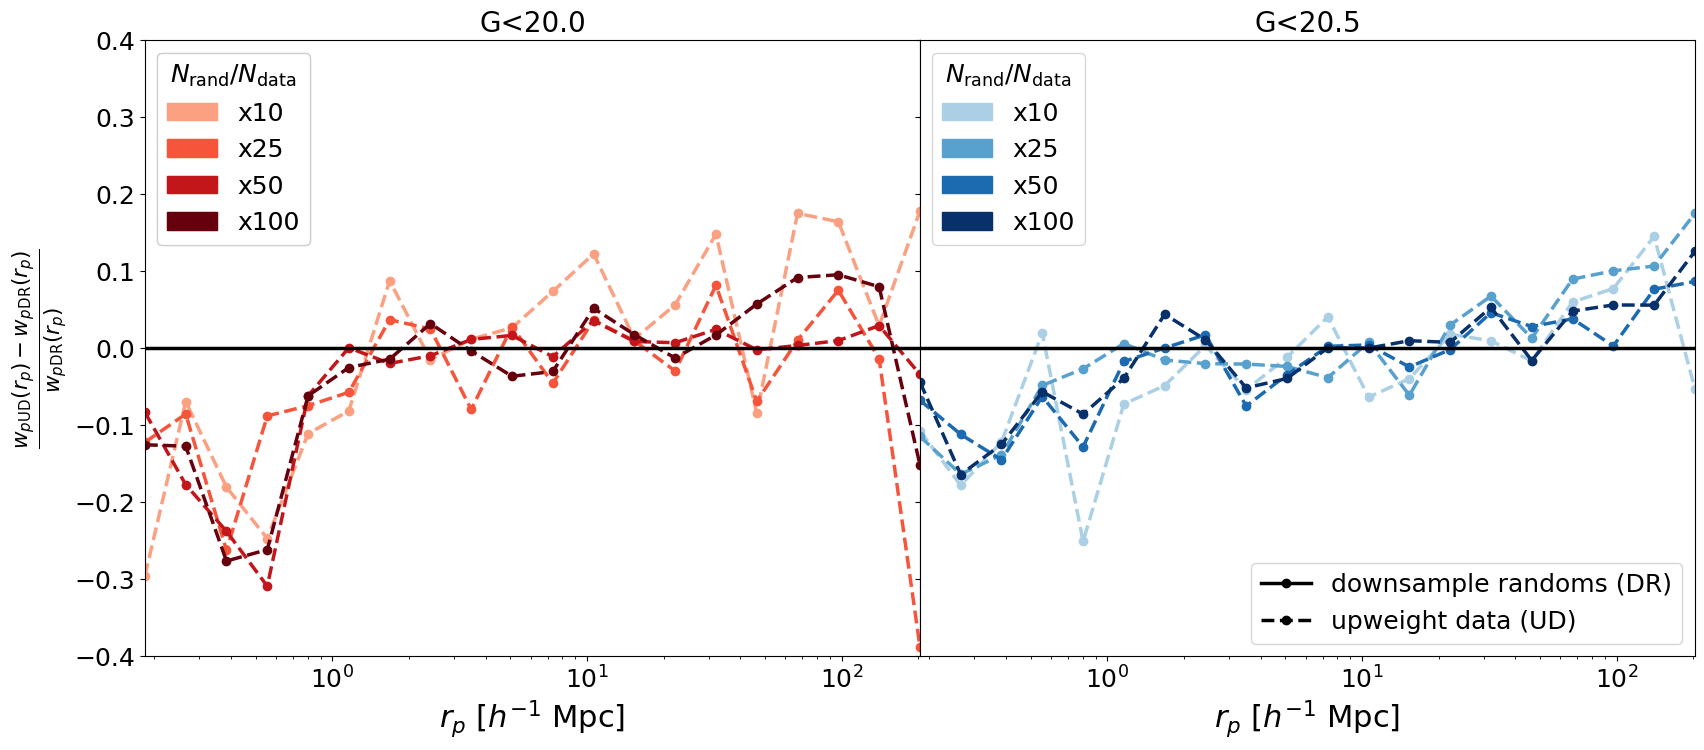

In [35]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

for i in range(len(colors)):

    ax1 = fig.add_subplot(gs[i])
    
    for j in range(len(facrand)):

        ax1.plot(quaia.recenter(rbins), (wp_test_allsky[G_array[i]][j]-wp_test[G_array[i]][j])/wp_test[G_array[i]][j], marker = 'o', 
                 label = 'x{}'.format(facrand[j]), linewidth = 2.5, color = cmaps[i][j], linestyle = '--')
    
    ax1.set_title('G<{}'.format(G_array[i]))    
    ax1.axhline(0, linewidth = 2.5,color = 'black')
    ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(-0.4, 0.4)

    if scale == 'log':
        ax1.set_xscale('log')

    if i == 0:
        ax1.set_ylabel(r"$\frac{{w_p}_\mathrm{UD}(r_p)-{w_p}_\mathrm{DR}(r_p)}{{w_p}_\mathrm{DR}(r_p)}$")
    else:
        ax1.set_yticklabels([])

    patch = [mpatches.Patch(color=cmaps[i][k], label='x{}'.format(facrand[k])) for k in range(len(cmaps[i]))]
    first_legend = ax1.legend(handles=patch, loc = 'upper left', title = "$N_\mathrm{rand}/N_\mathrm{data}$", title_fontsize = 18)
    ax1.add_artist(first_legend)
    
custom_lines = [Line2D([0], [0], color = 'black', linewidth = 2.5, linestyle = '-', marker = 'o'), 
                Line2D([0], [0], color = 'black', linewidth = 2.5, linestyle = '--', marker = 'o')]
ax1.legend(custom_lines, ['downsample randoms (DR)', 'upweight data (UD)'], loc = 'lower right')

plt.show()

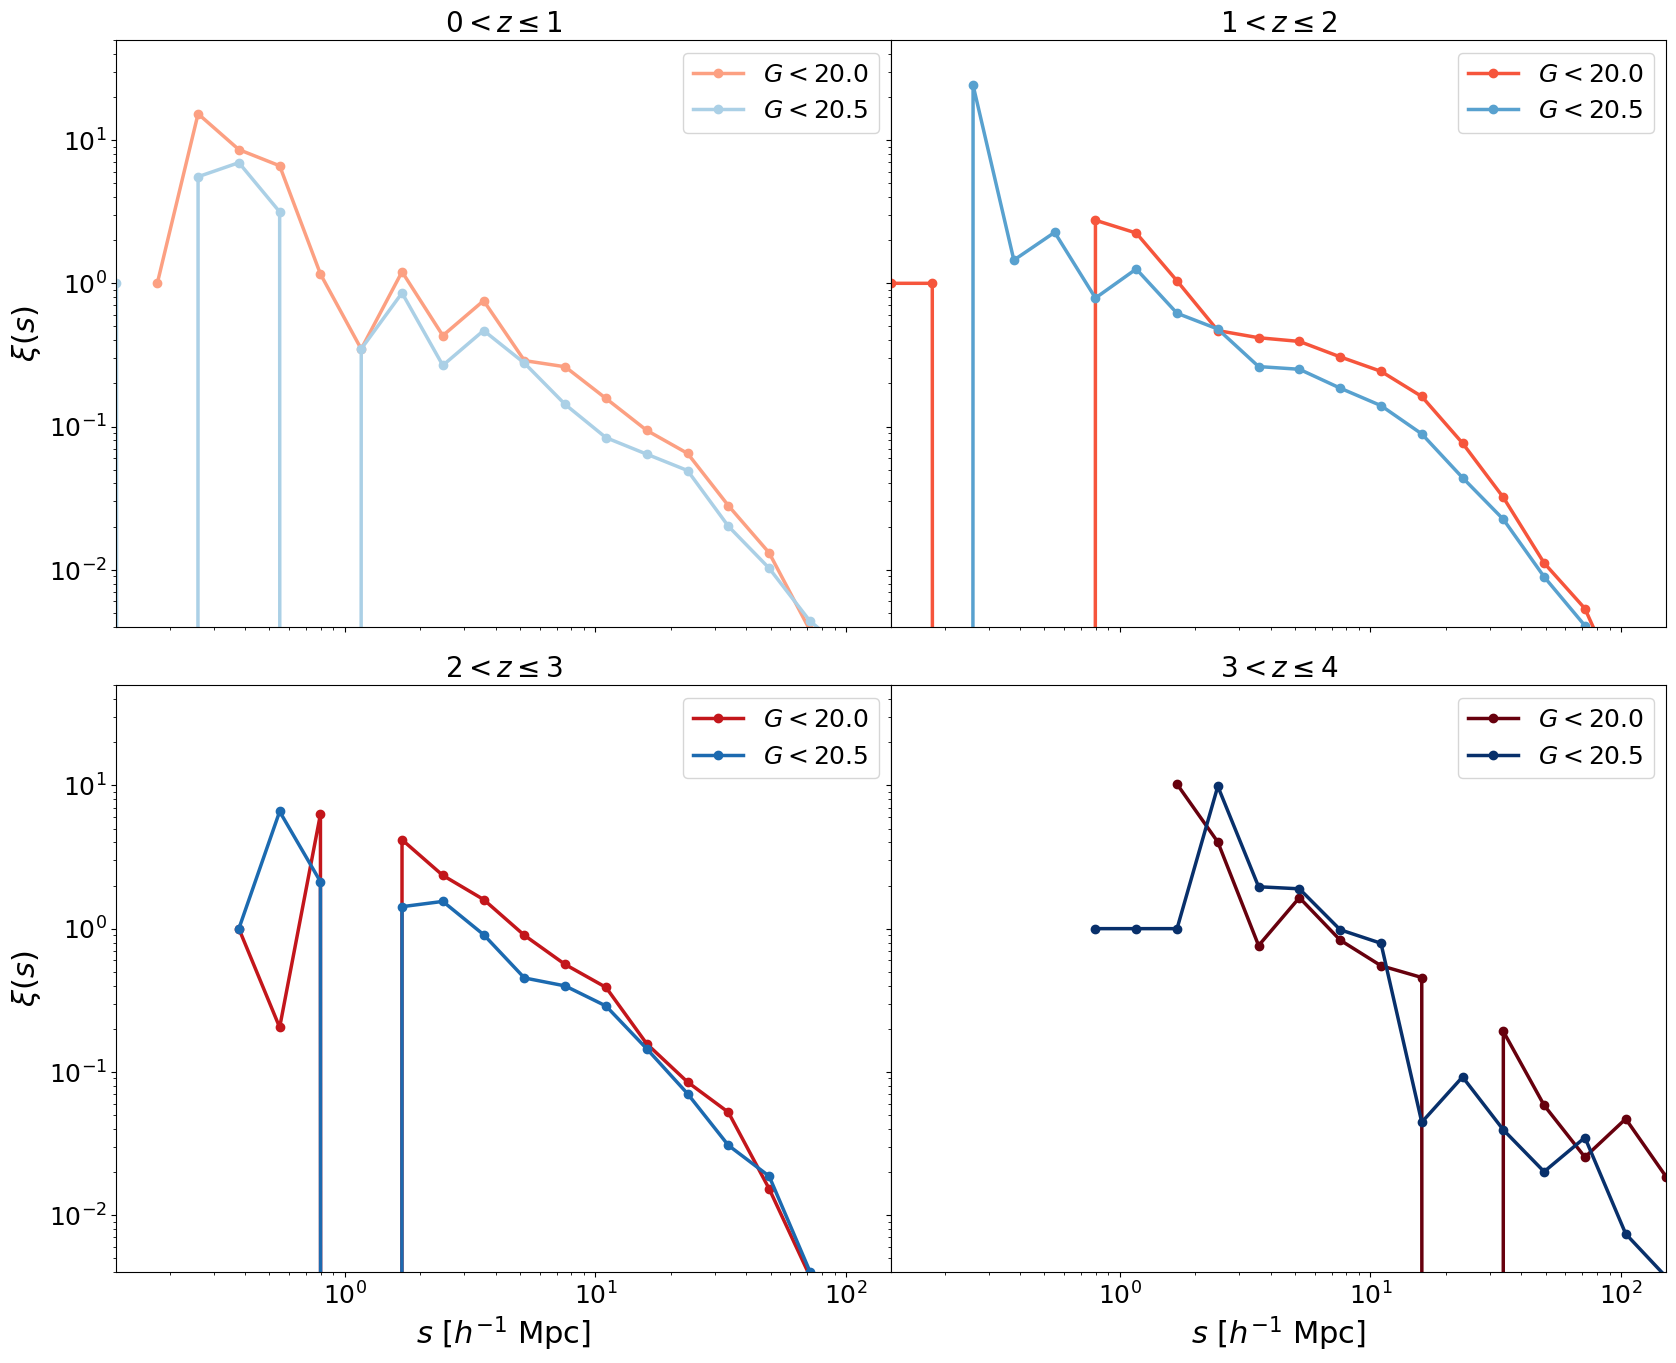

In [52]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)

for zbin in zbin_array:
    ax1 = fig.add_subplot(gs[zbin])
    for G in [20.0, 20.5]:
        ax1.plot(quaia.recenter(rbins), cf[G][zbin], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', color = cmaps[G][zbin])
        ax1.set_title('${}<z \leq{}$'.format(zbin, zbin+1))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(4e-3, 5e1)
        if zbin>1:
            ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        else:
            ax1.set_xticklabels([])
        if zbin%2==0:
            ax1.set_ylabel(r"$\xi(s)$")
        else:
            ax1.set_yticklabels([])
        # if zbin==0:
        ax1.legend()

plt.show()

## $w_p(r_p)$

In [53]:
# Create the bins array
rmin = 0.15 # 0.5 # 0.1 # start higher
rmax = 240 # 120 #85 # 60.0 # 20.0 
nbins = 20 
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

# rmin = 0.15 # 0.5 # 0.1 # start higher
# rmax = 210 # 120 #85 # 60.0 # 20.0 
# nbins = 20 
# rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'lin'

In [54]:
pimax = 80 # 40 # 5000.0 # 40.0

In [64]:
# plot data
bins = np.linspace(0.08, 4.6)
wp, rpavg = {20.0: [], 20.5: []}, {20.0: [], 20.5: []}
for G in [20.0, 20.5]:

    for zbin in zbin_array:
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, N_datahi_mask_zbin0, N_randhi_mask_zbin0, key_zbin0 = zbins(G, None, 
                                                                                                                  zbin)
        wp_datahi_zbin0, rpavg_datahi_zbin0 = quaia.wp_rp(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, N_datahi_mask_zbin0, 
                                                           N_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, rbins = rbins, 
                                                           nbins = nbins, pimax = pimax)
        wp[G].append(wp_datahi_zbin0)
        rpavg[G].append(rpavg_datahi_zbin0)

/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endia

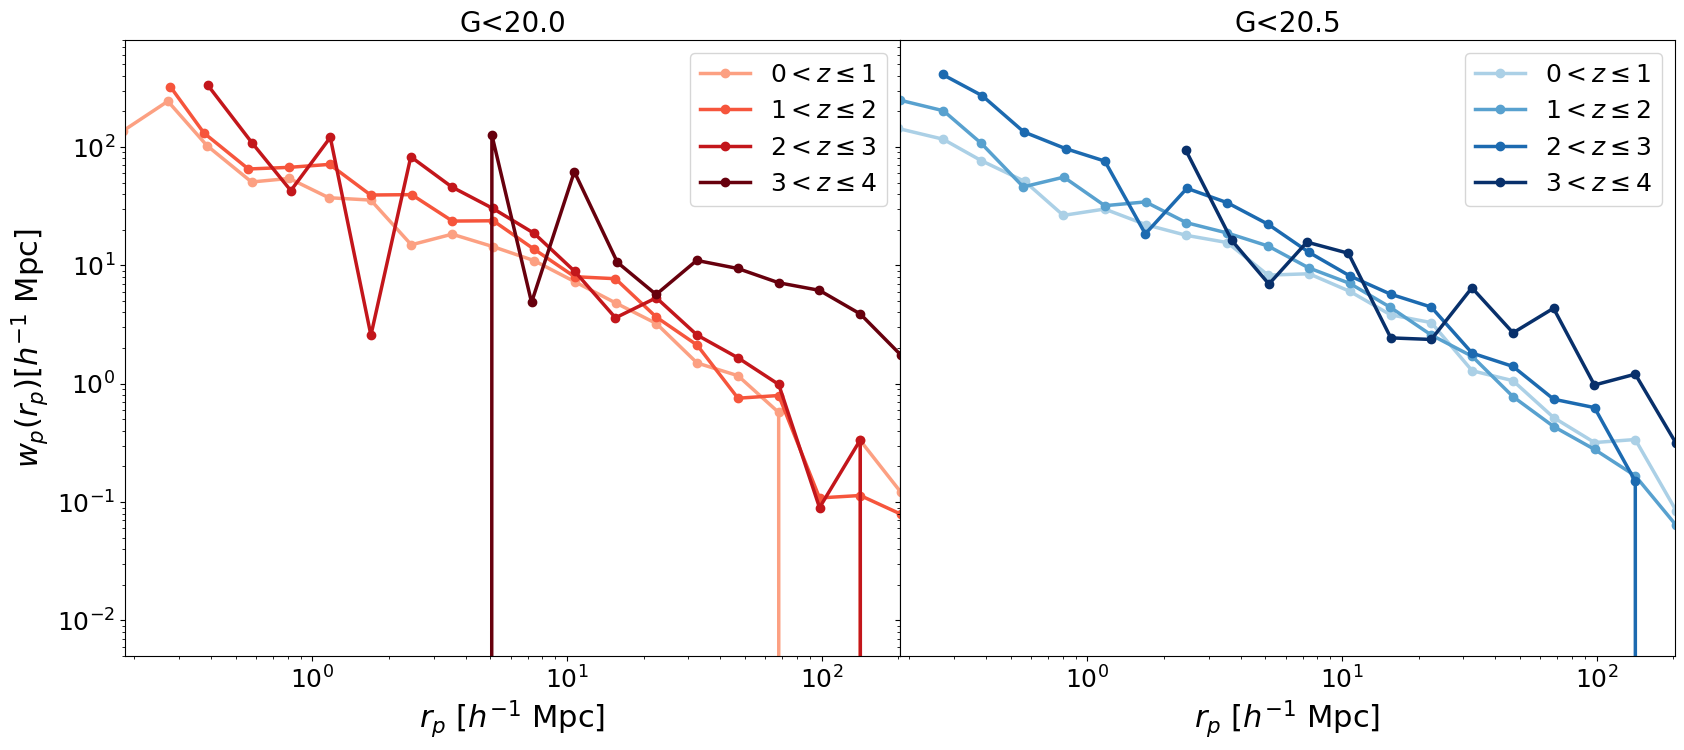

In [80]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

# G_array = [20.0, 20.5]
for i in range(len(G_array)):
# i = 0
    ax1 = fig.add_subplot(gs[i])
    for zbin in zbin_array:
        ax1.plot(rpavg[G_array[i]][zbin], wp[G_array[i]][zbin], label = '${}<z \leq{}$'.format(zbin, zbin+1), 
                 linewidth = 2.5, marker = 'o', color = cmaps[G_array[i]][zbin])
        ax1.set_title('G<{}'.format(G_array[i]))
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(5e-3, 8e2)
        ax1.legend()
        if i==0:
            ax1.set_ylabel(r"$w_p(r_p)[h^{-1}$ Mpc]")
        else:
            ax1.set_yticklabels([])

plt.show()

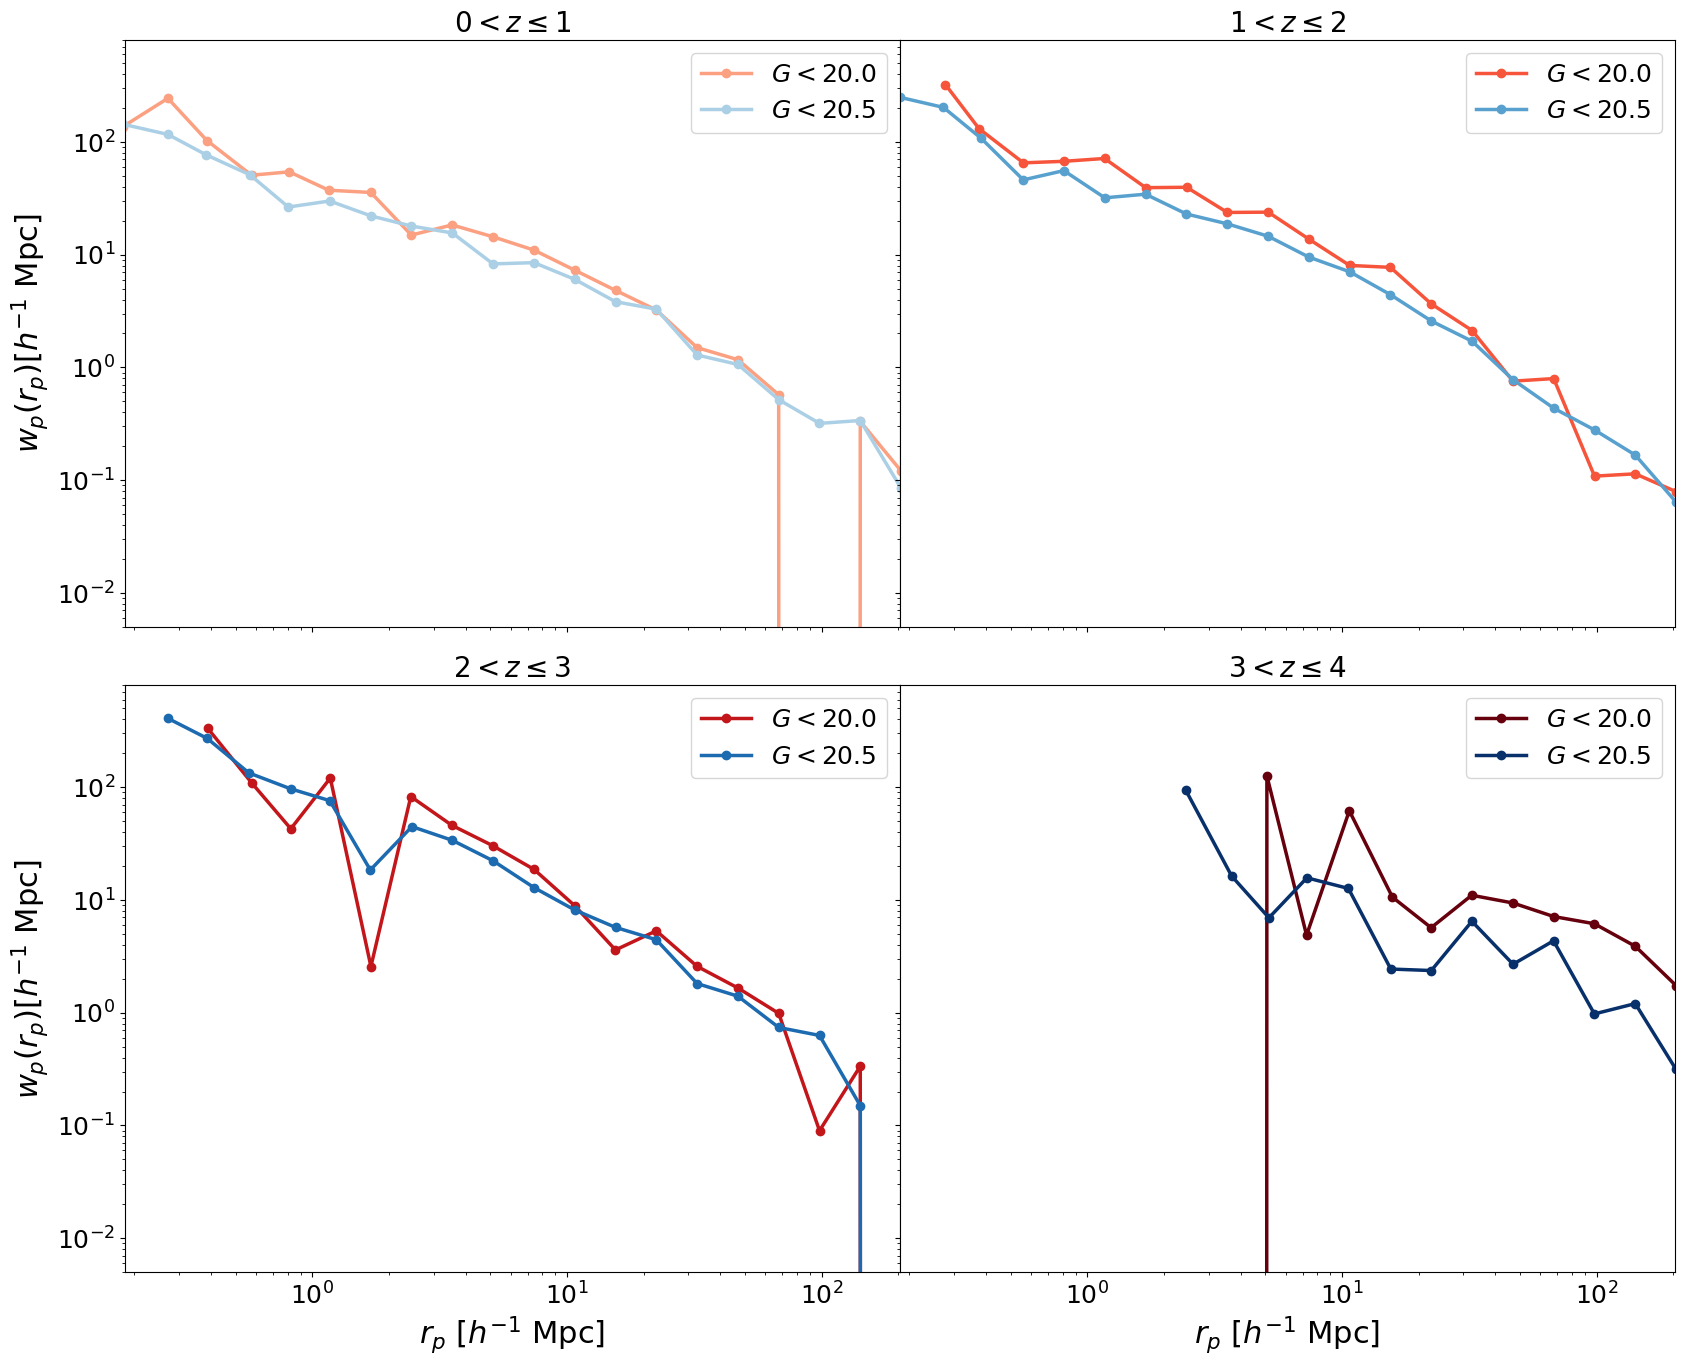

In [81]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)

for zbin in zbin_array:
    ax1 = fig.add_subplot(gs[zbin])
    for G in [20.0, 20.5]:
        ax1.plot(rpavg[G][zbin], wp[G][zbin], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', color = cmaps[G][zbin])
        ax1.set_title('${}<z \leq{}$'.format(zbin, zbin+1))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(5e-3, 8e2)
        ax1.legend()
        if zbin>1:
            ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        else:
            ax1.set_xticklabels([])
        if zbin%2==0:
            ax1.set_ylabel(r"$w_p(r_p)[h^{-1}$ Mpc]")
        else:
            ax1.set_yticklabels([])

plt.show()

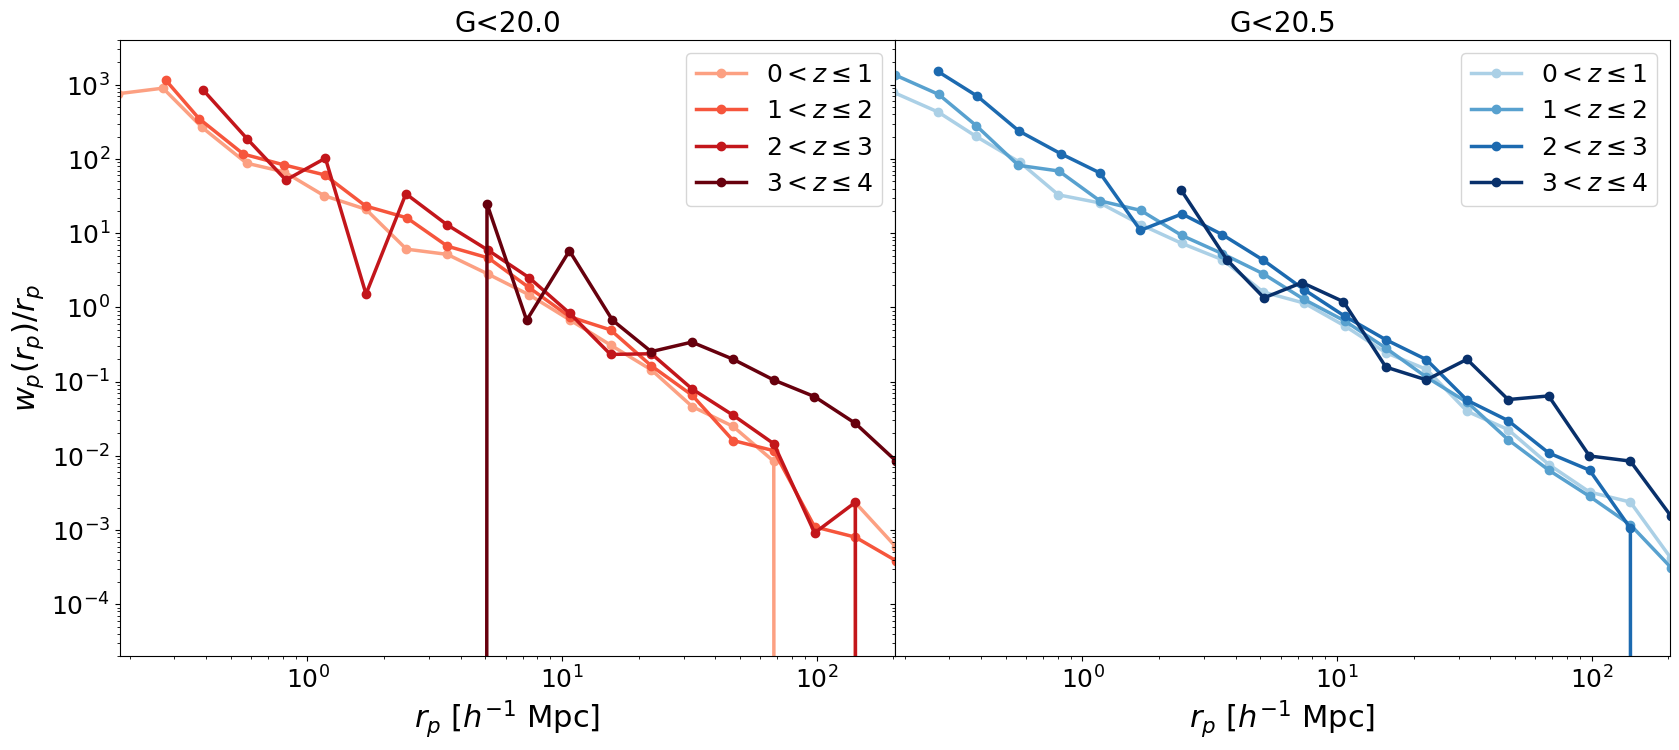

In [82]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

G_array = [20.0, 20.5]
for i in range(len(G_array)):
# i = 0
    ax1 = fig.add_subplot(gs[i])
    for zbin in zbin_array:
        ax1.plot(rpavg[G_array[i]][zbin], wp[G_array[i]][zbin]/rpavg[G_array[i]][zbin], label = '${}<z \leq{}$'.format(zbin, zbin+1), 
                 linewidth = 2.5, marker = 'o', color = cmaps[G_array[i]][zbin])
        ax1.set_title('G<{}'.format(G_array[i]))
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(2e-5, 4e3)
        ax1.legend()
        if i==0:
            ax1.set_ylabel(r"$w_p(r_p)/r_p$")
        else:
            ax1.set_yticklabels([])

plt.show()

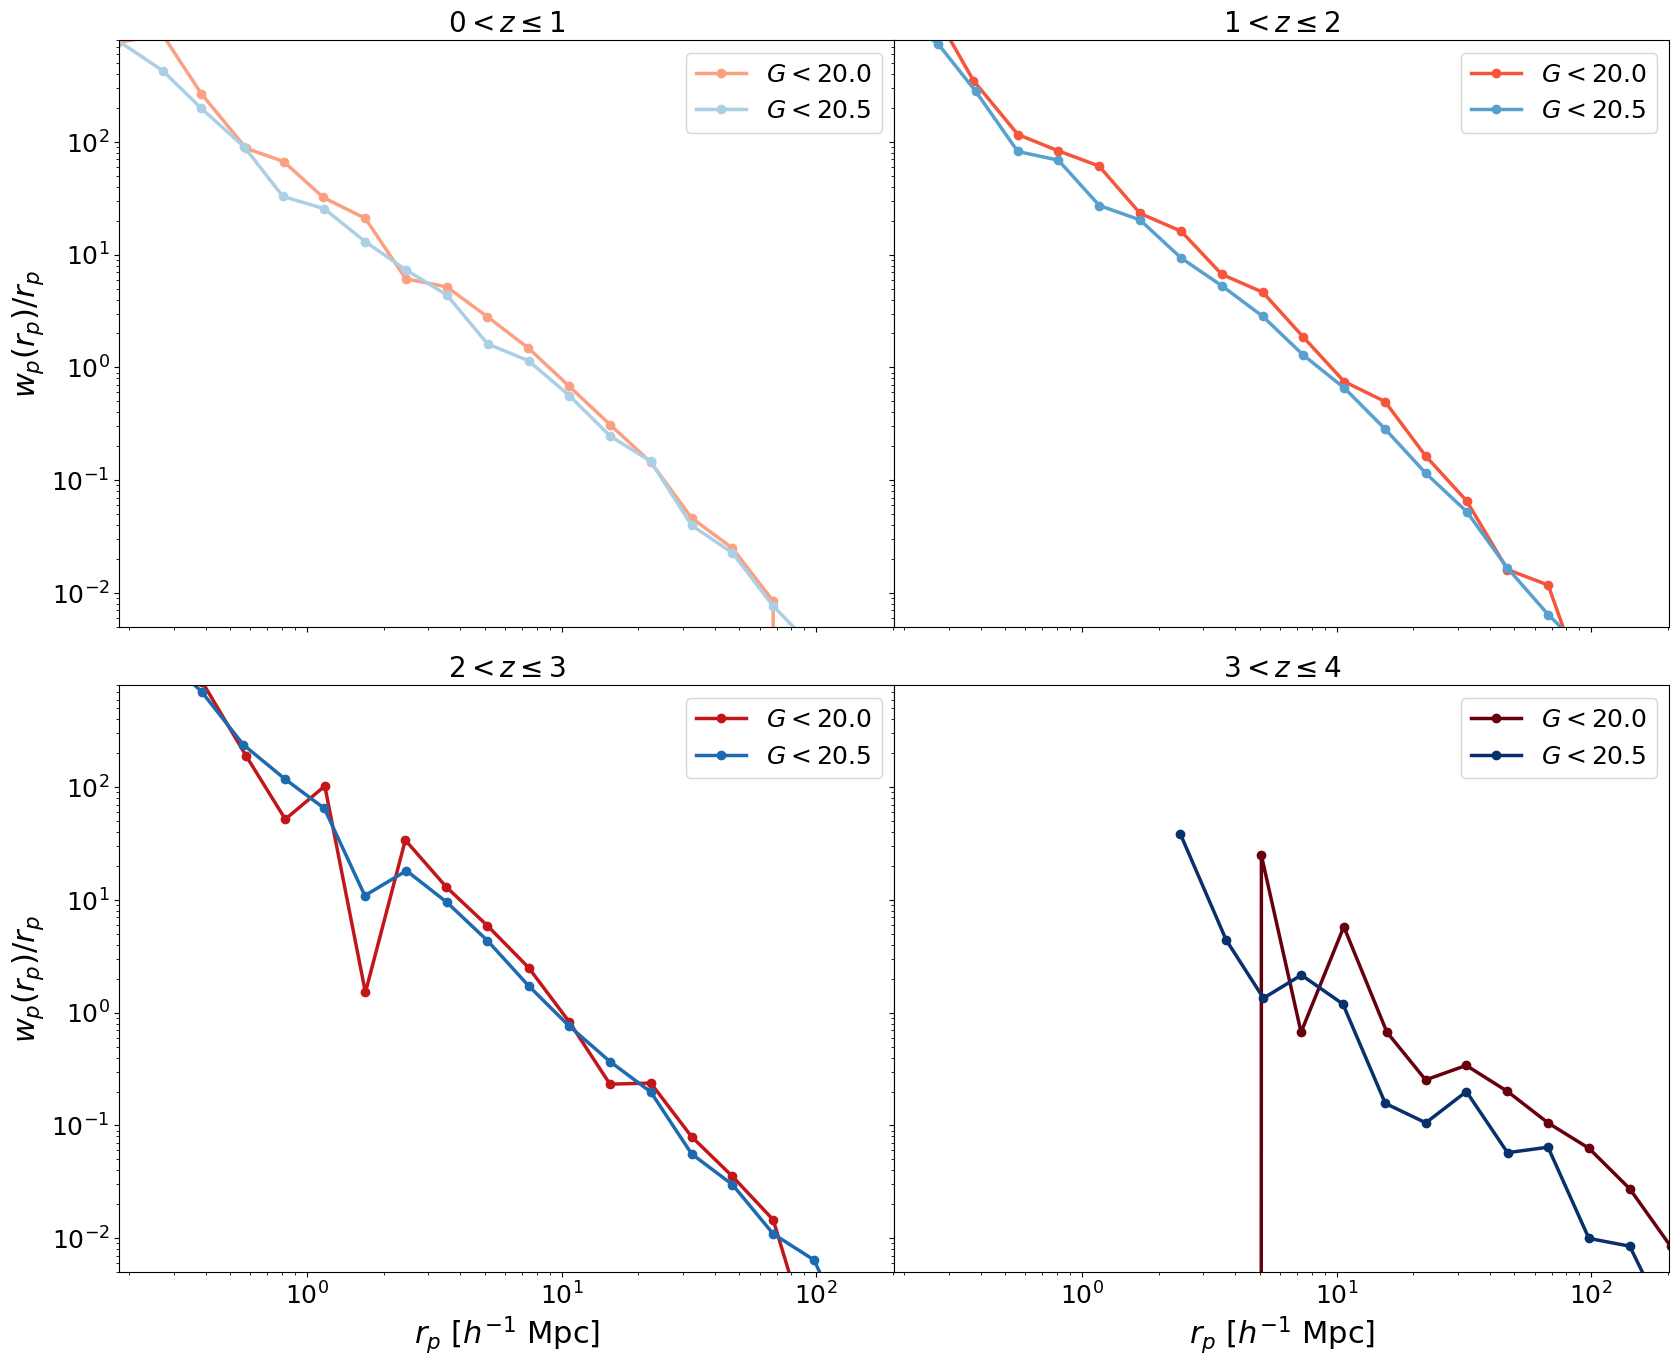

In [91]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)

for zbin in zbin_array:
    ax1 = fig.add_subplot(gs[zbin])
    for G in [20.0, 20.5]:
        ax1.plot(rpavg[G][zbin], wp[G][zbin]/rpavg[G][zbin], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', color = cmaps[G][zbin])
        ax1.set_title('${}<z \leq{}$'.format(zbin, zbin+1))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(5e-3, 8e2)
        ax1.legend()
        if zbin>1:
            ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        else:
            ax1.set_xticklabels([])
        if zbin%2==0:
            ax1.set_ylabel(r"$w_p(r_p)/r_p$")
        else:
            ax1.set_yticklabels([])

plt.show()

## $w(\theta)$

In [83]:
# Create the bins array
# thetabins = np.logspace(np.log10(0.1), np.log10(10), 15) 
thetabins = np.logspace(np.log10(0.1), np.log10(35), 15) #(np.log10(0.15), np.log10(35), 15)

In [84]:
# plot data
wtheta = {20.0: [], 20.5: []}
for G in [20.0, 20.5]:

    for zbin in zbin_array:
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, N_datahi_mask_zbin0, N_randhi_mask_zbin0, key_zbin0 = zbins(G, None, 
                                                                                                                  zbin)

        wtheta_datahi_zbin0 = quaia.w_theta(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, N_datahi_mask_zbin0, 
                                                           N_randhi_mask_zbin0, nthreads = nthreads, thetabins = thetabins)
        wtheta[G].append(wtheta_datahi_zbin0)

/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endia

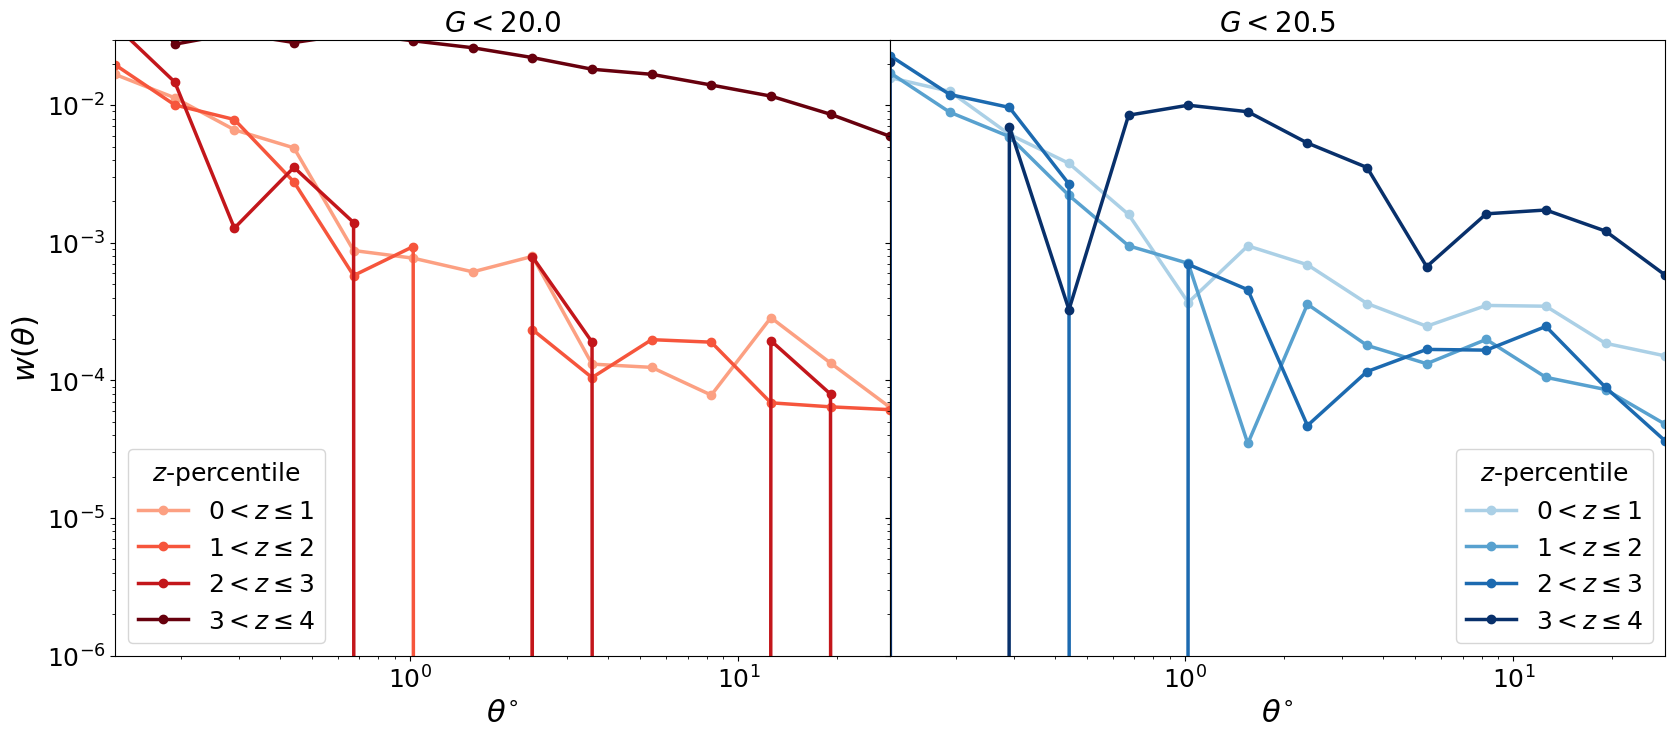

In [85]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

# G_array = [20.0, 20.5]
for i in range(len(G_array)):
    ax1 = fig.add_subplot(gs[i])
    for zbin in zbin_array:
        ax1.plot(quaia.recenter(thetabins), wtheta[G_array[i]][zbin], label = '${}<z \leq{}$'.format(zbin, zbin+1), 
                 linewidth = 2.5, marker = 'o', color = cmaps[G_array[i]][zbin])
        ax1.set_title('$G<{}$'.format(G_array[i]))
        ax1.set_xlabel(r'$\theta^{\circ}$')
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(thetabins)[0], quaia.recenter(thetabins)[-1])
        ax1.set_ylim(1e-6, 3e-2)
        ax1.legend(title='$z$-percentile', title_fontsize = 18)
        if i==0:
            ax1.set_ylabel(r"$w(\theta)$")
        else:
            ax1.set_yticklabels([])

plt.show()

In [1]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)

for zbin in zbin_array:
    
    ax1 = fig.add_subplot(gs[zbin])
    
    for G in G_array:

        ax1.plot(quaia.recenter(thetabins), wtheta[G][zbin], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', 
                 color = cmaps[G][zbin])
        
    ax1.set_title('${}<z \leq{}$'.format(zbin, zbin+1))
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(thetabins)[0], quaia.recenter(thetabins)[-1])
    ax1.set_ylim(1e-6, 3e-2)
    ax1.legend()
    if zbin%2==0:
        ax1.set_ylabel(r"$w(\theta)$")
    else:
        ax1.set_yticklabels([])
    if zbin<2:
        ax1.set_xticklabels([])
    else:
        ax1.set_xlabel(r'$\theta^{\circ}$')

plt.show()

NameError: name 'plt' is not defined